In [1]:
import numpy as np
#from dfba import DfbaModel, ExchangeFlux, KineticVariable
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from numba import njit
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
import sys
import os
import openpyxl
import gurobipy

import pymc as pm
import pytensor
import pytensor.tensor as pt
from pymc.ode import DifferentialEquation
from pytensor.compile.ops import as_op
import arviz as az

import time
import joblib
import multiprocessing
from scipy.stats import truncnorm
import copy
from pathlib import Path
import subprocess

### script for running glv_dfba inference
from helper_functions import *
import argparse
import re

from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages
import json
import logging
from scipy.stats import pearsonr, spearmanr

from Bio import Entrez

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
gurobipy

<module 'gurobipy' from '/Users/haydengallo/anaconda3/envs/cobra_agorra/lib/python3.12/site-packages/gurobipy/__init__.py'>

In [4]:
#################################################################################################################################################################
### this is used to surpress all logging from loading in the kbase models with cobra, such that they don't get added to the glv_fba log file and overcrowd it ### 
logging.getLogger("cobra").setLevel(logging.ERROR)
#################################################################################################################################################################

In [5]:
### subject with abundance data
subject_to_plot = 1999#1507#1953#1999
### subject to predict, subject with metabolomics data
subject_to_predict = 2000#1510#1948#2000
### Set test num
test_num = 115
### set time scaler
time_scaler = 24#96#192#24
### Total time steps
total_time_steps = 417
###
notes = 'back to if statement for negativity and 1e10 scale factor'

In [6]:
## ok now need to reconstruct the time series basically 

### need to load in all of the processed_data 
# Make the data and validation Study objects

processed_data = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun')

tsv_files = sorted(processed_data.glob('*.tsv'))
tsv_files = {f.stem : f for f in tsv_files}



In [7]:
counts = pd.read_csv(tsv_files['counts'], delimiter='\t', index_col=0)
metadata = pd.read_csv(tsv_files['metadata'], delimiter='\t', index_col=0)
perturbations = pd.read_csv(tsv_files['perturbations'], delimiter='\t', index_col=0)
qpcr = pd.read_csv(tsv_files['qpcr'], delimiter='\t', index_col=0)
taxonomy = pd.read_csv(tsv_files['taxonomy'], delimiter='\t', index_col=0)

In [8]:
### Load up the initial data for subject 1948 with RC diet 

#init_mets_input_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/sub_' + str(subject_to_predict) + '_init_met.csv'
init_mets_input_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/sub_' + str(subject_to_predict) + '_met_df.tsv'

sub_1948_init_mets = pd.read_csv(init_mets_input_path,sep='\t')
sub_1948_init_mets.head()

,metabolite,fluxValue
0,EX_12kltchca(e),0.263
1,EX_drib(e),0.285
2,EX_5oxpro(e),0.305
3,EX_ala_l(e),11.053
4,EX_all_d(e),0.069


In [9]:
### Ok need to take the sub_1948_init_mets and prepare for input to static_dfba

sub_1948_init_mets.columns = ['reaction','fluxValue']

## change fluxValue to positive and then only keep reaction and fluxvalue columns 

sub_1948_init_mets = sub_1948_init_mets[['reaction', 'fluxValue']]

sub_1948_init_mets['fluxValue'] =  (np.double(sub_1948_init_mets['fluxValue']))
#sub_1948_init_mets.iloc[0,0] = 'EX_12kltchca(e)'

### Also need to change out EX_ocdca(e) and EX_erythritol(e)

### old 

#sub_1948_init_mets['reaction'].loc['EX_cis_Oleic acid(e)']


sub_1948_init_mets['fluxValue'] = sub_1948_init_mets['fluxValue']
sub_1948_init_mets.head()

,reaction,fluxValue
0,EX_12kltchca(e),0.263
1,EX_drib(e),0.285
2,EX_5oxpro(e),0.305
3,EX_ala_l(e),11.053
4,EX_all_d(e),0.069


In [10]:
sub_1948_init_mets['fluxValue'].clip(upper=5)

0     0.263
1     0.285
2     0.305
3     5.000
4     0.069
5     5.000
6     0.000
7     0.243
8     0.520
9     0.895
10    0.099
11    3.358
12    0.179
13    5.000
14    0.168
15    0.000
16    0.905
17    0.377
18    0.555
19    5.000
20    5.000
21    0.159
22    0.512
23    0.290
24    0.000
25    0.844
26    2.736
27    5.000
28    5.000
29    0.501
30    0.000
31    0.389
32    0.000
33    0.442
34    1.623
35    1.167
36    3.379
37    0.753
38    0.020
39    1.576
40    0.836
41    0.415
42    5.000
43    1.089
44    0.000
45    0.926
46    5.000
47    0.840
48    5.000
49    0.660
50    0.423
51    5.000
52    0.064
53    1.350
54    1.086
55    0.056
56    5.000
57    0.139
58    1.919
59    1.908
Name: fluxValue, dtype: float64

In [11]:
### Load in diet data that will be applied in intervals 

RC_diet = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/RC_mm_add.csv', header=None)
RC_diet.columns = ['reaction','fluxValue','upper_bound']
RC_diet = RC_diet[['reaction', 'fluxValue']]
RC_diet['fluxValue'] =  -1.0*(np.double(RC_diet['fluxValue']))

## Multiply by 5g over 12 hours
RC_diet['fluxValue'] = ((5/time_scaler)*RC_diet['fluxValue'])
RC_diet.head()

,reaction,fluxValue
0,EX_5oxpro(e),0.027292
1,EX_ala_l(e),0.174167
2,EX_all_d(e),0.006042
3,EX_arab_l(e),0.011458
4,EX_asp_l(e),0.082917


In [12]:
### Load in metabolomics data 

metabolomics_data = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/complete_mapping_metabolomics.csv', index_col=0)
## fill NAs w/ zero 
metabolomics_data = metabolomics_data.fillna(0)
metabolomics_data.head()

,SampleName,12_Ketolithocholic acid,drib,5oxpro,ala__L,all__D,arab__L,asn__L,asp__L,cellb,...,thr__L,tyr__L,HC02194,pta,val__L,akg,cis_Oleic acid,meso_Erythritol,inost,4hpro_LT
0,HF1114,0.135,0.272,0.199,6.991,0.049,12.191,0.0,0.178,0.000,...,0.248,0.791,0.000,3.766,0.493,0.043,7.512,0.084,2.029,0.581
1,HF1115,0.263,0.285,0.305,11.053,0.069,15.784,0.0,0.243,0.520,...,0.423,6.104,0.064,1.350,1.086,0.056,8.391,0.139,1.919,1.908
2,HF1119,0.212,0.059,0.132,2.192,0.042,0.139,0.0,0.073,0.409,...,0.132,0.587,0.037,0.110,0.454,0.000,8.760,0.038,0.195,0.020
3,HF1120,0.528,0.067,0.122,1.459,0.030,0.175,0.0,0.062,0.000,...,0.105,0.520,0.307,0.400,0.431,0.023,14.081,0.049,0.099,0.027
4,HF1124,0.147,0.381,0.637,15.682,0.035,9.139,0.0,0.258,0.000,...,0.529,0.912,0.013,6.306,0.881,0.471,1.399,0.088,0.637,0.332


In [13]:
### load in metabolomics metadata

metabolomics_metadata_raw = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/metabolomics_meta.csv', index_col=0)
# filtered metabolomics metadata for subject 1948 initial sample 
metabolomics_metadata = metabolomics_metadata_raw.copy()
metabolomics_metadata = metabolomics_metadata[(metabolomics_metadata['Mouse'] == float(subject_to_predict)) & (metabolomics_metadata['Rec_day_adj'] == -3)]
metabolomics_metadata.index.tolist()

['HF1115']

In [14]:
### load in sample metadata 

sample_metadata = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/metadata.tsv', sep='\t',index_col=0)
sample_metadata.head()


,treat,subject,time
sampleID,,,
HF25,RC-ABX,5735,0.0
HF26,RC-ABX,5570,0.0
HF27,RC-ABX,5571,0.0
HF28,RC-ABX,5266,0.0
HF29,RC-ABX,5267,0.0


In [15]:
### load in refseq to agora dataframe


#refseq_to_agora_df = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/refseq_to_agora_df_all_cohorts.tsv', delimiter='\t', index_col=0)
#refseq_to_agora_df.head()

## utilizing updated refseq file

refseq_to_agora_df = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/refseq_to_agora_update_07_07_25.csv', index_col=0)
refseq_to_agora_df.head()



,Accession,Genus,Species,Strain,Agora_Name
ASV_string,,,,,
14ac4eaad5b4e2ff3c071832e0fd4229,GCF_000771225.1,Bificobacterium,Pseudolongum,none,Bifidobacterium_pseudolongum
18673193aa6bf30c6a1e71ac504e04df,GCF_015235105.1,Jeotgalicoccus,nanhaiensis,none,Jeotgalicoccus_nanhaiensis
320dfd16200daaf2b0503975d4e68fd5,GCF_000236455.2,Lactobacillus,reuteri,none,Lactobacillus_reuteri
36173253c63ad49abc12361a0b3304eb,GCF_900155395.1,Merdibacter,massiliensis,none,Merdibacter_massiliensis
391821255f31ef94686927f4fba6fbc3,GCF_005304985.1,Duncaniella,Sp. B8,none,Duncaniealla_sp


In [16]:
### since i am going with daily resolution need to load in that data for determining initial abundances and the rates of change 

# nevermind bihourly after i figured out the smoothing
MDSINE_filter_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/filtering_hourly_resolution/Subject_' + str(subject_to_plot) + '/mean_smoothed.tsv'
bi_hourly_resolution_latent_traj = pd.read_csv(MDSINE_filter_path, delimiter='\t', index_col=0)
bi_hourly_resolution_latent_traj

,-3.0,-2.9583333333333335,-2.916666666666667,-2.8750000000000004,-2.833333333333334,-2.7916666666666674,-2.750000000000001,-2.7083333333333344,-2.666666666666668,-2.6250000000000013,...,13.62499999999994,13.666666666666607,13.708333333333275,13.74999999999994,13.791666666666607,13.833333333333272,13.87499999999994,13.916666666666607,13.958333333333272,14.0
14ac4eaad5b4e2ff3c071832e0fd4229,2.533138e+08,2.780380e+08,3.016429e+08,3.235821e+08,3.433487e+08,3.604964e+08,3.746571e+08,3.855545e+08,3.930119e+08,3.969548e+08,...,1.070847e+09,1.095900e+09,1.122103e+09,1.149491e+09,1.178099e+09,1.207961e+09,1.239111e+09,1.271585e+09,1.305417e+09,1.340639e+09
18673193aa6bf30c6a1e71ac504e04df,1.095657e+03,9.259829e+02,7.868884e+02,6.723548e+02,5.776331e+02,4.989608e+02,4.333447e+02,3.783948e+02,3.321947e+02,2.932019e+02,...,2.747688e+02,2.695337e+02,2.640003e+02,2.581798e+02,2.520849e+02,2.457300e+02,2.391312e+02,2.323060e+02,2.252737e+02,2.180546e+02
320dfd16200daaf2b0503975d4e68fd5,1.490341e+09,1.339589e+09,1.202303e+09,1.077644e+09,9.647552e+08,8.627785e+08,7.708699e+08,6.882094e+08,6.140091e+08,5.475196e+08,...,3.107831e+09,3.234246e+09,3.366276e+09,3.504031e+09,3.647599e+09,3.797052e+09,3.952436e+09,4.113769e+09,4.281041e+09,4.454205e+09
36173253c63ad49abc12361a0b3304eb,5.264788e+08,5.686839e+08,6.083128e+08,6.445988e+08,6.768572e+08,7.045090e+08,7.270981e+08,7.443029e+08,7.559412e+08,7.619696e+08,...,3.887003e+09,4.508674e+09,5.268138e+09,6.201606e+09,7.356220e+09,8.793742e+09,1.059563e+10,1.287002e+10,1.576151e+10,1.946475e+10
391821255f31ef94686927f4fba6fbc3,7.162489e+07,1.026539e+08,1.437429e+08,1.967578e+08,2.634177e+08,3.451089e+08,4.426840e+08,5.562681e+08,6.850954e+08,8.274013e+08,...,6.784824e+09,7.042053e+09,7.314477e+09,7.602969e+09,7.908449e+09,8.231889e+09,8.574311e+09,8.936793e+09,9.320465e+09,9.726516e+09
3936cc515320e9f29d81ffeaa92718e8,8.623799e+06,1.146181e+07,1.495897e+07,1.917887e+07,2.416539e+07,2.993572e+07,3.647407e+07,4.372700e+07,5.160080e+07,5.996158e+07,...,3.002481e+08,2.953071e+08,2.901273e+08,2.847109e+08,2.790611e+08,2.731824e+08,2.670807e+08,2.607633e+08,2.542387e+08,2.475170e+08
3e741fc097143bb6782af5233cb7af98,4.009421e+07,6.197872e+07,9.340223e+07,1.373002e+08,1.969828e+08,2.759748e+08,3.777754e+08,5.055425e+08,6.617227e+08,8.476585e+08,...,7.358296e+09,7.659298e+09,7.966565e+09,8.279302e+09,8.596591e+09,8.917385e+09,9.240506e+09,9.564638e+09,9.888326e+09,1.020998e+10
4cc9a4b9aaa3ee9a5c14cc27551a6844,5.046081e+02,4.409463e+02,3.884674e+02,3.449471e+02,3.086544e+02,2.782332e+02,2.526141e+02,2.309490e+02,2.125607e+02,1.969057e+02,...,1.370871e+02,1.719474e+02,2.200121e+02,2.873134e+02,3.831171e+02,5.218957e+02,7.266487e+02,1.034589e+03,1.507058e+03,2.247132e+03
795b6ba45f502a00b24b212278991c63,1.447762e+09,1.447129e+09,1.435607e+09,1.413854e+09,1.382721e+09,1.343213e+09,1.296442e+09,1.243582e+09,1.185833e+09,1.124379e+09,...,7.669059e+07,6.644771e+07,5.722844e+07,4.898542e+07,4.166515e+07,3.520931e+07,2.955606e+07,2.464139e+07,2.040036e+07,1.676824e+07
7ca7ca8214441730c2437d1f53390cdb,1.325859e+10,1.256498e+10,1.186548e+10,1.116715e+10,1.047628e+10,9.798349e+09,9.138001e+09,8.499096e+09,7.884734e+09,7.297305e+09,...,1.238719e+10,1.160929e+10,1.083475e+10,1.006835e+10,9.314658e+09,8.578053e+09,7.862604e+09,7.172024e+09,6.509625e+09,5.878271e+09


In [17]:
### Create rate df by hand 
#testing_something = bi_hourly_resolution_latent_traj/1e12
#(bi_hourly_resolution_latent_traj.iloc[:,1]/bi_hourly_resolution_latent_traj.iloc[:,0])-1

In [18]:
#(testing_something.iloc[:,1]/testing_something.iloc[:,0])-1
metabolomics_metadata.index.tolist()[0]

'HF1115'

In [19]:
### Since we are using subject 1953 need to grab the initial metabolite conditions associated with it's cage mate who has had metabolomics done which is subject 1948, so from day -3.0

#sample_metadata = sample_metadata[sample_metadata['subject'] == 1953]
#sample_metadata = sample_metadata[sample_metadata['time'] == -3.0]
#init_metabolite_sample = sample_metadata.index.tolist()

### filter metabolomics data by initial sample

metabolomics_data_initial_sub_1948 = metabolomics_data[metabolomics_data['SampleName'] == metabolomics_metadata.index.tolist()[0]]
#init_metabolite_sample


rc_diet_data = metabolomics_data[metabolomics_data['SampleName'] == 'RC_001']

rc_diet_MS_convert = rc_diet_data.copy()
rc_diet_data


,SampleName,12_Ketolithocholic acid,drib,5oxpro,ala__L,all__D,arab__L,asn__L,asp__L,cellb,...,thr__L,tyr__L,HC02194,pta,val__L,akg,cis_Oleic acid,meso_Erythritol,inost,4hpro_LT
68,RC_001,0.0,0.0,0.131,0.836,0.029,0.055,0.0,0.398,0.0,...,0.033,0.093,0.0,0.027,0.121,0.0,3.842,0.064,0.502,0.004


In [20]:
with open('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/BiGG_to_MSID.json') as f:
    bigg_to_modelseed = json.load(f)
    print(bigg_to_modelseed)

{'h2o': 'cpd00001', 'oh1': 'cpd00001', 'atp': 'cpd00002', 'nad': 'cpd00003', 'nadh': 'cpd00004', 'nadph': 'cpd00005', 'nadp': 'cpd00006', 'o2': 'cpd00007', 'adp': 'cpd00008', 'pi': 'cpd00009', 'coa': 'cpd00010', 'co2': 'cpd00011', 'ppi': 'cpd00012', 'nh3': 'cpd00013', 'nh4': 'cpd00013', 'udp': 'cpd00014', 'fad': 'cpd00015', 'pydx5p': 'cpd00016', 'amet': 'cpd00017', 'amp': 'cpd00018', 'ahcys': 'cpd00019', 'pyr': 'cpd00020', 'accoa': 'cpd00022', 'glu__L': 'cpd00023', 'akg': 'cpd00024', 'h2o2': 'cpd00025', 'udpg': 'cpd00026', 'glc__D': 'cpd00027', 'pheme': 'cpd00028', 'ac': 'cpd00029', 'mn2': 'cpd00030', 'gdp': 'cpd00031', 'oaa': 'cpd00032', 'gly': 'cpd00033', 'zn2': 'cpd00034', 'ala__L': 'cpd00035', 'succ': 'cpd00036', 'uacgam': 'cpd00037', 'gtp': 'cpd00038', 'lys__L': 'cpd00039', 'glx': 'cpd00040', 'asp__L': 'cpd00041', 'gthrd': 'cpd00042', 'udpgal': 'cpd00043', 'paps': 'cpd00044', 'pap': 'cpd00045', 'cmp': 'cpd00046', 'for': 'cpd00047', 'so4': 'cpd00048', 'fmn': 'cpd00050', 'arg__L': '

In [21]:
cmpd_names = []
for i in rc_diet_data.columns.tolist()[1:]:
    cmpd_names.append(bigg_to_modelseed[i])



In [22]:
rc_diet_MS_convert = rc_diet_MS_convert.drop(columns=['SampleName'])
rc_diet_MS_convert.columns = cmpd_names
rc_diet_MS_convert = rc_diet_MS_convert.T
rc_diet_MS_convert

,68
cpd35610,0.000
cpd01242,0.000
cpd01293,0.131
cpd00035,0.836
cpd01055,0.029
cpd00224,0.055
cpd00132,0.000
cpd00041,0.398
cpd00158,0.000
cpd00526,0.000


In [23]:
rc_diet_MS_convert['maxflux'] = 100
rc_diet_MS_convert = rc_diet_MS_convert.reset_index()
rc_diet_MS_convert.columns =['compounds','maxflux','minflux']
rc_diet_MS_convert['minflux'] = rc_diet_MS_convert['minflux']*-1.0
#rc_diet_MS_convert['minflux'] = -25
rc_diet_MS_convert

,compounds,maxflux,minflux
0,cpd35610,0.000,-100.0
1,cpd01242,0.000,-100.0
2,cpd01293,0.131,-100.0
3,cpd00035,0.836,-100.0
4,cpd01055,0.029,-100.0
5,cpd00224,0.055,-100.0
6,cpd00132,0.000,-100.0
7,cpd00041,0.398,-100.0
8,cpd00158,0.000,-100.0
9,cpd00526,0.000,-100.0


In [24]:
rc_diet_MS_convert = rc_diet_MS_convert[rc_diet_MS_convert['maxflux'] != 0.0]

In [25]:
len(rc_diet_MS_convert)

44

In [26]:
metabolomics_data_initial_sub_1948

,SampleName,12_Ketolithocholic acid,drib,5oxpro,ala__L,all__D,arab__L,asn__L,asp__L,cellb,...,thr__L,tyr__L,HC02194,pta,val__L,akg,cis_Oleic acid,meso_Erythritol,inost,4hpro_LT
1,HF1115,0.263,0.285,0.305,11.053,0.069,15.784,0.0,0.243,0.52,...,0.423,6.104,0.064,1.35,1.086,0.056,8.391,0.139,1.919,1.908


In [27]:
### save rc_diet for gapfilling in modelseed/kbase

#rc_diet_MS_convert.to_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/RC_diet_MS_gapfill_minimal.tsv', sep ='\t', index =False)

In [28]:
'''
#def bigg_to_agora_exchange_ids(bigg_ids):
    """
    Convert a list of BiGG metabolite IDs to AGORA-style COBRApy exchange IDs.

    Parameters:
    - bigg_ids: list of BiGG metabolite IDs (e.g. ['glc__D', 'asp__L'])

    Returns:
    - List of exchange IDs in the format 'EX_<id>(e)' with underscores normalized
    """
#    return [f'EX_{met.replace("__", "_")}(e)' for met in bigg_ids]
'''

'\n#def bigg_to_agora_exchange_ids(bigg_ids):\n    """\n    Convert a list of BiGG metabolite IDs to AGORA-style COBRApy exchange IDs.\n\n    Parameters:\n    - bigg_ids: list of BiGG metabolite IDs (e.g. [\'glc__D\', \'asp__L\'])\n\n    Returns:\n    - List of exchange IDs in the format \'EX_<id>(e)\' with underscores normalized\n    """\n#    return [f\'EX_{met.replace("__", "_")}(e)\' for met in bigg_ids]\n'

In [29]:
def bigg_to_agora_exchange_ids(bigg_ids):
    """
    Convert a list of BiGG metabolite IDs to AGORA-style COBRApy exchange IDs.

    Handles known mismatches between BiGG names and AGORA metabolite IDs.

    Parameters:
    - bigg_ids: list of BiGG metabolite names (e.g. ['glc__D', '12_Ketolithocholic acid'])

    Returns:
    - List of AGORA-style exchange reaction IDs: ['EX_glc_D(e)', 'EX_12kltchca(e)', ...]
    """

    # Dictionary of known non-standard mappings (keys normalized)
    special_cases = {
        '12_ketolithocholic_acid': '12kltchca',
        'cis_oleic_acid': 'ocdca',
        'meso_erythritol': 'erythritol',
        'hc02191': 'hc02191',         # keep as-is but handle case
        'c10164': 'c10164',           # same
        'lnlacp': 'lnlcacp',          # typo fix? depends on your model
        '4hpro_lt': '4hprolt',
    }

    exchange_ids = []
    for met in bigg_ids:
        # Normalize: replace '__' with '_', convert to lowercase, and replace spaces
        norm_met = met.replace('__', '_').replace(' ', '_').lower()

        # Use special mapping if present
        agora_id = special_cases.get(norm_met, norm_met)

        exchange_ids.append(f'EX_{agora_id}(e)')

    return exchange_ids



In [30]:
agora_ex_ids_list = bigg_to_agora_exchange_ids(rc_diet_data.set_index('SampleName').columns.tolist())


In [31]:
agora_ex_ids_list

['EX_12kltchca(e)',
 'EX_drib(e)',
 'EX_5oxpro(e)',
 'EX_ala_l(e)',
 'EX_all_d(e)',
 'EX_arab_l(e)',
 'EX_asn_l(e)',
 'EX_asp_l(e)',
 'EX_cellb(e)',
 'EX_cholate(e)',
 'EX_cit(e)',
 'EX_cys_l(e)',
 'EX_dca(e)',
 'EX_dchac(e)',
 'EX_ddca(e)',
 'EX_galt(e)',
 'EX_fru(e)',
 'EX_fuc_l(e)',
 'EX_fum(e)',
 'EX_gal(e)',
 'EX_glc_d(e)',
 'EX_glu_l(e)',
 'EX_gly(e)',
 'EX_hxa(e)',
 'EX_his_l(e)',
 'EX_indole(e)',
 'EX_ile_l(e)',
 'EX_leu_l(e)',
 'EX_lnlcacp(e)',
 'EX_hc02191(e)',
 'EX_lys_l(e)',
 'EX_mal_l(e)',
 'EX_melib(e)',
 'EX_met_l(e)',
 'EX_ttdca(e)',
 'EX_acgam(e)',
 'EX_nac(e)',
 'EX_octa(e)',
 'EX_orn_l(e)',
 'EX_hdca(e)',
 'EX_phe_l(e)',
 'EX_c10164(e)',
 'EX_pro_l(e)',
 'EX_pyr(e)',
 'EX_raffin(e)',
 'EX_rmn(e)',
 'EX_rib_d(e)',
 'EX_ser_d(e)',
 'EX_succ(e)',
 'EX_sucr(e)',
 'EX_thr_l(e)',
 'EX_tyr_l(e)',
 'EX_hc02194(e)',
 'EX_pta(e)',
 'EX_val_l(e)',
 'EX_akg(e)',
 'EX_ocdca(e)',
 'EX_erythritol(e)',
 'EX_inost(e)',
 'EX_4hprolt(e)']

In [32]:
### Making dict of initial conditions for 1948 and RC dietary conditions too 

sub_1948_met_dict = dict(zip(agora_ex_ids_list, metabolomics_data_initial_sub_1948.set_index('SampleName').iloc[0,:].tolist()))
RC_diet_met_dict = dict(zip(agora_ex_ids_list, rc_diet_data.set_index('SampleName').iloc[0,:].tolist()))


In [33]:
### Convert these dicts to dfs for saving and using for analysis in matrix 

RC_diet_met_df = pd.DataFrame.from_dict(RC_diet_met_dict, orient='index').reset_index()
RC_diet_met_df.columns = ['metabolite', 'fluxValue']

sub_1948_met_df = pd.DataFrame.from_dict(sub_1948_met_dict, orient='index').reset_index()
sub_1948_met_df.columns = ['metabolite', 'fluxValue']

### Save dataframes 

#RC_diet_met_df.to_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/RC_diet_met.tsv', sep ='\t', index =False)
#sub_1948_met_df.to_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/sub_2000_met_df.tsv', sep ='\t', index =False)

In [34]:
#num_hours = 2*(len(daily_resolution_latent_traj.columns)-1)
#print(num_hours)


In [35]:
#test = []

for i in range(0, len(bi_hourly_resolution_latent_traj.columns)-1):

  if i == 0:
    base_array = np.linspace(bi_hourly_resolution_latent_traj.iloc[:,i], bi_hourly_resolution_latent_traj.iloc[:,i+1], 2)
  else:
    temp_array = np.linspace(bi_hourly_resolution_latent_traj.iloc[:,i], bi_hourly_resolution_latent_traj.iloc[:,i+1], 2)[1:,:]
    base_array = np.concatenate((base_array, temp_array))
  

  #first_point = bi_hourly_resolution_latent_traj.iloc[:,i].tolist()
  #test.append(first_point)
  #temp = list((bi_hourly_resolution_latent_traj.iloc[:,i] + bi_hourly_resolution_latent_traj.iloc[:,i+1])/2)
  #test.append(temp)
  #last_point = bi_hourly_resolution_latent_traj.iloc[:,i+1].tolist()
  #test.append(last_point)
      #if i == 0:
      #  test.append(np.linspace(bi_hourly_resolution_latent_traj.iloc[j,i],bi_hourly_resolution_latent_traj.iloc[0,i+1],3).tolist()) 
      #else:  
      #  test.append(np.linspace(bi_hourly_resolution_latent_traj.iloc[j,i+1],bi_hourly_resolution_latent_traj.iloc[0,i+1],3).tolist()[1:])

# for 3320 time steps replace the 2 with 9

  #test_array[j,:] = np.concatenate(test)

#print(len(np.concatenate(test)))

In [36]:
#test_array = np.array(test)


In [37]:
abun_df = pd.DataFrame(base_array.T, index=bi_hourly_resolution_latent_traj.index)
abun_df

,0,1,2,3,4,5,6,7,8,9,...,406,407,408,409,410,411,412,413,414,415
14ac4eaad5b4e2ff3c071832e0fd4229,2.533138e+08,2.780380e+08,3.016429e+08,3.235821e+08,3.433487e+08,3.604964e+08,3.746571e+08,3.855545e+08,3.930119e+08,3.969548e+08,...,1.070847e+09,1.095900e+09,1.122103e+09,1.149491e+09,1.178099e+09,1.207961e+09,1.239111e+09,1.271585e+09,1.305417e+09,1.340639e+09
18673193aa6bf30c6a1e71ac504e04df,1.095657e+03,9.259829e+02,7.868884e+02,6.723548e+02,5.776331e+02,4.989608e+02,4.333447e+02,3.783948e+02,3.321947e+02,2.932019e+02,...,2.747688e+02,2.695337e+02,2.640003e+02,2.581798e+02,2.520849e+02,2.457300e+02,2.391312e+02,2.323060e+02,2.252737e+02,2.180546e+02
320dfd16200daaf2b0503975d4e68fd5,1.490341e+09,1.339589e+09,1.202303e+09,1.077644e+09,9.647552e+08,8.627785e+08,7.708699e+08,6.882094e+08,6.140091e+08,5.475196e+08,...,3.107831e+09,3.234246e+09,3.366276e+09,3.504031e+09,3.647599e+09,3.797052e+09,3.952436e+09,4.113769e+09,4.281041e+09,4.454205e+09
36173253c63ad49abc12361a0b3304eb,5.264788e+08,5.686839e+08,6.083128e+08,6.445988e+08,6.768572e+08,7.045090e+08,7.270981e+08,7.443029e+08,7.559412e+08,7.619696e+08,...,3.887003e+09,4.508674e+09,5.268138e+09,6.201606e+09,7.356220e+09,8.793742e+09,1.059563e+10,1.287002e+10,1.576151e+10,1.946475e+10
391821255f31ef94686927f4fba6fbc3,7.162489e+07,1.026539e+08,1.437429e+08,1.967578e+08,2.634177e+08,3.451089e+08,4.426840e+08,5.562681e+08,6.850954e+08,8.274013e+08,...,6.784824e+09,7.042053e+09,7.314477e+09,7.602969e+09,7.908449e+09,8.231889e+09,8.574311e+09,8.936793e+09,9.320465e+09,9.726516e+09
3936cc515320e9f29d81ffeaa92718e8,8.623799e+06,1.146181e+07,1.495897e+07,1.917887e+07,2.416539e+07,2.993572e+07,3.647407e+07,4.372700e+07,5.160080e+07,5.996158e+07,...,3.002481e+08,2.953071e+08,2.901273e+08,2.847109e+08,2.790611e+08,2.731824e+08,2.670807e+08,2.607633e+08,2.542387e+08,2.475170e+08
3e741fc097143bb6782af5233cb7af98,4.009421e+07,6.197872e+07,9.340223e+07,1.373002e+08,1.969828e+08,2.759748e+08,3.777754e+08,5.055425e+08,6.617227e+08,8.476585e+08,...,7.358296e+09,7.659298e+09,7.966565e+09,8.279302e+09,8.596591e+09,8.917385e+09,9.240506e+09,9.564638e+09,9.888326e+09,1.020998e+10
4cc9a4b9aaa3ee9a5c14cc27551a6844,5.046081e+02,4.409463e+02,3.884674e+02,3.449471e+02,3.086544e+02,2.782332e+02,2.526141e+02,2.309490e+02,2.125607e+02,1.969057e+02,...,1.370871e+02,1.719474e+02,2.200121e+02,2.873134e+02,3.831171e+02,5.218957e+02,7.266487e+02,1.034589e+03,1.507058e+03,2.247132e+03
795b6ba45f502a00b24b212278991c63,1.447762e+09,1.447129e+09,1.435607e+09,1.413854e+09,1.382721e+09,1.343213e+09,1.296442e+09,1.243582e+09,1.185833e+09,1.124379e+09,...,7.669059e+07,6.644771e+07,5.722844e+07,4.898542e+07,4.166515e+07,3.520931e+07,2.955606e+07,2.464139e+07,2.040036e+07,1.676824e+07
7ca7ca8214441730c2437d1f53390cdb,1.325859e+10,1.256498e+10,1.186548e+10,1.116715e+10,1.047628e+10,9.798349e+09,9.138001e+09,8.499096e+09,7.884734e+09,7.297305e+09,...,1.238719e+10,1.160929e+10,1.083475e+10,1.006835e+10,9.314658e+09,8.578053e+09,7.862604e+09,7.172024e+09,6.509625e+09,5.878271e+09


In [38]:
rate_array = np.zeros((15,abun_df.shape[1]-1))

In [39]:
#test_df = pd.DataFrame(test_array)
#test_df = test_df/1e12

for i in range(0,(len(abun_df.columns)-1)):

    rate_array[:,i] = (abun_df.iloc[:,i+1]/abun_df.iloc[:,i])-1


#rate_df = test_df.diff(axis=1)/1e12
#rate_df = rate_df.iloc[:,1:]

In [40]:
rate_df = pd.DataFrame(rate_array)

In [41]:
rate_df.index = bi_hourly_resolution_latent_traj.index
#test_df.index = bi_hourly_resolution_latent_traj.index

rate_df

,0,1,2,3,4,5,6,7,8,9,...,405,406,407,408,409,410,411,412,413,414
14ac4eaad5b4e2ff3c071832e0fd4229,0.097603,0.084898,0.072732,0.061087,0.049942,0.039281,0.029086,0.019342,0.010032,0.001143,...,0.022864,0.023395,0.023910,0.024408,0.024887,0.025347,0.025788,0.026207,0.026606,0.026981
18673193aa6bf30c6a1e71ac504e04df,-0.154861,-0.150213,-0.145553,-0.140880,-0.136198,-0.131505,-0.126804,-0.122095,-0.117379,-0.112658,...,-0.017618,-0.019053,-0.020529,-0.022047,-0.023607,-0.025209,-0.026854,-0.028541,-0.030272,-0.032046
320dfd16200daaf2b0503975d4e68fd5,-0.101153,-0.102483,-0.103683,-0.104755,-0.105702,-0.106526,-0.107230,-0.107816,-0.108287,-0.108646,...,0.040483,0.040676,0.040823,0.040922,0.040972,0.040973,0.040922,0.040819,0.040661,0.040449
36173253c63ad49abc12361a0b3304eb,0.080165,0.069685,0.059650,0.050044,0.040853,0.032064,0.023662,0.015637,0.007975,0.000665,...,0.151658,0.159936,0.168445,0.177191,0.186180,0.195416,0.204905,0.214654,0.224668,0.234954
391821255f31ef94686927f4fba6fbc3,0.433216,0.400267,0.368817,0.338792,0.310120,0.282737,0.256581,0.231592,0.207717,0.184903,...,0.037123,0.037912,0.038685,0.039441,0.040179,0.040898,0.041597,0.042275,0.042932,0.043566
3936cc515320e9f29d81ffeaa92718e8,0.329091,0.305114,0.282098,0.260001,0.238785,0.218413,0.198852,0.180067,0.162028,0.144706,...,-0.015417,-0.016456,-0.017540,-0.018669,-0.019844,-0.021066,-0.022336,-0.023654,-0.025021,-0.026438
3e741fc097143bb6782af5233cb7af98,0.545827,0.507005,0.469989,0.434686,0.401010,0.368876,0.338209,0.308936,0.280987,0.254299,...,0.041627,0.040907,0.040117,0.039256,0.038323,0.037317,0.036235,0.035077,0.033842,0.032528
4cc9a4b9aaa3ee9a5c14cc27551a6844,-0.126161,-0.119014,-0.112031,-0.105212,-0.098561,-0.092078,-0.085764,-0.079621,-0.073649,-0.067850,...,0.230131,0.254293,0.279532,0.305898,0.333447,0.362235,0.392326,0.423782,0.456673,0.491072
795b6ba45f502a00b24b212278991c63,-0.000437,-0.007962,-0.015153,-0.022020,-0.028573,-0.034821,-0.040773,-0.046438,-0.051823,-0.056938,...,-0.128487,-0.133561,-0.138745,-0.144037,-0.149438,-0.154946,-0.160561,-0.166283,-0.172110,-0.178042
7ca7ca8214441730c2437d1f53390cdb,-0.052314,-0.055671,-0.058854,-0.061866,-0.064711,-0.067394,-0.069917,-0.072286,-0.074502,-0.076570,...,-0.058982,-0.062799,-0.066717,-0.070736,-0.074857,-0.079080,-0.083405,-0.087831,-0.092359,-0.096988


In [42]:
#abun_hr_df = test_df
#abun_hr_df

In [43]:
### load in the taxonomy data that shows which asv is which species

data_dir = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun'


taxonomy_path = data_dir + '/taxonomy.tsv'
RC_taxonomy = pd.read_csv(taxonomy_path, delimiter='\t', index_col=0)
RC_taxonomy



,sequence,kingdom,phylum,class,order,family,genus,species
name,,,,,,,,
14ac4eaad5b4e2ff3c071832e0fd4229,NaN,Bacteria,Actinobacteria,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,14ac4eaad5b4e2ff3c071832e0fd4229
18673193aa6bf30c6a1e71ac504e04df,NaN,Bacteria,Firmicutes,Bacilli,Bacillales,Staphylococcaceae,Jeotgalicoccus,18673193aa6bf30c6a1e71ac504e04df
320dfd16200daaf2b0503975d4e68fd5,NaN,Bacteria,Firmicutes,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus reuteri
36173253c63ad49abc12361a0b3304eb,NaN,Bacteria,Firmicutes,Erysipelotrichia,Erysipelotrichales,Erysipelotrichaceae,uncultured,uncultured bacterium
391821255f31ef94686927f4fba6fbc3,NaN,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidales S24-7 group,uncultured bacterium,uncultured bacterium
3936cc515320e9f29d81ffeaa92718e8,NaN,Bacteria,Firmicutes,Clostridia,Clostridiales,Ruminococcaceae,[Eubacterium] coprostanoligenes group,3936cc515320e9f29d81ffeaa92718e8
3e741fc097143bb6782af5233cb7af98,NaN,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidales S24-7 group,uncultured bacterium,uncultured bacterium
4cc9a4b9aaa3ee9a5c14cc27551a6844,NaN,Bacteria,Firmicutes,Bacilli,Lactobacillales,Enterococcaceae,Enterococcus,4cc9a4b9aaa3ee9a5c14cc27551a6844
795b6ba45f502a00b24b212278991c63,NaN,Bacteria,Firmicutes,Erysipelotrichia,Erysipelotrichales,Erysipelotrichaceae,Turicibacter,uncultured bacterium


In [44]:
### load the cobra models into memory i guess

cobra_models_dir = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/test_draft_reconstructions_07_08_25')

# Make the data and validation Study objects
cobra_models = sorted(cobra_models_dir.glob('*.sbml'))
cobra_models = {f.stem : f for f in cobra_models}


In [45]:
### Just loading the models needed in 

loaded_models = {}

#count = 0

for key in cobra_models:
    #if count == 1:
    #    break
    #print(key.split('_'))
    model_name = key.split('_')[0] + '_' + key.split('_')[1]
    print(model_name)
    model = cobra.io.read_sbml_model(cobra_models[key])
    loaded_models[model_name] = model
    #loaded_models[model_name] = cobra_models[key]
    #count+=1

# load reuteri and e. faecalis by hand
    
#loaded_models['Lactobacillus_reuteri'] = cobra.io.load_matlab_model('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/test_draft_reconstructions/Lactobacillus_reuteri_ATCC_53608.mat')
#loaded_models['Enterococcus_faecalis'] = cobra.io.load_matlab_model('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/test_draft_reconstructions/Enterococcus_faecalis_D173.mat')

Bacteroides_caecimuris
Set parameter Username
Academic license - for non-commercial use only - expires 2026-05-30
Bifidobacterium_pseudolongum


Duncaniealla_sp
Enterococcus_faecalis
Erysipelotrichaceae_sp
Jeotgalicoccus_nanhaiensis
Lactobacillus_gasseri
Lactobacillus_intestinalis
Lactobacillus_murinus
Lactobacillus_reuteri
Merdibacter_massiliensis
Muribaculum_intestinale
Ruminococcus_bicirculans
Staphylococcus_LKG31
Turicibacter_sp


In [46]:
loaded_models

{'Bacteroides_caecimuris': <Model Bacteroides_caecimuris_GCF_001688725_2_fna_assembly_RAST_mdl at 0x311a01370>,
 'Bifidobacterium_pseudolongum': <Model Bifidobacterium_pseudolongumGCF_000771225_1_DSM_20099_genomic_fna_assembly_RAST_mdl at 0x314a74c80>,
 'Duncaniealla_sp': <Model Duncaniealla_sp_GCF_005304985_1_fna_assembly_RAST_mdl at 0x3121adac0>,
 'Enterococcus_faecalis': <Model Enterococcus_faecalisGCF_000393355_1_fna_assembly_RAST_mdl at 0x310aabaa0>,
 'Erysipelotrichaceae_sp': <Model Erysipelotrichaceae_sp_GCA_030582615_1_fna_assembly_RAST_mdl at 0x31737caa0>,
 'Jeotgalicoccus_nanhaiensis': <Model Jeotgalicoccus_nanhaiensis_GCF_015235105_1_fna_assembly_RAST_mdl at 0x317d35760>,
 'Lactobacillus_gasseri': <Model Lactobacillus_gasseri_GCF_000177415_1_ASM17741v1_genomic_fna_assembly_RAST_mdl at 0x3210c2fc0>,
 'Lactobacillus_intestinalis': <Model Lactobacillus_intestinalis_GCF_001435325_1_fna_assembly_RAST_mdl at 0x317a0e5a0>,
 'Lactobacillus_murinus': <Model Lactobacillus_murinus_GCF_

In [47]:
# Adding correct names to refseq_to_agora_df

temp_name_list = []


for i in range(0, len(refseq_to_agora_df)):
    #print(refseq_to_agora_df['Agora_Name'].iloc[i].split('_'))
    temp_name = refseq_to_agora_df['Agora_Name'].iloc[i].replace('.',"_")
    print(temp_name)
    temp_name_list.append(temp_name.split('_')[0] + '_' + temp_name.split('_')[1])

refseq_to_agora_df['Model_Names'] = temp_name_list


### Manual renaming of two lactobacilllus species ###
#refseq_to_agora_df.loc['320dfd16200daaf2b0503975d4e68fd5','Model_Names'] = 'Lactobacillus_reuteri'
#refseq_to_agora_df.loc['94e30534f622e456a683abe4e60fc214','Model_Names'] = 'Lactobacillus_animalis'
#refseq_to_agora_df.loc['18673193aa6bf30c6a1e71ac504e04df','Model_Names'] = 'Staphylococcus_equorum'
#refseq_to_agora_df.loc['18673193aa6bf30c6a1e71ac504e04df','Agora_Name'] = 'Staphylococcus_equorum_subsp_equorum_Mu2'

refseq_to_agora_df

Bifidobacterium_pseudolongum
Jeotgalicoccus_nanhaiensis
Lactobacillus_reuteri
Merdibacter_massiliensis
Duncaniealla_sp
Ruminococcus_bicirculans
Muribaculum_intestinale
Enterococcus_faecalis
Turicibacter_sp
Erysipelotrichaceae_sp
Lactobacillus_murinus
Bacteroides_caecimuris
Lactobacillus_intestinalis
Lactobacillus_gasseri
Staphylococcus_LKG31


,Accession,Genus,Species,Strain,Agora_Name,Model_Names
ASV_string,,,,,,
14ac4eaad5b4e2ff3c071832e0fd4229,GCF_000771225.1,Bificobacterium,Pseudolongum,none,Bifidobacterium_pseudolongum,Bifidobacterium_pseudolongum
18673193aa6bf30c6a1e71ac504e04df,GCF_015235105.1,Jeotgalicoccus,nanhaiensis,none,Jeotgalicoccus_nanhaiensis,Jeotgalicoccus_nanhaiensis
320dfd16200daaf2b0503975d4e68fd5,GCF_000236455.2,Lactobacillus,reuteri,none,Lactobacillus_reuteri,Lactobacillus_reuteri
36173253c63ad49abc12361a0b3304eb,GCF_900155395.1,Merdibacter,massiliensis,none,Merdibacter_massiliensis,Merdibacter_massiliensis
391821255f31ef94686927f4fba6fbc3,GCF_005304985.1,Duncaniella,Sp. B8,none,Duncaniealla_sp,Duncaniealla_sp
3936cc515320e9f29d81ffeaa92718e8,GCF_000723465.1,Ruminococcus,bicirculans,none,Ruminococcus_bicirculans,Ruminococcus_bicirculans
3e741fc097143bb6782af5233cb7af98,GCF_001688845.2,Muribaculum,intestinale,none,Muribaculum_intestinale,Muribaculum_intestinale
4cc9a4b9aaa3ee9a5c14cc27551a6844,GCF_000393355.1,Enterococcus,faecalis,none,Enterococcus_faecalis,Enterococcus_faecalis
795b6ba45f502a00b24b212278991c63,GCF_037014675.1,Turicibacter,Sp. KK003,none,Turicibacter_sp,Turicibacter_sp


In [48]:
ASV_string_to_species_names_dict = dict(zip(refseq_to_agora_df.index.tolist(), refseq_to_agora_df['Model_Names']))

In [49]:
Entrez.email = "Hayden.Gallo@umassmed.edu"  # Always set your email

genome_assembly_out_dir = os.path.join(processed_data, 'genomes_update_07_07_25')

def download_genome_assembly(accession, out_dir, species_name, file_format="fasta"):
    """
    Download genome assembly from NCBI given an assembly accession.
    
    Parameters:
        accession (str): Assembly accession, e.g., GCF_000005845.2
        out_dir (str): Output directory to save genome file
        file_format (str): 'fasta' or 'gb' (GenBank)
        
    Returns:
        str: Path to downloaded file or None if failed
    """
    # Ensure output directory exists
    os.makedirs(out_dir, exist_ok=True)

    try:
        # Search for linked nucleotide entries
        search_handle = Entrez.esearch(db="nuccore", term=f"{accession}[Assembly Accession]")
        search_results = Entrez.read(search_handle)
        search_handle.close()

        if not search_results["IdList"]:
            print(f"No nucleotide records found for accession {accession}")
            return None

        nuccore_id = search_results["IdList"][0]
        print(f"Found nucleotide ID: {nuccore_id}")

        # Define rettype and file extension
        if file_format.lower() == "fasta":
            rettype = "fasta"
            file_ext = ".fna"
        elif file_format.lower() in ["genbank", "gb"]:
            rettype = "gb"
            file_ext = ".gbk"
        else:
            raise ValueError("file_format must be 'fasta' or 'gb'")

        # Fetch the genome data
        fetch_handle = Entrez.efetch(db="nuccore", id=nuccore_id, rettype=rettype, retmode="text")
        genome_data = fetch_handle.read()
        fetch_handle.close()

        # Save to file
        out_path = os.path.join(out_dir, f"{species_name}{accession}{file_ext}")
        with open(out_path, "w") as f:
            f.write(genome_data)

        print(f"Downloaded genome saved to: {out_path}")
        return out_path

    except Exception as e:
        print(f"Error downloading genome: {e}")
        return None


In [50]:
#print(refseq_to_agora_df.loc[:,'Accession'][0])
#print(refseq_to_agora_df.loc[:,'Model_Names'][0])

In [51]:
#for i in range(0, len(refseq_to_agora_df)):
#    time.sleep(5)
#    downloaded_file = download_genome_assembly(accession = refseq_to_agora_df.loc[:,'Accession'][i], out_dir=genome_assembly_out_dir, species_name= refseq_to_agora_df.loc[:,'Model_Names'][i], file_format="fasta")


In [52]:
models_for_FBA = {}

for i in refseq_to_agora_df.index.tolist():
    models_for_FBA[i] = loaded_models[refseq_to_agora_df.loc[i]['Model_Names']].copy()
    #models_for_FBA[i] = cobra.io.read_sbml_model(loaded_models[refseq_to_agora_df.loc[i]['Model_Names']])
    #models_for_FBA[i] = refseq_to_agora_df.loc[i]['Model_Names']


Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmpssansn3p.lp
Reading time = 0.00 seconds
: 941 rows, 1958 columns, 8290 nonzeros
Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmpj2ov7ixv.lp
Reading time = 0.00 seconds
: 1213 rows, 2588 columns, 10958 nonzeros
Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmpuavd0hcl.lp
Reading time = 0.00 seconds
: 1149 rows, 2410 columns, 10090 nonzeros
Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmpzfzvd2xs.lp
Reading time = 0.00 seconds
: 1009 rows, 2108 columns, 8840 nonzeros
Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmp2mt4k2wk.lp
Reading time = 0.00 seconds
: 1191 rows, 2556 columns, 10728 nonzeros
Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmpfqw5tyw9.lp
Reading time = 0.00 seconds
: 705 rows, 1412 columns, 6038 nonzeros
Read LP format 

In [53]:
# dict of model names and models 
models_for_FBA['14ac4eaad5b4e2ff3c071832e0fd4229']

Name,Bifidobacterium_pseudolongumGCF_000771225_1_DSM_20099_genomic_fna_assembly_RAST_mdl
Memory address,325e97200
Number of metabolites,941
Number of reactions,979
Number of genes,922
Number of groups,0
Objective expression,1.0*bio1 - 1.0*bio1_reverse_b18f7
Compartments,"Cytosol, Extracellular"


In [54]:
bugs_to_filter = list(models_for_FBA.keys())
bugs_to_filter

['14ac4eaad5b4e2ff3c071832e0fd4229',
 '18673193aa6bf30c6a1e71ac504e04df',
 '320dfd16200daaf2b0503975d4e68fd5',
 '36173253c63ad49abc12361a0b3304eb',
 '391821255f31ef94686927f4fba6fbc3',
 '3936cc515320e9f29d81ffeaa92718e8',
 '3e741fc097143bb6782af5233cb7af98',
 '4cc9a4b9aaa3ee9a5c14cc27551a6844',
 '795b6ba45f502a00b24b212278991c63',
 '7ca7ca8214441730c2437d1f53390cdb',
 '94e30534f622e456a683abe4e60fc214',
 '9cf5cb71450a2aa080ff905f89b0a624',
 'e3147edad1f84fae8bb6fd6f5e7a97b9',
 'e8aae590cf49eb3c80ad7e08f2d3c3c4',
 'eba523a4a554db4ad7e9dcff257bf1c8']

In [55]:
abun_hr_df_filt = bi_hourly_resolution_latent_traj.reindex(bugs_to_filter)

#abun_hr_df_filt = abun_hr_df.reindex(bugs_to_filter)
rate_df_filt = rate_df.reindex(bugs_to_filter)

In [56]:
#abun_hr_df_filt = abun_hr_df.loc[refseq_to_agora_df[refseq_to_agora_df['Model_Names'].isin(bugs_to_filter)]]
#rate_df_filt = rate_df.loc[refseq_to_agora_df[refseq_to_agora_df['Model_Names'].isin(list(loaded_models.keys())[0:15])]['ASV_string'].tolist()]


#abun_hr_df_filt = abun_hr_df.loc[refseq_to_agora_df[refseq_to_agora_df['Model_Names'].isin(list(loaded_models.keys())[0:15])]['ASV_string'].tolist()]
#rate_df_filt = rate_df.loc[refseq_to_agora_df[refseq_to_agora_df['Model_Names'].isin(list(loaded_models.keys())[0:15])]['ASV_string'].tolist()]

In [57]:
## Load in N_massi diet

test_diet = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/new_diet_test_s_aureus.csv', header=None)
test_diet.columns = ['reaction','fluxValue','upper_bound']
test_diet = test_diet[['reaction', 'fluxValue']]
test_diet['fluxValue'] =  -1*(np.double(test_diet['fluxValue']))
test_diet
test_diet.head()

,reaction,fluxValue
0,EX_12kltchca(e),0.191
1,EX_drib(e),0.216
2,EX_5oxpro(e),0.361
3,EX_ala_l(e),7.057
4,EX_all_d(e),0.069


In [58]:
1e11 > 9.220114e10

True

In [59]:
9.220114e10

92201140000.0

In [60]:


### Setting up the things needed for running static_fba

### Scaling factor

#scal_fact = 9.220114e10
scal_fact = 1e11

### Model names

model_names = list(models_for_FBA.keys())#refseq_to_agora_df_filt['Model_Names'].tolist()

### Get list of models
### filter loaded models 


loaded_models

#models_dict_filt = {key: loaded_models[key] for key in model_names}
#models_list = list(models_dict_filt.values())

models_list = list(models_for_FBA.values())

### Conversion factor for absolute abun to gDW

abun_hr_df_filt = abun_hr_df_filt/scal_fact


### init abun 

init_abun = abun_hr_df_filt.iloc[:,0].tolist()




In [61]:
(abun_hr_df_filt.iloc[:,0]*1e10)/np.sum(abun_hr_df_filt.iloc[:,0]*1e10)

14ac4eaad5b4e2ff3c071832e0fd4229    1.308051e-02
18673193aa6bf30c6a1e71ac504e04df    5.657709e-08
320dfd16200daaf2b0503975d4e68fd5    7.695758e-02
36173253c63ad49abc12361a0b3304eb    2.718609e-02
391821255f31ef94686927f4fba6fbc3    3.698536e-03
3936cc515320e9f29d81ffeaa92718e8    4.453121e-04
3e741fc097143bb6782af5233cb7af98    2.070368e-03
4cc9a4b9aaa3ee9a5c14cc27551a6844    2.605674e-08
795b6ba45f502a00b24b212278991c63    7.475892e-02
7ca7ca8214441730c2437d1f53390cdb    6.846415e-01
94e30534f622e456a683abe4e60fc214    3.543094e-02
9cf5cb71450a2aa080ff905f89b0a624    1.812510e-03
e3147edad1f84fae8bb6fd6f5e7a97b9    1.486651e-02
e8aae590cf49eb3c80ad7e08f2d3c3c4    6.505109e-02
eba523a4a554db4ad7e9dcff257bf1c8    6.754534e-08
Name: -3.0, dtype: float64

In [62]:
basic_range = list(np.arange(6,18,1))

feeding_schedule = []

for i in range(0,17):
    feeding_schedule.append([x+24 * i for x in basic_range])

feeding_schedule = list(np.arange(50,844,1))

In [63]:
RC_diet_met_df.columns = ['reaction', 'fluxValue']

In [64]:
### filter out acgam(e) from RC_diet for concat with init 

# Specify the columns to compare
cols_to_check = ['reaction']
# Filter df2 to keep only rows that are not in df1 based on selected columns
filtered_RC_diet = RC_diet[~RC_diet.set_index(cols_to_check).index.isin(sub_1948_init_mets.set_index(cols_to_check).index)]

# Concatenate
sub_1948_init_mets = pd.concat([sub_1948_init_mets, filtered_RC_diet], ignore_index=True)
sub_1948_init_mets
#RC_diet_filt_out_acgam = RC_diet[RC_diet['reaction'] != 'EX_acgam(e)']

,reaction,fluxValue
0,EX_12kltchca(e),0.263000
1,EX_drib(e),0.285000
2,EX_5oxpro(e),0.305000
3,EX_ala_l(e),11.053000
4,EX_all_d(e),0.069000
...,...,...
122,EX_tyr_L(e),0.002083
123,EX_ura(e),0.002083
124,EX_urea(e),0.002083
125,EX_val_L(e),0.002083


In [65]:
### need to add required nutrients from gapfilled RC_mm_media to initial conditions for subject but without overriding the 60 metabolite values we want as initial values 


#sub_1948_init_mets = pd.concat([sub_1948_init_mets, RC_diet_filt_out_acgam.iloc[44:,:]], axis=0)


In [66]:
### Translate metabolites in diet and initial conditions back to Kbase nomenclature b/c going to use kbase reconstructions instead of translated models
rc_diet_MS_convert = rc_diet_MS_convert[['compounds', 'maxflux']]
rc_diet_MS_convert.columns = ['reaction', 'fluxValue']

In [67]:
### manually add 18 minimal metabolites to the RC_diet

mets_to_add = ['cpd00001','cpd00009','cpd00013','cpd00030','cpd00034','cpd00048','cpd00058','cpd00063','cpd00067','cpd00099','cpd00149','cpd00205','cpd00244','cpd00254','cpd00971','cpd10515','cpd10516','cpd11574','cpd00028','cpd00104']
flux = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]


mets_to_add_df = pd.DataFrame(mets_to_add, flux)
mets_to_add_df.reset_index(inplace=True)
mets_to_add_df.columns = ['fluxValue','reaction']
mets_to_add_df

,fluxValue,reaction
0,1,cpd00001
1,1,cpd00009
2,1,cpd00013
3,1,cpd00030
4,1,cpd00034
5,1,cpd00048
6,1,cpd00058
7,1,cpd00063
8,1,cpd00067
9,1,cpd00099


In [68]:
rc_diet_MS_convert = pd.concat([rc_diet_MS_convert, mets_to_add_df])

In [69]:
### change over init values to correct kbase nomenclature 

metabolomics_data_initial_sub_1948.iloc[:,1:].T.index.tolist()

cmpd_names = []
for i in metabolomics_data_initial_sub_1948.iloc[:,1:].T.index.tolist():
    cmpd_names.append(bigg_to_modelseed[i])




In [70]:
metabolomics_data_initial_sub_1948 = metabolomics_data_initial_sub_1948.iloc[:,1:].T

In [71]:
metabolomics_data_initial_sub_1948.index = cmpd_names
metabolomics_data_initial_sub_1948.reset_index(inplace=True)
metabolomics_data_initial_sub_1948.columns = ['reaction', 'fluxValue']

metabolomics_data_initial_sub_1948

,reaction,fluxValue
0,cpd35610,0.263
1,cpd01242,0.285
2,cpd01293,0.305
3,cpd00035,11.053
4,cpd01055,0.069
5,cpd00224,15.784
6,cpd00132,0.000
7,cpd00041,0.243
8,cpd00158,0.520
9,cpd00526,0.895


In [72]:
for i in range(0, len(metabolomics_data_initial_sub_1948)):
    metabolomics_data_initial_sub_1948['reaction'].iloc[i] = 'EX_' + metabolomics_data_initial_sub_1948['reaction'].iloc[i]  + '_b'

In [73]:
for i in range(0, len(rc_diet_MS_convert)):
    rc_diet_MS_convert['reaction'].iloc[i]  = 'EX_' + rc_diet_MS_convert['reaction'].iloc[i]  + '_b'

In [74]:
ex_b_reactions = [rxn for rxn in models_list[0].reactions if rxn.id.startswith('EX_') and rxn.id.endswith('_b')] 
print(f"Found {len(ex_b_reactions)} EX_*_b reactions:")

# Set all lower bounds to 0, with exceptions from diet data
for rxn in ex_b_reactions:
    if rxn.id in rc_diet_MS_convert['reaction'].to_list():  # Compare reaction ID, not object
        print('yes - found in diet')
        # Fix the loc indexing - need to find the row where reaction matches
        #flux_value = temp_media[rxn.id]
        rxn.lower_bound = -100.0#-1.0*flux_value
        print(f"Setting {rxn.id} lower bound to {rxn.lower_bound}")
    else:
        print(f"Setting {rxn.id} lower bound from {rxn.lower_bound} to 0")
        rxn.lower_bound = 0

models_list[0].slim_optimize()

Found 82 EX_*_b reactions:
Setting EX_cpd08636_b lower bound from -1000.0 to 0
Setting EX_cpd15302_b lower bound from -1000.0 to 0
Setting EX_cpd11416_b lower bound from -1000.0 to 0
Setting EX_cpd02701_b lower bound from -1000.0 to 0
Setting EX_cpd11576_b lower bound from -1000.0 to 0
Setting EX_cpd04097_b lower bound from -1000.0 to 0
Setting EX_cpd01030_b lower bound from -1000.0 to 0
Setting EX_cpd01012_b lower bound from -1000.0 to 0
Setting EX_cpd00276_b lower bound from -1000.0 to 0
yes - found in diet
Setting EX_cpd00082_b lower bound to -100.0
yes - found in diet
Setting EX_cpd00001_b lower bound to -100.0
yes - found in diet
Setting EX_cpd00058_b lower bound to -100.0
Setting EX_cpd00314_b lower bound from -1000.0 to 0
Setting EX_cpd01017_b lower bound from -1000.0 to 0
yes - found in diet
Setting EX_cpd00013_b lower bound to -100.0
yes - found in diet
Setting EX_cpd00244_b lower bound to -100.0
Setting EX_cpd00179_b lower bound from -1000.0 to 0
yes - found in diet
Setting E

20.25973184568697

In [75]:
# Method 1: Using list comprehension and reaction ID pattern
model = models_for_FBA['14ac4eaad5b4e2ff3c071832e0fd4229']
#model = loaded_models['Bifidobacterium_pseudolongum']

# Find all exchange reactions ending with "_b"
ex_b_reactions = [rxn for rxn in model.reactions if rxn.id.startswith('EX_') and rxn.id.endswith('_b')]

print(f"Found {len(ex_b_reactions)} EX_*_b reactions:")

# Set all lower bounds to 0, with exceptions from diet data
for rxn in ex_b_reactions:
    if rxn.id in rc_diet_MS_convert['reaction'].to_list():  # Compare reaction ID, not object
        print('yes - found in diet')
        # Fix the loc indexing - need to find the row where reaction matches
        flux_value = rc_diet_MS_convert[rc_diet_MS_convert['reaction'] == rxn.id]['fluxValue'].iloc[0]
        rxn.lower_bound = -1.0*flux_value
        print(f"Setting {rxn.id} lower bound to {rxn.lower_bound}")
    else:
        print(f"Setting {rxn.id} lower bound from {rxn.lower_bound} to 0")
        rxn.lower_bound = 0

print("All EX_*_b reaction lower bounds set")
print(model.slim_optimize())

Found 82 EX_*_b reactions:
Setting EX_cpd08636_b lower bound from 0 to 0
Setting EX_cpd15302_b lower bound from 0 to 0
Setting EX_cpd11416_b lower bound from 0 to 0
Setting EX_cpd02701_b lower bound from 0 to 0
Setting EX_cpd11576_b lower bound from 0 to 0
Setting EX_cpd04097_b lower bound from 0 to 0
Setting EX_cpd01030_b lower bound from 0 to 0
Setting EX_cpd01012_b lower bound from 0 to 0
Setting EX_cpd00276_b lower bound from 0 to 0
yes - found in diet
Setting EX_cpd00082_b lower bound to -2.506
yes - found in diet
Setting EX_cpd00001_b lower bound to -1.0
yes - found in diet
Setting EX_cpd00058_b lower bound to -1.0
Setting EX_cpd00314_b lower bound from 0 to 0
Setting EX_cpd01017_b lower bound from 0 to 0
yes - found in diet
Setting EX_cpd00013_b lower bound to -1.0
yes - found in diet
Setting EX_cpd00244_b lower bound to -1.0
Setting EX_cpd00179_b lower bound from 0 to 0
yes - found in diet
Setting EX_cpd00067_b lower bound to -1.0
yes - found in diet
Setting EX_cpd00205_b lower

In [76]:
'''
original_sol_values = []
opt_values = {}
for key in loaded_models.keys():
    original_sol_values.append(loaded_models[key].slim_optimize())
    temp_media = make_media(loaded_models[key], media=rc_diet_MS_convert) 
    loaded_models[key].medium = temp_media
    opt_values[key] = loaded_models[key].slim_optimize()
'''

'\noriginal_sol_values = []\nopt_values = {}\nfor key in loaded_models.keys():\n    original_sol_values.append(loaded_models[key].slim_optimize())\n    temp_media = make_media(loaded_models[key], media=rc_diet_MS_convert) \n    loaded_models[key].medium = temp_media\n    opt_values[key] = loaded_models[key].slim_optimize()\n'

In [77]:
#opt_values

In [78]:
#cobra.flux_analysis.find_blocked_reactions(loaded_models['Staphylococcus_xylosus'])

In [79]:
'''
model = loaded_models['Staphylococcus_xylosus'].copy()
model_t = loaded_models['Turicibacter_sp'].copy()
model_intest = loaded_models['Muribaculum_intestinale'].copy()

# First, examine what's in the biomass reaction
bio1_rxn = model.reactions.get_by_id('bio1')  # or whatever your biomass ID is
print("=== Biomass Reaction Composition ===")
for metabolite, coefficient in bio1_rxn.metabolites.items():
    print(f"{metabolite.id}: {coefficient} ({metabolite.name})")
    print(f"  Compartment: {metabolite.compartment}")

# Check which biomass precursors might be problematic
biomass_precursors = list(bio1_rxn.metabolites.keys())
print(f"\nTotal biomass components: {len(biomass_precursors)}")
'''

'\nmodel = loaded_models[\'Staphylococcus_xylosus\'].copy()\nmodel_t = loaded_models[\'Turicibacter_sp\'].copy()\nmodel_intest = loaded_models[\'Muribaculum_intestinale\'].copy()\n\n# First, examine what\'s in the biomass reaction\nbio1_rxn = model.reactions.get_by_id(\'bio1\')  # or whatever your biomass ID is\nprint("=== Biomass Reaction Composition ===")\nfor metabolite, coefficient in bio1_rxn.metabolites.items():\n    print(f"{metabolite.id}: {coefficient} ({metabolite.name})")\n    print(f"  Compartment: {metabolite.compartment}")\n\n# Check which biomass precursors might be problematic\nbiomass_precursors = list(bio1_rxn.metabolites.keys())\nprint(f"\nTotal biomass components: {len(biomass_precursors)}")\n'

In [80]:
'''
from cobra import Reaction, Metabolite

def test_biomass_component_synthesis(model, biomass_rxn_id='bio1'):
    """Test if individual biomass components can be synthesized"""
    
    test_model = model.copy()
    biomass_rxn = test_model.reactions.get_by_id(biomass_rxn_id)
    
    blocked_components = []
    
    for metabolite, coefficient in biomass_rxn.metabolites.items():
        if coefficient < 0:  # This is a biomass precursor (consumed)
            # Create a temporary demand reaction for this metabolite
            demand_id = f"DM_{metabolite.id}"
            
            # Remove existing demand if it exists
            if demand_id in [r.id for r in test_model.reactions]:
                test_model.reactions.get_by_id(demand_id).remove_from_model()
            
            # Add new demand reaction
            demand_rxn = Reaction(demand_id)
            demand_rxn.name = f"Demand for {metabolite.name}"
            demand_rxn.add_metabolites({metabolite: -1})
            demand_rxn.bounds = (0, 1000)
            
            test_model.add_reactions([demand_rxn])
            
            # Set this as objective and test
            test_model.objective = demand_id
            solution = test_model.optimize()
            
            if solution.objective_value < 1e-6:
                blocked_components.append(metabolite.id)
                print(f"BLOCKED: {metabolite.id} ({metabolite.name})")
            else:
                print(f"OK: {metabolite.id} - flux: {solution.objective_value:.4f}")
            
            # Remove the demand reaction for next iteration
            demand_rxn.remove_from_model()
    
    return blocked_components

# Apply your media conditions first
# ... (your media setup code)

# Then test biomass components
blocked = test_biomass_component_synthesis(model)
print(f"\nBlocked biomass components: {blocked}")
'''

'\nfrom cobra import Reaction, Metabolite\n\ndef test_biomass_component_synthesis(model, biomass_rxn_id=\'bio1\'):\n    """Test if individual biomass components can be synthesized"""\n    \n    test_model = model.copy()\n    biomass_rxn = test_model.reactions.get_by_id(biomass_rxn_id)\n    \n    blocked_components = []\n    \n    for metabolite, coefficient in biomass_rxn.metabolites.items():\n        if coefficient < 0:  # This is a biomass precursor (consumed)\n            # Create a temporary demand reaction for this metabolite\n            demand_id = f"DM_{metabolite.id}"\n            \n            # Remove existing demand if it exists\n            if demand_id in [r.id for r in test_model.reactions]:\n                test_model.reactions.get_by_id(demand_id).remove_from_model()\n            \n            # Add new demand reaction\n            demand_rxn = Reaction(demand_id)\n            demand_rxn.name = f"Demand for {metabolite.name}"\n            demand_rxn.add_metabolites({me

In [81]:
#blocked = test_biomass_component_synthesis(model_t)
#print(f"\nBlocked biomass components: {blocked}")

In [82]:
#blocked = test_biomass_component_synthesis(model_intest)
#print(f"\nBlocked biomass components: {blocked}")

In [83]:
'''
# Heme synthesis typically needs:
# 1. Iron (Fe2+)
# 2. Sometimes porphyrin precursors
# 3. Oxygen for some organisms

heme_related = []
for rxn in model.exchanges:
    if any(term in rxn.id.lower() or term in rxn.name.lower() 
           for term in ['fe2', 'fe3', 'iron', 'porphyrin', 'heme', 'cpd10515', 'cpd00028']):
        heme_related.append(rxn)
        print(f"Heme-related exchange: {rxn.id} - {rxn.name}")

# Enable iron uptake specifically
for rxn in heme_related:
    rxn.lower_bound = -1000
    print(f"Enabled for heme: {rxn.id}")
'''    

'\n# Heme synthesis typically needs:\n# 1. Iron (Fe2+)\n# 2. Sometimes porphyrin precursors\n# 3. Oxygen for some organisms\n\nheme_related = []\nfor rxn in model.exchanges:\n    if any(term in rxn.id.lower() or term in rxn.name.lower() \n           for term in [\'fe2\', \'fe3\', \'iron\', \'porphyrin\', \'heme\', \'cpd10515\', \'cpd00028\']):\n        heme_related.append(rxn)\n        print(f"Heme-related exchange: {rxn.id} - {rxn.name}")\n\n# Enable iron uptake specifically\nfor rxn in heme_related:\n    rxn.lower_bound = -1000\n    print(f"Enabled for heme: {rxn.id}")\n'

In [84]:
#cobra.flux_analysis.find_blocked_reactions(loaded_models['Turicibacter_sp'])

In [85]:
#cobra.flux_analysis.find_blocked_reactions(loaded_models['Muribaculum_intestinale'])

In [86]:
#original_sol_values

In [87]:
mouse_model = cobra.io.read_sbml_model('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/Mouse-GEM.xml')

In [88]:
len(mouse_model.medium)

1658

In [89]:
sol = cobra.flux_analysis.pfba(mouse_model)
sol = sol.to_frame()
sol[sol['fluxes'] != 0]

,fluxes,reduced_costs
MAR04281,0.002274,-2.0
MAR04388,302.753599,-2.0
MAR04358,998.294869,-2.0
MAR04363,1000.000000,-10.5
MAR04365,-1000.000000,2.0
...,...,...
MAR20137,477.616743,-2.0
MAR20139,-482.050084,2.0
MAR20149,1.449362,-2.0
MAR20155,-1.449362,2.0


In [90]:
loaded_models['Duncaniealla_sp'].optimize()

,fluxes,reduced_costs
EX_cpd08636_b,0.000000,0.0
EX_cpd02701_b,0.000000,0.0
EX_cpd15302_b,0.000000,0.0
EX_cpd11416_b,53.342172,0.0
EX_cpd00067_b,-188.628118,0.0
...,...,...
EX_cpd00156_e0,-16.158960,0.0
EX_cpd00051_e0,-10.865612,0.0
EX_cpd00066_e0,0.000000,0.0
EX_cpd00644_e0,-0.709780,0.0


In [91]:
loaded_models['Bacteroides_caecimuris'].optimize()

,fluxes,reduced_costs
EX_cpd02701_b,0.0,0.0
EX_cpd15302_b,0.0,0.0
EX_cpd11416_b,0.0,0.0
EX_cpd00067_b,0.0,0.0
EX_cpd00182_b,0.0,0.0
...,...,...
EX_cpd00149_e0,0.0,0.0
EX_cpd00063_e0,0.0,0.0
EX_cpd00254_e0,0.0,0.0
EX_cpd00027_e0,0.0,0.0


In [92]:
duncan_media = make_media(loaded_models['Duncaniealla_sp'], rc_diet_MS_convert)


ex_b_reactions = [rxn for rxn in loaded_models['Duncaniealla_sp'].reactions if rxn.id.startswith('EX_') and rxn.id.endswith('_b')]

#print(f"Found {len(ex_b_reactions)} EX_*_b reactions:")

# Set all lower bounds to 0, with exceptions from diet data
for rxn in ex_b_reactions:
    if rxn.id in rc_diet_MS_convert['reaction'].to_list():  # Compare reaction ID, not object
        #print('yes - found in diet')
        # Fix the loc indexing - need to find the row where reaction matches
        #flux_value = temp_media[rxn.id]
        #rxn.lower_bound = -100.0#-1.0*flux_value
        rxn.lower_bound = -1.0*rc_diet_MS_convert[rc_diet_MS_convert['reaction'] == rxn.id]['fluxValue'].iloc[0]
        #print(f"Setting {rxn.id} lower bound to {rxn.lower_bound}")
    else:
        #print(f"Setting {rxn.id} lower bound from {rxn.lower_bound} to 0")
        rxn.lower_bound = 0


In [93]:
loaded_models['Duncaniealla_sp'].optimize()

,fluxes,reduced_costs
EX_cpd08636_b,0.000000,-0.0
EX_cpd02701_b,0.000000,0.0
EX_cpd15302_b,0.000000,-0.0
EX_cpd11416_b,0.017284,0.0
EX_cpd00067_b,0.000000,-0.0
...,...,...
EX_cpd00156_e0,-0.011378,-0.0
EX_cpd00051_e0,0.000000,-0.0
EX_cpd00066_e0,0.000000,-0.0
EX_cpd00644_e0,0.000000,-0.0


In [94]:
diet_scaler = (5/time_scaler)

rc_diet_MS_convert['fluxValue'] = (diet_scaler*rc_diet_MS_convert['fluxValue'])

rc_diet_MS_convert[rc_diet_MS_convert['reaction'] == 'EX_cpd01293_b']['fluxValue'].iloc[0]

0.02729166666666667

In [95]:
### Read in adjusted diet data from mouse GEM mets_to_add_df

RC_diet_adjusted = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/RC_diet_adjust_mouse_GEM.csv')
RC_diet_adjusted

,reaction,fluxValue
0,EX_cpd00851_b,0.004000
1,EX_cpd01293_b,0.131000
2,EX_cpd07053_b,0.064000
3,EX_cpd00024_b,0.342661
4,EX_cpd00035_b,0.373188
5,EX_cpd01055_b,0.029000
6,EX_cpd00224_b,0.014512
7,EX_cpd00132_b,0.032044
8,EX_cpd00041_b,0.048592
9,EX_cpd00536_b,3.842000


In [96]:
#### Add necessary extra metabolites for bacterial growth 

mets_to_add = ['EX_cpd00001_b','EX_cpd00009_b','EX_cpd00013_b','EX_cpd00030_b','EX_cpd00034_b','EX_cpd00048_b','EX_cpd00058_b','EX_cpd00063_b','EX_cpd00067_b','EX_cpd00099_b','EX_cpd00149_b','EX_cpd00205_b','EX_cpd00244_b','EX_cpd00254_b','EX_cpd00971_b','EX_cpd10515_b','EX_cpd10516_b','EX_cpd11574_b','EX_cpd00028_b']
flux = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
#flux = [10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10]
#flux = [100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100]

mets_to_add_df = pd.DataFrame(mets_to_add, flux)
mets_to_add_df.reset_index(inplace=True)
mets_to_add_df.columns = ['fluxValue','reaction']
mets_to_add_df



RC_diet_adjusted = pd.concat([RC_diet_adjusted, mets_to_add_df])
RC_diet_adjusted

RC_diet_adjusted['fluxValue'] = (diet_scaler*RC_diet_adjusted['fluxValue'])

In [97]:
### setup output paths before static_dfba to have output path for log file ###

output_folder = 'filtering_hourly_resolution'

plot_dir_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_' + output_folder + '/test_' + str(test_num) + '/Subject_' + str(subject_to_plot)

plot_dir = Path(plot_dir_path)
os.makedirs(plot_dir, exist_ok=True)

In [98]:
### Host dictionary with host GEM and bigg to modelseed and modelseed to bigg translation dicts 
with open('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/modelseed_to_bigg.json') as f:
    modelseed_to_bigg = json.load(f)

mouse_model_bigg = cobra.io.read_sbml_model('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/iMM1415.xml')



No objective coefficients in model. Unclear what should be optimized


In [99]:
#rc_diet_MS_convert.to_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MS_diet_additions.csv')

In [100]:
init_abun

[0.0025331383967559353,
 1.0956572810360771e-08,
 0.014903406122826254,
 0.005264787786930258,
 0.000716248932501298,
 8.623798989161145e-05,
 0.0004009420797775913,
 5.0460811771617e-09,
 0.014477619089126322,
 0.13258589808702415,
 0.006861463874649773,
 0.00035100598959065773,
 0.002879009977010285,
 0.012597625336035864,
 1.3080655459745751e-08]

In [101]:
host_dict = {'host_model':mouse_model_bigg, 'bigg_to_modelseed':bigg_to_modelseed, 'modelseed_to_bigg': modelseed_to_bigg}
int_met_values_file_name = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/subject_' + str(subject_to_predict) + '_interpolated_met_data.csv'
interpolated_met_values = pd.read_csv(int_met_values_file_name, index_col=0)


In [102]:
met_pool_over_time, model_abun_dict, mets_used_for_constraint = static_dfba(list_model_names=model_names, list_models=models_list, initial_abundance=init_abun, total_sim_time=415, num_t_steps=total_time_steps, glv_out=np.array(abun_hr_df_filt.T), glv_params=None, environ_cond=metabolomics_data_initial_sub_1948, pfba=False, MDSINE_rates=rate_df_filt, Diet=rc_diet_MS_convert, time_points_feed = feeding_schedule, time_scaler=time_scaler, output_file_path = plot_dir_path, flux_sampling=False, host = host_dict, random_constraints = 'No')

  0%|          | 0/416 [00:00<?, ?it/s]

 49%|████▉     | 203/416 [01:12<01:16,  2.80it/s]


KeyboardInterrupt: 

In [ ]:
diet_dict = dict(zip(rc_diet_MS_convert['reaction'], rc_diet_MS_convert['fluxValue']))
diet_dict

{'EX_cpd01293_b': 0.02729166666666667,
 'EX_cpd00035_b': 0.17416666666666666,
 'EX_cpd01055_b': 0.006041666666666667,
 'EX_cpd00224_b': 0.011458333333333334,
 'EX_cpd00041_b': 0.08291666666666668,
 'EX_cpd00137_b': 0.21791666666666668,
 'EX_cpd00084_b': 0.41437500000000005,
 'EX_cpd01107_b': 0.009583333333333334,
 'EX_cpd02733_b': 0.005833333333333334,
 'EX_cpd01741_b': 0.007916666666666667,
 'EX_cpd00082_b': 0.5220833333333333,
 'EX_cpd00106_b': 0.015,
 'EX_cpd00108_b': 0.01,
 'EX_cpd00027_b': 0.1275,
 'EX_cpd00023_b': 0.003541666666666667,
 'EX_cpd00033_b': 0.015,
 'EX_cpd01113_b': 0.012291666666666666,
 'EX_cpd00322_b': 0.080625,
 'EX_cpd00107_b': 0.13416666666666668,
 'EX_cpd01122_b': 1.1941666666666668,
 'EX_cpd00130_b': 0.07958333333333334,
 'EX_cpd03198_b': 0.004375,
 'EX_cpd00060_b': 0.9960416666666666,
 'EX_cpd03847_b': 0.145,
 'EX_cpd00218_b': 0.035833333333333335,
 'EX_cpd03846_b': 0.027083333333333334,
 'EX_cpd00214_b': 0.12479166666666666,
 'EX_cpd00066_b': 0.0239583333333

In [ ]:
### Save the results



met_save = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_met_pool.npy'
abun_save = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_abun_save.npy'

np.save(met_save, met_pool_over_time)
np.save(abun_save, model_abun_dict)

#met_pool_over_time = np.load(met_save, allow_pickle=True)
#model_abun_dict = np.load(abun_save, allow_pickle=True)

param_save = {'Sub_w_abun_data':subject_to_plot, 'Sub_w_met_data': subject_to_predict, 'Sim_num': test_num, 'time_scaler':time_scaler, 'Scaling_factor':scal_fact, 'Total_time_steps': total_time_steps, 'Diet_scaler':diet_scaler, 'Notes':notes}
param_save_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_params.txt'
with open(param_save_file_name, 'w') as file:
     file.write(json.dumps(param_save))


In [ ]:
#model_abun_dict = model_abun_dict.item()
met_save

'/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/test_114/Subject_1999/Subject_1999_met_pool.npy'

In [ ]:
#met_pool_over_time = met_pool_over_time.tolist()

In [ ]:
### Ok now plot bacterial abundance overtime from the FBA output in same order as MDSINE plots 

### ok basically remake the stacked plots from MDSINE_FBA_output_analysis.ipynb and add third column for the FBA output abundance data

### make empty array for storing FBA abun data for each species and then convert to df for easy plotting 

FBA_biomass = np.zeros([len(model_abun_dict.keys()), len(model_abun_dict['14ac4eaad5b4e2ff3c071832e0fd4229']['fba_biomass'])])
FBA_biomass

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
### Convert FBA abun output to relative abundance 
count = 0
for key in model_abun_dict:
    FBA_biomass[count,:] = model_abun_dict[key]['fba_biomass']
    count+=1

FBA_biomass_df = pd.DataFrame(FBA_biomass)
FBA_biomass_df.index = model_abun_dict.keys()

index_to_filter_by = FBA_biomass_df.index

## Tranform to relative abun

FBA_biomass_df = FBA_biomass_df/FBA_biomass_df.sum(axis=0)

### Need to just add the missing bug for now to the FBA output 
FBA_biomass_df = FBA_biomass_df.T
FBA_biomass_df['9cf5cb71450a2aa080ff905f89b0a624'] = 0
FBA_biomass_df = FBA_biomass_df.T

FBA_biomass_df = FBA_biomass_df.melt(ignore_index=False)
FBA_biomass_df = FBA_biomass_df.reset_index()
FBA_biomass_df.columns = ['FeatureID','time', 'count']
FBA_biomass_df['time'] = (FBA_biomass_df['time']/time_scaler)-3
FBA_biomass_df

,FeatureID,time,count
0,14ac4eaad5b4e2ff3c071832e0fd4229,-3.00,1.308051e-02
1,18673193aa6bf30c6a1e71ac504e04df,-3.00,5.657709e-08
2,320dfd16200daaf2b0503975d4e68fd5,-3.00,7.695758e-02
3,36173253c63ad49abc12361a0b3304eb,-3.00,2.718609e-02
4,391821255f31ef94686927f4fba6fbc3,-3.00,3.698536e-03
...,...,...,...
6220,94e30534f622e456a683abe4e60fc214,14.25,3.121823e-02
6221,9cf5cb71450a2aa080ff905f89b0a624,14.25,0.000000e+00
6222,e3147edad1f84fae8bb6fd6f5e7a97b9,14.25,1.797792e-08
6223,e8aae590cf49eb3c80ad7e08f2d3c3c4,14.25,1.164276e-01


In [ ]:
FBA_biomass_df_plot = pd.DataFrame(FBA_biomass)
FBA_biomass_df_plot.index = model_abun_dict.keys()

FBA_biomass_df_plot = FBA_biomass_df_plot.melt(ignore_index=False)
FBA_biomass_df_plot = FBA_biomass_df_plot.reset_index()
FBA_biomass_df_plot.columns = ['FeatureID','time', 'count']
FBA_biomass_df_plot['time'] = (FBA_biomass_df_plot['time']/time_scaler)-3
FBA_biomass_df_plot['count'] = FBA_biomass_df_plot['count']*scal_fact

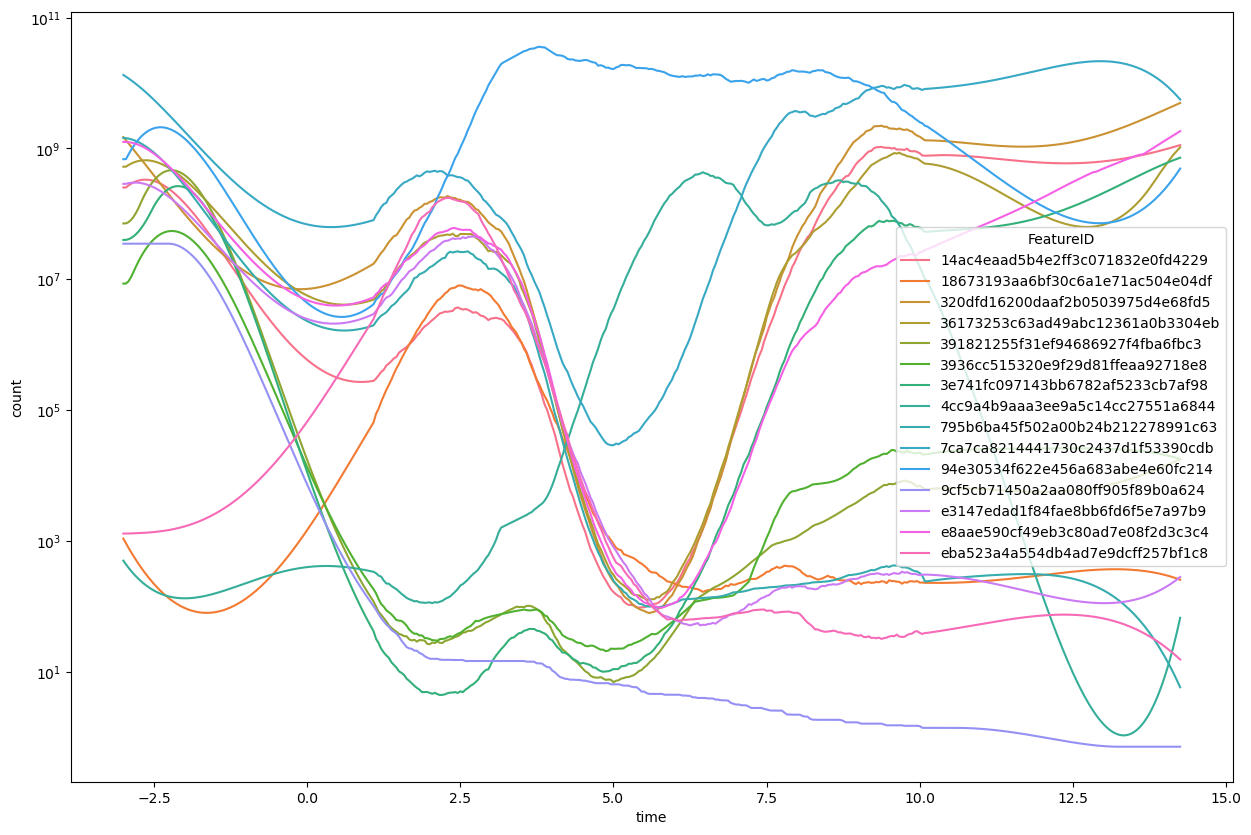

In [ ]:


fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=FBA_biomass_df_plot, x='time', y='count', hue = 'FeatureID')
plt.yscale('log')
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_abundances_over_time_test_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

In [ ]:
FBA_biomass_df_plot

FBA_biomass_df_plot_unstack = FBA_biomass_df_plot.pivot(index='FeatureID', columns ='time')['count']
FBA_biomass_df_plot_unstack = pd.DataFrame(FBA_biomass_df_plot_unstack.sum(axis=0)).reset_index()
FBA_biomass_df_plot_unstack.columns = ['time', 'abun']
FBA_biomass_df_plot_unstack['time'] = pd.to_numeric(FBA_biomass_df_plot_unstack['time'])
FBA_biomass_df_plot_unstack['time'] = pd.to_numeric(FBA_biomass_df_plot_unstack['time'])

In [ ]:
### Need to plot metabolite trajectories too

met_pool_over_time_df = pd.DataFrame(met_pool_over_time)
met_pool_over_time_df = met_pool_over_time_df.fillna(0)
met_pool_over_time_df_melt= met_pool_over_time_df.melt(ignore_index=False)
met_pool_over_time_df_melt = met_pool_over_time_df_melt.reset_index()
met_pool_over_time_df_melt.columns = ['Time','Metabolite', 'Concentration']
met_pool_over_time_df_melt

,Time,Metabolite,Concentration
0,0,EX_cpd35610_b,2.630000e-01
1,1,EX_cpd35610_b,2.593472e-01
2,2,EX_cpd35610_b,2.557452e-01
3,3,EX_cpd35610_b,2.521932e-01
4,4,EX_cpd35610_b,2.486905e-01
...,...,...,...
57265,410,EX_cpd11580_b,2.949785e-20
57266,411,EX_cpd11580_b,2.908802e-20
57267,412,EX_cpd11580_b,2.868398e-20
57268,413,EX_cpd11580_b,2.828554e-20


In [ ]:
met_pool_over_time_df

,EX_cpd35610_b,EX_cpd01242_b,EX_cpd01293_b,EX_cpd00035_b,EX_cpd01055_b,EX_cpd00224_b,EX_cpd00132_b,EX_cpd00041_b,EX_cpd00158_b,EX_cpd00526_b,...,EX_cpd03279_b,EX_cpd00065_b,EX_cpd00264_b,EX_cpd00180_b,EX_cpd00367_b,EX_cpd00080_b,EX_cpd00731_b,EX_cpd11584_b,EX_cpd11640_b,EX_cpd11580_b
0,0.263000,0.285000,0.305000,11.053000,0.069000,15.784000,0.0,0.243000,0.520000,0.895000,...,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00
1,0.259347,0.281042,0.328056,11.073653,0.074083,15.181959,0.0,0.322542,0.512778,0.882569,...,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00
2,0.255745,0.277138,0.350791,11.088186,0.079096,14.603318,0.0,0.376855,0.504742,0.870312,...,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00
3,0.252193,0.273289,0.373210,11.106961,0.084039,14.020636,0.0,0.422718,0.497117,0.858224,...,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00
4,0.248690,0.269493,0.395319,11.125614,0.088914,13.438711,0.0,0.464025,0.489900,0.846304,...,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,0.000850,0.000921,1.959633,6.936887,0.433817,0.107681,0.0,2.840382,0.000000,0.002893,...,6.303826e-10,0.139304,0.0,3.304839e-12,1.188925e-10,0.0,1.077619e-19,0.0,2.156920e-13,2.949785e-20
411,0.000838,0.000909,1.959708,5.608929,0.433833,0.117644,0.0,2.493029,0.000000,0.002853,...,5.039851e-10,0.135374,0.0,0.000000e+00,1.172412e-10,0.0,1.062652e-19,0.0,2.126962e-13,2.908802e-20
412,0.000827,0.000896,1.959781,5.276739,0.433849,0.127468,0.0,2.122768,0.000000,0.002814,...,4.644979e-10,0.132815,0.0,0.000000e+00,1.156127e-10,0.0,1.047893e-19,0.0,2.097421e-13,2.868398e-20
413,0.000815,0.000884,1.959854,4.930429,0.433865,0.137156,0.0,1.740929,0.000000,0.002775,...,4.270543e-10,0.130224,0.0,0.000000e+00,1.140067e-10,0.0,1.033338e-19,0.0,2.068290e-13,2.828554e-20


In [ ]:
met_pool_over_time_df_melt[met_pool_over_time_df_melt['Concentration'] < 0]

,Time,Metabolite,Concentration


In [ ]:
met_pool_over_time_df_melt[met_pool_over_time_df_melt['Metabolite'] == 'EX_adn(e)']

,Time,Metabolite,Concentration


In [ ]:
total_abun_MDSINE = pd.DataFrame(bi_hourly_resolution_latent_traj.sum(axis=0)).reset_index()
total_abun_MDSINE.columns = ['time', 'abun']
total_abun_MDSINE['time'] = pd.to_numeric(total_abun_MDSINE['time'])
total_abun_MDSINE.max()

time    1.400000e+01
abun    9.220114e+10
dtype: float64

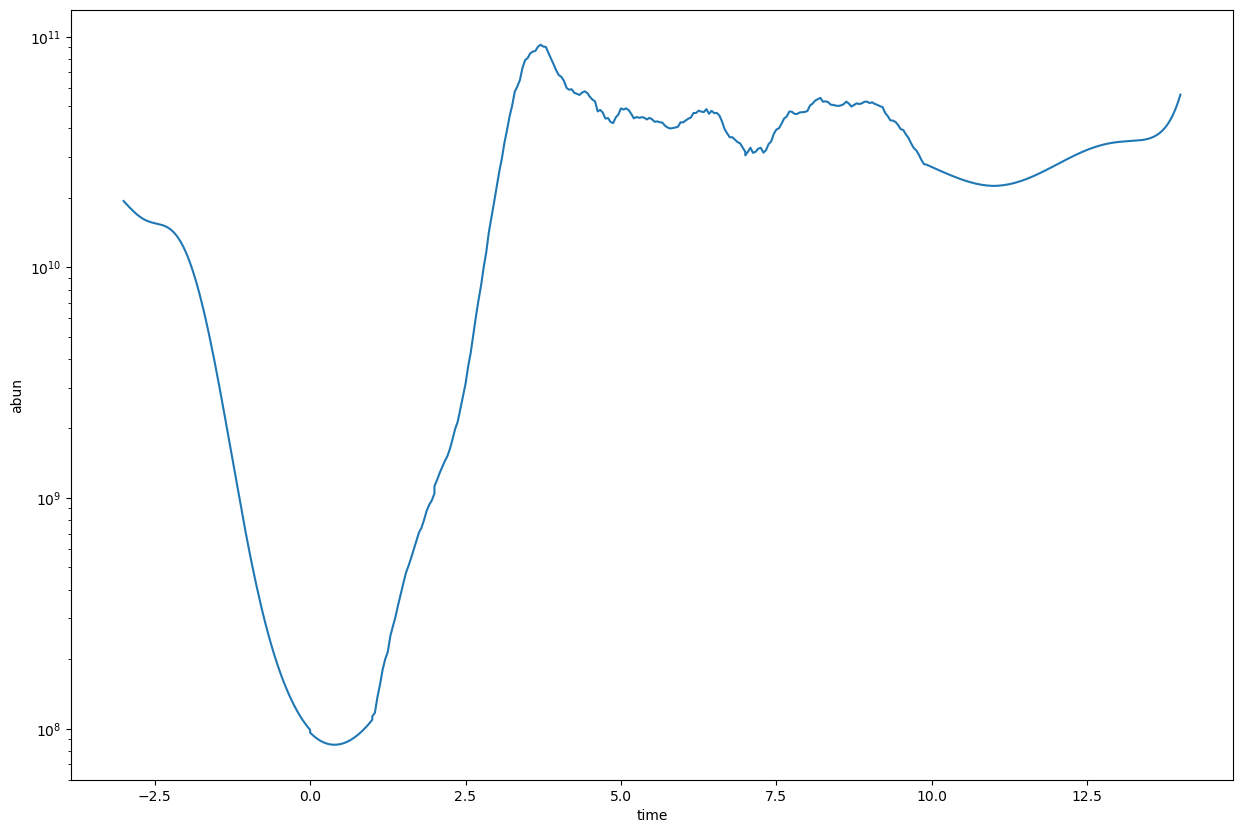

In [ ]:
fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=total_abun_MDSINE, x='time', y='abun')
plt.yscale('log')

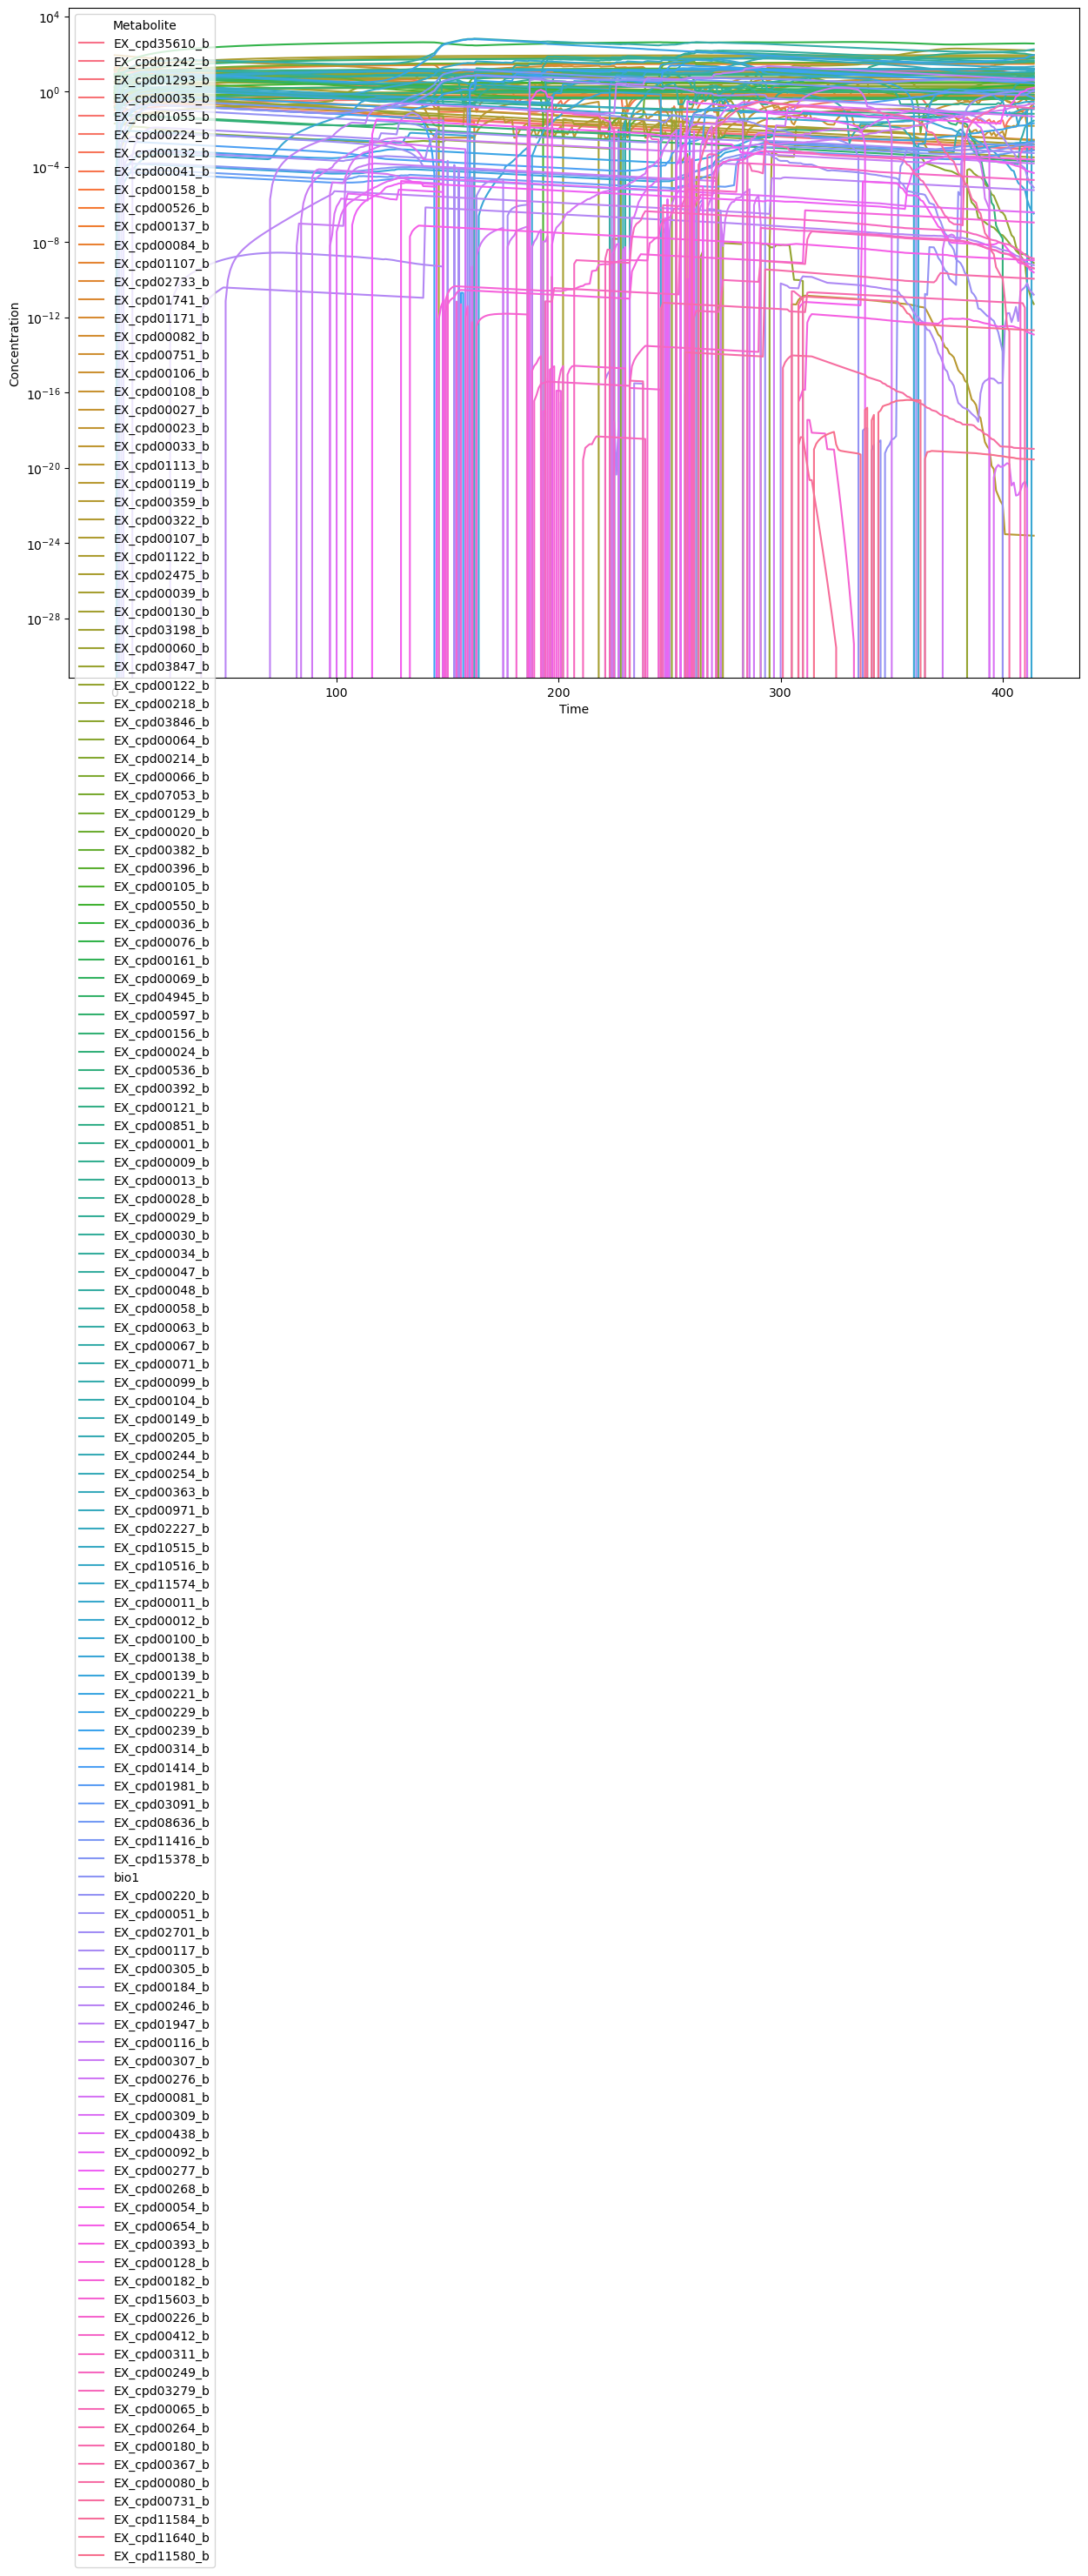

In [ ]:
output_folder = 'filtering_hourly_resolution'

#plot_dir_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_' + output_folder + '/test_' + str(test_num)

plot_dir = Path(plot_dir_path)
os.makedirs(plot_dir, exist_ok=True)

fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=met_pool_over_time_df_melt, x='Time', y='Concentration', hue = 'Metabolite')
plt.yscale('log')
#plt.ylim(-100,500)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_metabolites_over_time_test_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()


                                  HF1152  HF1116  HF1181  HF1205  HF1253  \
FeatureID                                                                  
14ac4eaad5b4e2ff3c071832e0fd4229      27     205      26      22       0   
18673193aa6bf30c6a1e71ac504e04df       0       0       0      10       0   
320dfd16200daaf2b0503975d4e68fd5    1435     232     531     375       0   
36173253c63ad49abc12361a0b3304eb     258     813     261     205       0   
391821255f31ef94686927f4fba6fbc3       0     862       0       0       0   
3936cc515320e9f29d81ffeaa92718e8       0      48       0       0       0   
3e741fc097143bb6782af5233cb7af98       0    1098       0       0       0   
4cc9a4b9aaa3ee9a5c14cc27551a6844       0       0       0       0       0   
795b6ba45f502a00b24b212278991c63     152     405     110     108       0   
7ca7ca8214441730c2437d1f53390cdb    1686    5788    1939    1413       0   
94e30534f622e456a683abe4e60fc214     180    2975     285     184   63472   
9cf5cb71450a

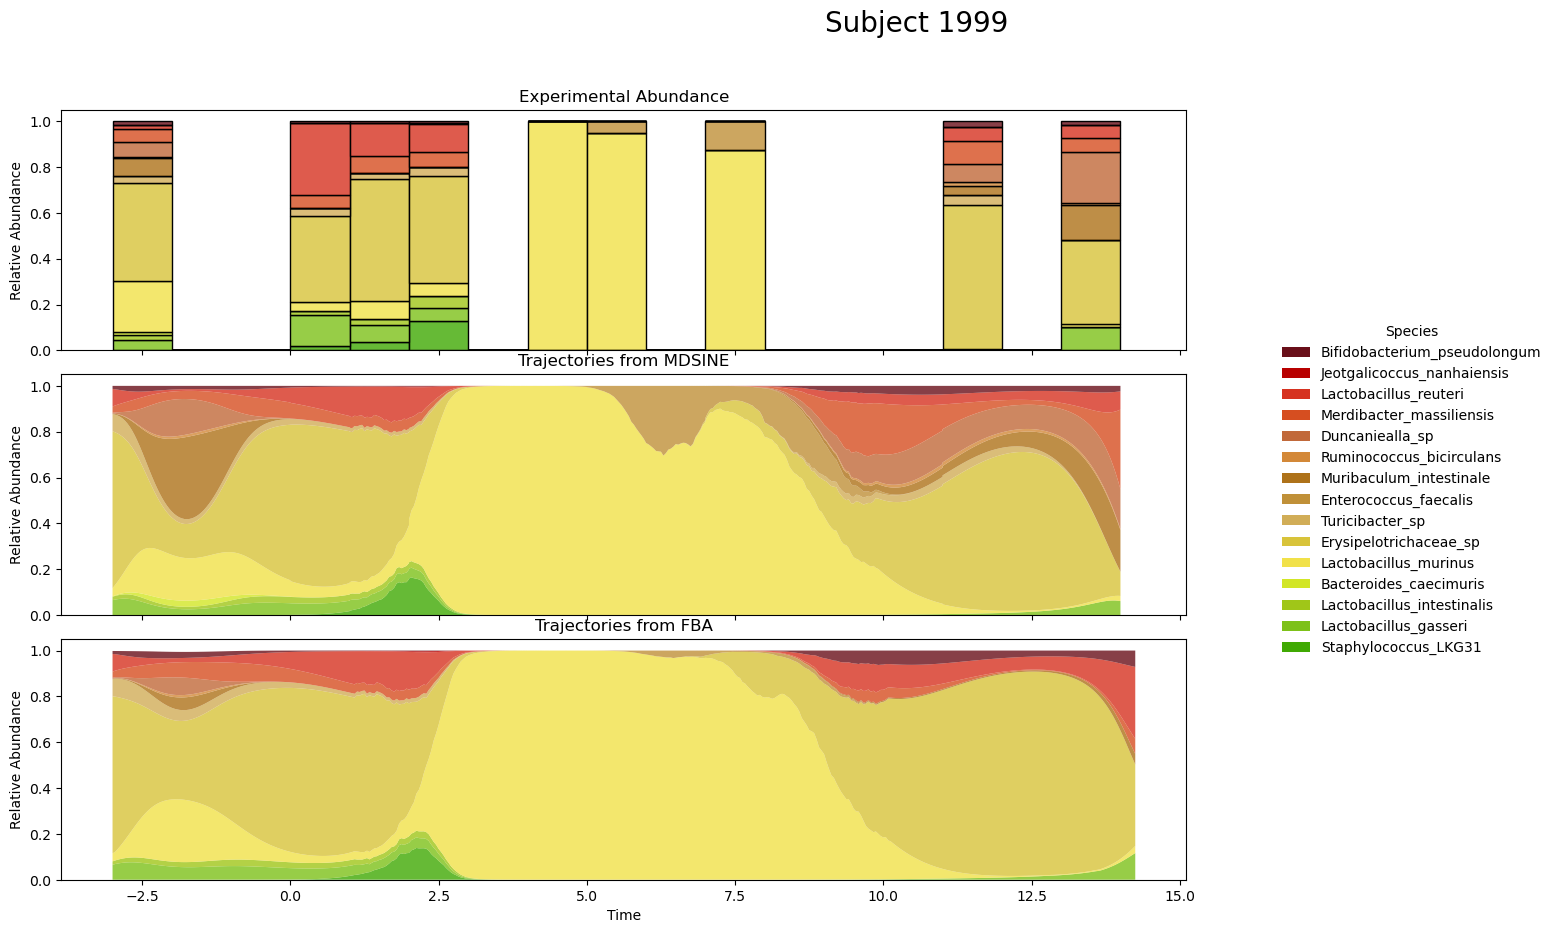

In [ ]:
### Stacked plots 

## Directory to save plots to 


output_folder = 'filtering_hourly_resolution'

#plot_dir_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_' + output_folder + '/test_' + str(test_num)

plot_dir = Path(plot_dir_path)
os.makedirs(plot_dir, exist_ok=True)

samps_for_sub ={}


temp = metadata[metadata['subject'] == subject_to_plot]
testing = counts.filter(temp.index.tolist(), axis=1)
print(testing)
testing = testing.loc[~(testing==0).all(axis=1)]
qpcr_measurements = qpcr.reindex(testing.columns)
qpcr_measurements = qpcr_measurements['measurement1'].to_list()
testing_ra = testing.reindex(index_to_filter_by)
testing_ra = testing/testing.sum(axis=0)
testing_abs_abun = testing_ra*qpcr_measurements
time_dict = dict(zip(temp.index, temp['time'].tolist()))
testing_melt_ra = testing_ra.melt(ignore_index=False)
testing_melt_ra.columns = ['sample', 'count']
testing_melt_ra['time'] = testing_melt_ra['sample'].map(time_dict)
#print(testing_melt_ra.head())
testing_melt_abs_abun = testing_abs_abun.melt(ignore_index=False)
testing_melt_abs_abun.columns = ['sample', 'count']
testing_melt_abs_abun['time'] = testing_melt_abs_abun['sample'].map(time_dict)

# load in MDSINE output for each subject 
output_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/' + output_folder + '/Subject_' + str(subject_to_plot) + '/mean_smoothed.tsv'
MDSINE_output = pd.read_csv(output_path, delimiter='\t', index_col=0)


MDSINE_output = MDSINE_output.reindex(index_to_filter_by)

MDSINE_output = MDSINE_output/MDSINE_output.sum(axis=0)
MDSINE_output = MDSINE_output.melt(ignore_index=False)
MDSINE_output = MDSINE_output.reset_index()
MDSINE_output.columns = ['FeatureID','time', 'count']


###################
### Second plot ###
###################

fig, (ax_top, ax_middle, ax_bottom) = plt.subplots(
3, 1, figsize=(18, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]}
)

# Ensure time is numeric
MDSINE_output['time'] = pd.to_numeric(MDSINE_output['time'])
testing_melt_ra['time'] = pd.to_numeric(testing_melt_ra['time'])
FBA_biomass_df['time'] = pd.to_numeric(FBA_biomass_df['time'])

# Define stacking order
feature_order = MDSINE_output['FeatureID'].value_counts().index.tolist()
reversed_order = feature_order[::-1]  # For stackplot

# Assign consistent colors


twentysiz = [
    "#690f19", "#b80000", "#d63220", "#d64e20", "#c1693a",  # reds/oranges
    "#d38838", "#AE7219", "#C09038", "#d1ad57", "#d8c33a", "#f1e149",  # orange/yellows
    "#d2e626", "#a0c618", "#7dc119", "#40a903", "#0c9515",  # yellow/green
    "#1da05a", "#1da18d", "#1d91a1", "#1d6ea1", "#1d31a1",  # green/blue
    "#1a1a87", "#5b5bc9", "#8d8df1", "#8670cc", "#9870cc",  # blue/purple
    "#000000"  # black
]
#sns.set_style("dark")  # or "whitegrid", "dark", etc.
#sns.set_context("notebook")  # or "paper", "talk", "poster"
sns.set_palette(twentysiz)

#palette = sns.color_palette("Spectral", n_colors=len(feature_order))  # or use 'husl', 'Set2', etc.
color_map = dict(zip(feature_order, twentysiz))

# Pivot for stackplot in reversed stacking order
continuous_pivot_MDSINE = (
    MDSINE_output
    .pivot(index='time', columns='FeatureID', values='count')
    .fillna(0)
)[reversed_order]

# Pivot for stackplot in reversed stacking order
continuous_pivot_FBA = (
    FBA_biomass_df
    .pivot(index='time', columns='FeatureID', values='count')
    .fillna(0)
)[reversed_order]



# Set categorical order for histogram
testing_melt_ra['FeatureID'] = pd.Categorical(testing_melt_ra.reset_index()['FeatureID'], categories=feature_order, ordered=True)

# Top: histogram
sns.histplot(
    data=testing_melt_ra,
    x='time',
    weights='count',
    hue='FeatureID',
    multiple='stack',
    ax=ax_top,
    alpha=0.8,
    binwidth=1,
    palette=color_map
)
ax_top.legend_.remove()
ax_top.set_ylabel('Relative Abundance')
ax_top.set_title('Experimental Abundance')
#ax_top.legend(title='FeatureID', bbox_to_anchor=(1.05, 1), loc='upper left')

# Middle: stackplot using reversed order and matching colors
ax_middle.stackplot(
    continuous_pivot_MDSINE.index,
    *[continuous_pivot_MDSINE[col] for col in continuous_pivot_MDSINE.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)
ax_middle.set_ylabel('Relative Abundance')
#ax_middle.set_xlabel('Time')
ax_middle.set_title('Trajectories from MDSINE')

# Bottom: stackplot using FBA output 

# Bottom: stackplot using reversed order and matching colors
ax_bottom.stackplot(
    continuous_pivot_FBA.index,
    *[continuous_pivot_FBA[col] for col in continuous_pivot_FBA.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)
ax_bottom.set_ylabel('Relative Abundance')
ax_bottom.set_xlabel('Time')
ax_bottom.set_title('Trajectories from FBA')



# Tidy layout
ax_top.tick_params(labelbottom=False)
plt.subplots_adjust(hspace=0.1, right=0.75)


# Create custom legend handles using your color map
legend_elements = [
    Patch(facecolor=color_map[feat], label=ASV_string_to_species_names_dict[feat])
    for feat in feature_order
]

# Add custom legend to the *figure* (not either axis), outside plot
fig.legend(
    handles=legend_elements,
    title='Species',
    loc='center left',
    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
    borderaxespad=0,
    frameon=False,
    ncol=1
)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=0.1, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.6, fontsize = 20)
plt.subplots_adjust(right=0.75)
second_plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_stacked_hist_line_plots_FBA_' + str(test_num) + '.pdf'
plt.savefig(second_plot_file_name, bbox_inches="tight")
plt.show()




In [ ]:
testing_melt_abs_abun_unstack = testing_melt_abs_abun.reset_index().pivot(index='FeatureID', columns ='time')['count']
testing_melt_abs_abun_unstack = pd.DataFrame(testing_melt_abs_abun_unstack.sum(axis=0)).reset_index()
testing_melt_abs_abun_unstack.columns = ['time', 'abun']
testing_melt_abs_abun_unstack['time'] = pd.to_numeric(testing_melt_abs_abun_unstack['time'])
testing_melt_abs_abun_unstack

,time,abun
0,-3.0,8.858108e+09
1,0.0,7.349007e+05
2,1.0,4.310441e+05
3,2.0,1.438017e+09
4,4.0,4.944492e+10
5,5.0,2.867479e+10
6,7.0,3.360148e+10
7,11.0,1.637381e+10
8,14.0,2.486635e+10


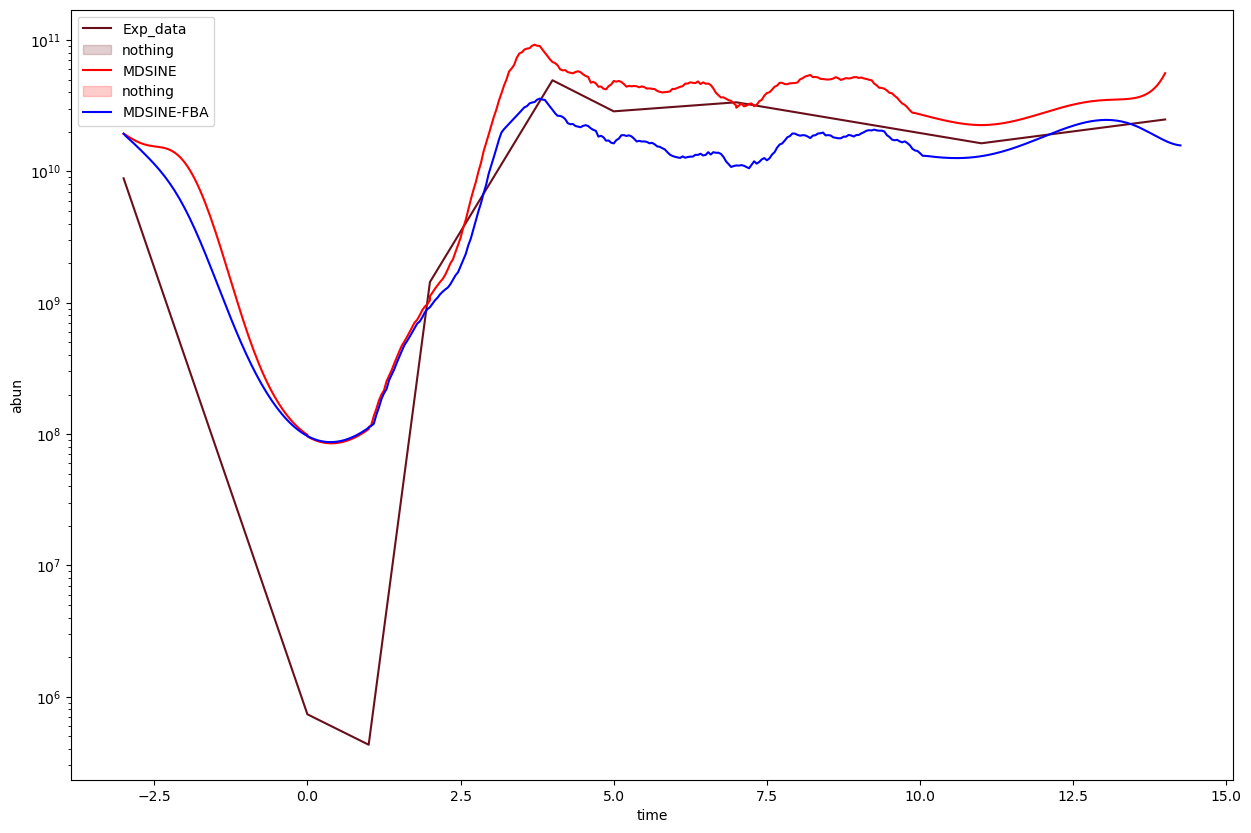

In [ ]:
fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=testing_melt_abs_abun_unstack, x='time', y='abun')
sns.lineplot(data=total_abun_MDSINE, x='time', y='abun', color = 'red')
sns.lineplot(data=FBA_biomass_df_plot_unstack, x='time', y='abun', color = 'blue')
plt.legend(['Exp_data', 'nothing', 'MDSINE', 'nothing', 'MDSINE-FBA'])
plt.yscale('log')
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_comparison_abs_abun_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")

In [ ]:
### Here plot the metabolomics data 
metabolomics_metadata_sub_1948 = metabolomics_metadata_raw[metabolomics_metadata_raw['Mouse'] == float(subject_to_predict)]
metabolomics_metadata_sub_1948

met_days_1948_dict = dict(zip(metabolomics_metadata_sub_1948.index.tolist(),metabolomics_metadata_sub_1948['Rec_day_adj'].tolist() ))
met_days_1948_dict

metabolomics_metadata_sub_2000 = metabolomics_metadata_raw[metabolomics_metadata_raw['Mouse'] == 2000.0]
metabolomics_metadata_sub_2000

met_days_2000_dict = dict(zip(metabolomics_metadata_sub_2000.index.tolist(),metabolomics_metadata_sub_2000['Rec_day_adj'].tolist() ))
met_days_2000_dict

{'HF2772': 14,
 'HF1115': -3,
 'HF1151': 0,
 'HF1228': 3,
 'HF1275': 5,
 'HF1299': 7,
 'HF1349': 11}

In [ ]:
### Filter the metabolomics data by the correct samples

metabolomics_data_sub_1948 = metabolomics_data[metabolomics_data['SampleName'].isin(met_days_1948_dict.keys())]
metabolomics_data_sub_1948 = metabolomics_data_sub_1948.set_index('SampleName')
metabolomics_data_sub_1948_ra = metabolomics_data_sub_1948.T/metabolomics_data_sub_1948.T.sum(axis=0)
metabolomics_data_sub_1948_ra.columns = np.sort(list(met_days_1948_dict.values()))

#change_met_ids = bigg_to_agora_exchange_ids(metabolomics_data_sub_1948_ra.index.tolist())
change_met_ids = []
for i in metabolomics_data_sub_1948_ra.index.tolist():
    change_met_ids.append('EX_' + bigg_to_modelseed[i] + '_b')
metabolomics_data_sub_1948_ra.index = change_met_ids
#metabolomics_data_sub_1948_ra.head()

metabolomics_data_sub_2000 = metabolomics_data[metabolomics_data['SampleName'].isin(met_days_2000_dict.keys())]
metabolomics_data_sub_2000 = metabolomics_data_sub_2000.set_index('SampleName')
metabolomics_data_sub_2000_ra = metabolomics_data_sub_2000.T/metabolomics_data_sub_2000.T.sum(axis=0)
### columns were placed incorrectly it seems so need to match 
change_met_ids = []
for i in metabolomics_data_sub_2000_ra.index.tolist():
    change_met_ids.append('EX_' + bigg_to_modelseed[i] + '_b')
metabolomics_data_sub_2000_ra.index = change_met_ids
metabolomics_data_sub_2000_ra.columns = np.sort(list(met_days_2000_dict.values()))

change_met_ids = metabolomics_data_sub_2000_ra.index.tolist()


bigg_to_modelseed
#metabolomics_data_sub_2000_ra.index = change_met_ids

{'h2o': 'cpd00001',
 'oh1': 'cpd00001',
 'atp': 'cpd00002',
 'nad': 'cpd00003',
 'nadh': 'cpd00004',
 'nadph': 'cpd00005',
 'nadp': 'cpd00006',
 'o2': 'cpd00007',
 'adp': 'cpd00008',
 'pi': 'cpd00009',
 'coa': 'cpd00010',
 'co2': 'cpd00011',
 'ppi': 'cpd00012',
 'nh3': 'cpd00013',
 'nh4': 'cpd00013',
 'udp': 'cpd00014',
 'fad': 'cpd00015',
 'pydx5p': 'cpd00016',
 'amet': 'cpd00017',
 'amp': 'cpd00018',
 'ahcys': 'cpd00019',
 'pyr': 'cpd00020',
 'accoa': 'cpd00022',
 'glu__L': 'cpd00023',
 'akg': 'cpd00024',
 'h2o2': 'cpd00025',
 'udpg': 'cpd00026',
 'glc__D': 'cpd00027',
 'pheme': 'cpd00028',
 'ac': 'cpd00029',
 'mn2': 'cpd00030',
 'gdp': 'cpd00031',
 'oaa': 'cpd00032',
 'gly': 'cpd00033',
 'zn2': 'cpd00034',
 'ala__L': 'cpd00035',
 'succ': 'cpd00036',
 'uacgam': 'cpd00037',
 'gtp': 'cpd00038',
 'lys__L': 'cpd00039',
 'glx': 'cpd00040',
 'asp__L': 'cpd00041',
 'gthrd': 'cpd00042',
 'udpgal': 'cpd00043',
 'paps': 'cpd00044',
 'pap': 'cpd00045',
 'cmp': 'cpd00046',
 'for': 'cpd00047',
 '

In [ ]:
metabolomics_data_sub_2000_ra

,-3,0,3,5,7,11,14
EX_cpd35610_b,0.001108,0.000109,0.000000,0.000000,0.000000,0.001992,0.000309
EX_cpd01242_b,0.001200,0.000255,0.004831,0.001997,0.002819,0.000923,0.000661
EX_cpd01293_b,0.001285,0.004200,0.016028,0.029803,0.028420,0.001434,0.007060
EX_cpd00035_b,0.046558,0.006271,0.034269,0.043679,0.048582,0.033155,0.119015
EX_cpd01055_b,0.000291,0.000962,0.004169,0.003182,0.002255,0.000231,0.000172
EX_cpd00224_b,0.066486,0.049681,0.008473,0.020081,0.029647,0.072922,0.032765
EX_cpd00132_b,0.000000,0.000816,0.003145,0.008821,0.011209,0.000000,0.000869
EX_cpd00041_b,0.001024,0.006376,0.048476,0.080517,0.073653,0.006959,0.033612
EX_cpd00158_b,0.002190,0.000000,0.004365,0.003465,0.003913,0.005047,0.003189
EX_cpd00526_b,0.003770,0.001046,0.000858,0.001220,0.001128,0.001324,0.000603


In [ ]:
met_pool_over_time_df_melt

,Time,Metabolite,Concentration
0,0,EX_cpd35610_b,2.630000e-01
1,1,EX_cpd35610_b,2.593472e-01
2,2,EX_cpd35610_b,2.557452e-01
3,3,EX_cpd35610_b,2.521932e-01
4,4,EX_cpd35610_b,2.486905e-01
...,...,...,...
57265,410,EX_cpd11580_b,2.949785e-20
57266,411,EX_cpd11580_b,2.908802e-20
57267,412,EX_cpd11580_b,2.868398e-20
57268,413,EX_cpd11580_b,2.828554e-20


In [ ]:
met_pool_over_time_df_melt_filt = met_pool_over_time_df_melt.set_index('Metabolite').loc[change_met_ids].reset_index()
met_pool_over_time_df_melt_filt.head()

,Metabolite,Time,Concentration
0,EX_cpd35610_b,0,0.263000
1,EX_cpd35610_b,1,0.259347
2,EX_cpd35610_b,2,0.255745
3,EX_cpd35610_b,3,0.252193
4,EX_cpd35610_b,4,0.248690


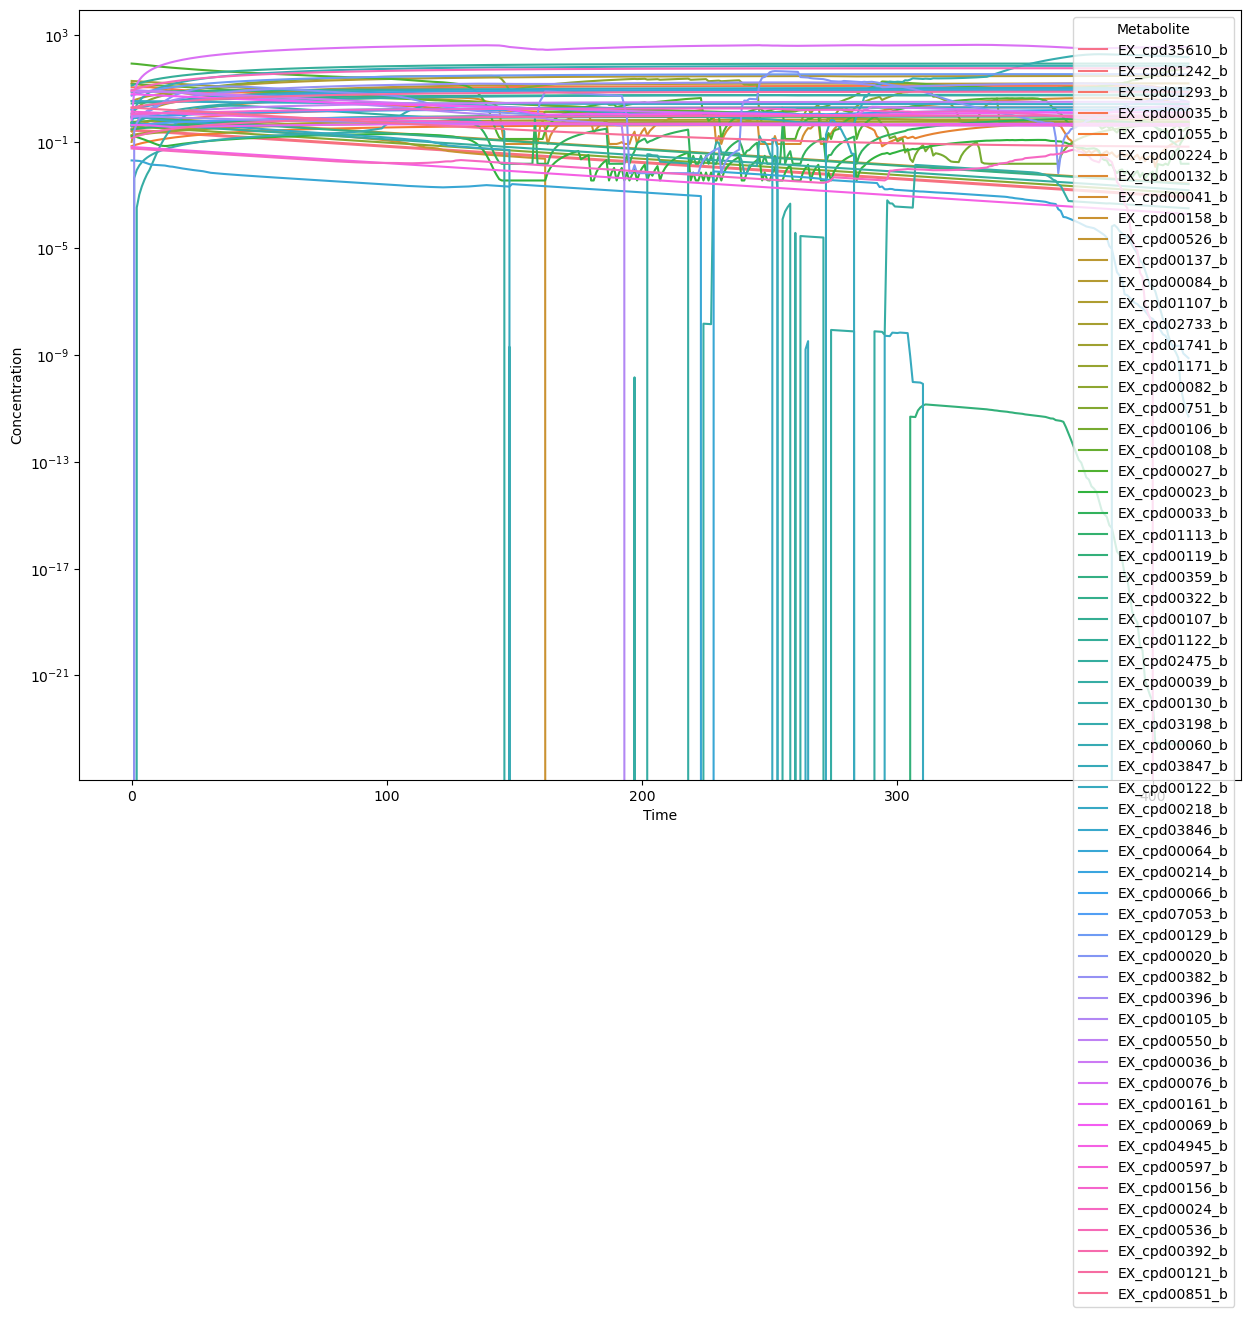

In [ ]:
fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=met_pool_over_time_df_melt_filt, x='Time', y='Concentration', hue = 'Metabolite')
plt.yscale('log')
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_metabolites_over_time_test_filt' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()


In [ ]:

metabolomics_data_sub_1948_ra_melt = metabolomics_data_sub_1948_ra.melt(ignore_index=False).reset_index()
metabolomics_data_sub_1948_ra_melt.columns = ['metabolites', 'time', 'concentration']
metabolomics_data_sub_1948_ra_melt.head()

metabolomics_data_sub_2000_ra_melt = metabolomics_data_sub_2000_ra.melt(ignore_index=False).reset_index()
metabolomics_data_sub_2000_ra_melt.columns = ['metabolites', 'time', 'concentration']
metabolomics_data_sub_2000_ra_melt.head()

,metabolites,time,concentration
0,EX_cpd35610_b,-3,0.001108
1,EX_cpd01242_b,-3,0.001200
2,EX_cpd01293_b,-3,0.001285
3,EX_cpd00035_b,-3,0.046558
4,EX_cpd01055_b,-3,0.000291


In [ ]:
cmpd_names_adjust = []
for i in cmpd_names:
    cmpd_names_adjust.append('EX_' + i + '_b')

In [ ]:
### Prepare the simulation metabolomic data 

#met_pool_over_time_df_filt = met_pool_over_time_df.T.loc[agora_ex_ids_list]
met_pool_over_time_df_filt = met_pool_over_time_df.T.loc[cmpd_names_adjust]
met_pool_over_time_df_filt = met_pool_over_time_df_filt.T.reset_index()
met_pool_over_time_df_filt['index'] = (met_pool_over_time_df_filt['index']/time_scaler)-3
met_pool_over_time_df_filt = met_pool_over_time_df_filt.set_index('index').T
met_pool_over_time_df_filt_ra = met_pool_over_time_df_filt/met_pool_over_time_df_filt.sum(axis=0)
met_pool_over_time_df_filt_ra_melt = met_pool_over_time_df_filt_ra.melt(ignore_index=False).reset_index()
met_pool_over_time_df_filt_ra_melt.columns = ['metabolites', 'time', 'concentration']
met_pool_over_time_df_filt_ra_melt.head()
# use this to filter, agora_ex_ids_list

,metabolites,time,concentration
0,EX_cpd35610_b,-3.0,0.001108
1,EX_cpd01242_b,-3.0,0.001200
2,EX_cpd01293_b,-3.0,0.001285
3,EX_cpd00035_b,-3.0,0.046558
4,EX_cpd01055_b,-3.0,0.000291


In [ ]:
met_pool_over_time_df_filt

index,-3.000000,-2.958333,-2.916667,-2.875000,-2.833333,-2.791667,-2.750000,-2.708333,-2.666667,-2.625000,...,13.875000,13.916667,13.958333,14.000000,14.041667,14.083333,14.125000,14.166667,14.208333,14.250000
EX_cpd35610_b,0.263,0.259347,0.255745,0.252193,0.248690,0.245236,0.241830,0.238472,0.235160,0.231893,...,9.118553e-04,8.991906e-04,8.867019e-04,8.743866e-04,8.622423e-04,8.502667e-04,8.384575e-04,8.268122e-04,8.153287e-04,8.040047e-04
EX_cpd01242_b,0.285,0.281042,0.277138,0.273289,0.269493,0.265751,0.262060,0.258420,0.254831,0.251291,...,9.881322e-04,9.744081e-04,9.608747e-04,9.475292e-04,9.343691e-04,9.213917e-04,9.085946e-04,8.959752e-04,8.835311e-04,8.712599e-04
EX_cpd01293_b,0.305,0.328056,0.350791,0.373210,0.395319,0.417120,0.438618,0.459818,0.480723,0.501338,...,1.959245e+00,1.959325e+00,1.959403e+00,1.959481e+00,1.959558e+00,1.959633e+00,1.959708e+00,1.959781e+00,1.959854e+00,1.959925e+00
EX_cpd00035_b,11.053,11.073653,11.088186,11.106961,11.125614,11.144159,11.144621,11.102439,10.991550,10.857237,...,1.023006e+01,9.161861e+00,8.831053e+00,7.644360e+00,7.303567e+00,6.936887e+00,5.608929e+00,5.276739e+00,4.930429e+00,4.574856e+00
EX_cpd01055_b,0.069,0.074083,0.079096,0.084039,0.088914,0.093720,0.098460,0.103135,0.107744,0.112289,...,4.337310e-01,4.337487e-01,4.337660e-01,4.337832e-01,4.338001e-01,4.338167e-01,4.338332e-01,4.338494e-01,4.338654e-01,4.338811e-01
EX_cpd00224_b,15.784,15.181959,14.603318,14.020636,13.438711,12.862330,12.296079,11.744164,11.210283,10.697533,...,5.572218e-02,6.640660e-02,7.694262e-02,8.733230e-02,9.757769e-02,1.076808e-01,1.176435e-01,1.274679e-01,1.371559e-01,1.467093e-01
EX_cpd00132_b,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_cpd00041_b,0.243,0.322542,0.376855,0.422718,0.464025,0.504719,0.545077,0.585911,0.628149,0.672665,...,3.503652e+00,3.317473e+00,3.113990e+00,3.036922e+00,2.953205e+00,2.840382e+00,2.493029e+00,2.122768e+00,1.740929e+00,1.344891e+00
EX_cpd00158_b,0.520,0.512778,0.504742,0.497117,0.489900,0.483080,0.476370,0.469754,0.463230,0.456796,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_cpd00526_b,0.895,0.882569,0.870312,0.858224,0.846304,0.834550,0.822959,0.811529,0.800258,0.789143,...,3.103082e-03,3.059983e-03,3.017484e-03,2.975574e-03,2.934247e-03,2.893493e-03,2.853306e-03,2.813677e-03,2.774598e-03,2.736062e-03


Text(0.5, 1.0, 'Experimental Abundance')

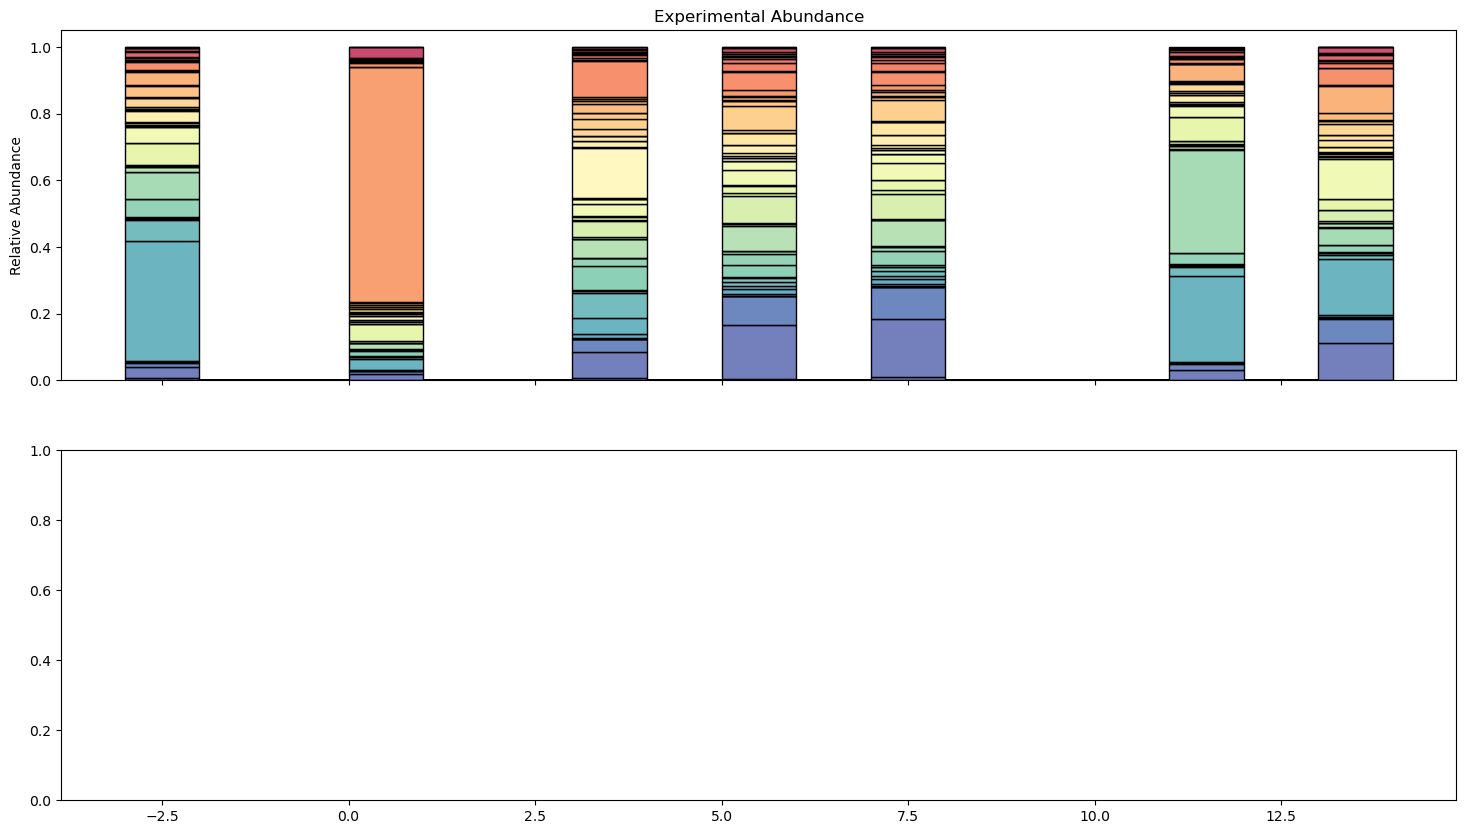

In [ ]:
fig, (ax_top, ax_bottom) = plt.subplots(
2, 1, figsize=(18, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1]}
)

# Define stacking order
feature_order = metabolomics_data_sub_2000_ra_melt['metabolites'].value_counts().index.tolist()
reversed_order = feature_order[::-1]  # For stackplot



palette = sns.color_palette("Spectral", n_colors=len(feature_order))  # or use 'husl', 'Set2', etc.
color_map = dict(zip(feature_order, palette))

# Pivot for stackplot in reversed stacking order
met_pool_over_time_df_filt_ra_pivot = (
    met_pool_over_time_df_filt_ra_melt
    .pivot(index='time', columns='metabolites', values='concentration')
    .fillna(0)
)[reversed_order]

# Set categorical order for histogram
metabolomics_data_sub_2000_ra_melt['metabolites'] = pd.Categorical(metabolomics_data_sub_2000_ra_melt.reset_index()['metabolites'], categories=feature_order, ordered=True)

# Top: histogram
sns.histplot(
    data=metabolomics_data_sub_2000_ra_melt,
    x='time',
    weights='concentration',
    hue='metabolites',
    multiple='stack',
    ax=ax_top,
    alpha=0.8,
    binwidth=1,
    palette=color_map
)
ax_top.legend_.remove()
ax_top.set_ylabel('Relative Abundance')
ax_top.set_title('Experimental Abundance')
#ax_top.legend(title='FeatureID', bbox_to_anchor=(1.05, 1), loc='upper left')


In [ ]:
met_pool_over_time_df_filt_ra_pivot.sum(axis=1)

time
-3.000000     1.0
-2.958333     1.0
-2.916667     1.0
-2.875000     1.0
-2.833333     1.0
             ... 
 14.083333    1.0
 14.125000    1.0
 14.166667    1.0
 14.208333    1.0
 14.250000    1.0
Length: 415, dtype: float64

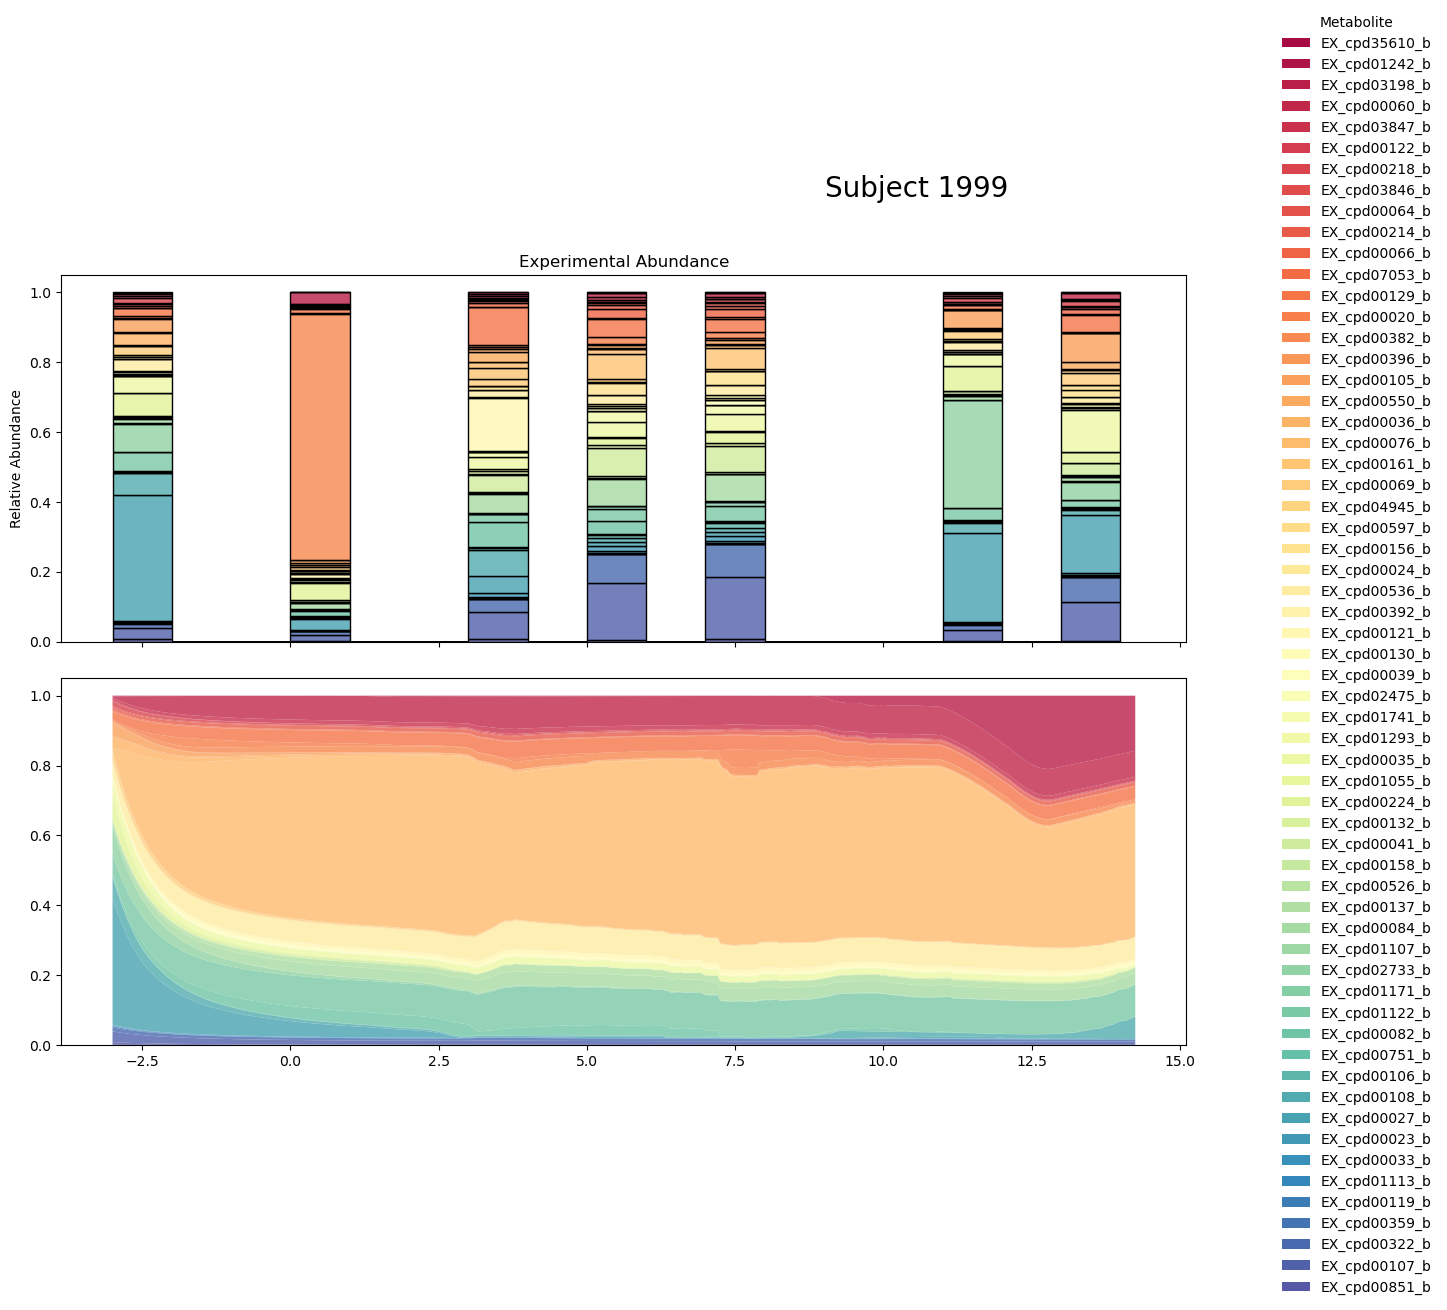

In [ ]:
fig, (ax_top, ax_bottom) = plt.subplots(
2, 1, figsize=(18, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1]}
)

# Define stacking order
feature_order = metabolomics_data_sub_1948_ra_melt['metabolites'].value_counts().index.tolist()
reversed_order = feature_order[::-1]  # For stackplot



palette = sns.color_palette("Spectral", n_colors=len(feature_order))  # or use 'husl', 'Set2', etc.
color_map = dict(zip(feature_order, palette))

# Pivot for stackplot in reversed stacking order
met_pool_over_time_df_filt_ra_pivot = (
    met_pool_over_time_df_filt_ra_melt
    .pivot(index='time', columns='metabolites', values='concentration')
    .fillna(0)
)[reversed_order]

# Set categorical order for histogram
metabolomics_data_sub_1948_ra_melt['metabolites'] = pd.Categorical(metabolomics_data_sub_1948_ra_melt.reset_index()['metabolites'], categories=feature_order, ordered=True)

# Top: histogram
sns.histplot(
    data=metabolomics_data_sub_1948_ra_melt,
    x='time',
    weights='concentration',
    hue='metabolites',
    multiple='stack',
    ax=ax_top,
    alpha=0.8,
    binwidth=1,
    palette=color_map
)
ax_top.legend_.remove()
ax_top.set_ylabel('Relative Abundance')
ax_top.set_title('Experimental Abundance')
#ax_top.legend(title='FeatureID', bbox_to_anchor=(1.05, 1), loc='upper left')

ax_bottom.stackplot(
    met_pool_over_time_df_filt_ra_pivot.index,
    *[met_pool_over_time_df_filt_ra_pivot[col] for col in met_pool_over_time_df_filt_ra_pivot.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)

# Create custom legend handles using your color map
legend_elements = [
    Patch(facecolor=color_map[feat], label=feat)
    for feat in feature_order
]

# Add custom legend to the *figure* (not either axis), outside plot
fig.legend(
    handles=legend_elements,
    title='Metabolite',
    loc='center left',
    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
    borderaxespad=0,
    frameon=False,
    ncol=1
)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=0.1, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.6, fontsize = 20)
plt.subplots_adjust(right=0.75)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_over_time_test_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

In [ ]:
met_days_1948_dict.values()

dict_values([14, -3, 0, 3, 5, 7, 11])

In [ ]:
met_pool_over_time_df_filt_ra

index,-3.000000,-2.958333,-2.916667,-2.875000,-2.833333,-2.791667,-2.750000,-2.708333,-2.666667,-2.625000,...,13.875000,13.916667,13.958333,14.000000,14.041667,14.083333,14.125000,14.166667,14.208333,14.250000
EX_cpd35610_b,0.001108,0.001052,0.001003,0.000959,0.000918,0.000880,0.000845,0.000812,0.000781,0.000751,...,9.597777e-07,9.458293e-07,9.310226e-07,9.187439e-07,9.054820e-07,8.936385e-07,8.843350e-07,8.736293e-07,8.628633e-07,8.523006e-07
EX_cpd01242_b,0.001200,0.001140,0.001087,0.001039,0.000995,0.000954,0.000915,0.000880,0.000846,0.000814,...,1.040063e-06,1.024948e-06,1.008903e-06,9.955970e-07,9.812258e-07,9.683916e-07,9.583098e-07,9.467086e-07,9.350420e-07,9.235957e-07
EX_cpd01293_b,0.001285,0.001330,0.001376,0.001419,0.001459,0.001497,0.001532,0.001565,0.001596,0.001624,...,2.062212e-03,2.060950e-03,2.057342e-03,2.058885e-03,2.057826e-03,2.059593e-03,2.066936e-03,2.070751e-03,2.074115e-03,2.077656e-03
EX_cpd00035_b,0.046558,0.044905,0.043503,0.042238,0.041072,0.039996,0.038929,0.037789,0.036488,0.035178,...,1.076770e-02,9.637063e-03,9.272463e-03,8.032156e-03,7.669827e-03,7.290735e-03,5.915830e-03,5.575527e-03,5.217878e-03,4.849663e-03
EX_cpd01055_b,0.000291,0.000300,0.000310,0.000320,0.000328,0.000336,0.000344,0.000351,0.000358,0.000364,...,4.565257e-04,4.562461e-04,4.554473e-04,4.557888e-04,4.555543e-04,4.559456e-04,4.575711e-04,4.584155e-04,4.591602e-04,4.599440e-04
EX_cpd00224_b,0.066486,0.061565,0.057294,0.053318,0.049612,0.046163,0.042951,0.039973,0.037214,0.034660,...,5.865065e-05,6.985093e-05,8.078850e-05,9.176263e-05,1.024710e-04,1.131735e-04,1.240806e-04,1.346856e-04,1.451522e-04,1.555220e-04
EX_cpd00132_b,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_cpd00041_b,0.001024,0.001308,0.001479,0.001608,0.001713,0.001811,0.001904,0.001994,0.002085,0.002179,...,3.687786e-03,3.489541e-03,3.269639e-03,3.190983e-03,3.101302e-03,2.985269e-03,2.629439e-03,2.242967e-03,1.842427e-03,1.425678e-03
EX_cpd00158_b,0.002190,0.002079,0.001980,0.001890,0.001809,0.001734,0.001664,0.001599,0.001538,0.001480,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_cpd00526_b,0.003770,0.003579,0.003415,0.003264,0.003124,0.002995,0.002875,0.002762,0.002657,0.002557,...,3.266164e-06,3.218697e-06,3.168309e-06,3.126524e-06,3.081393e-06,3.041089e-06,3.009429e-06,2.972997e-06,2.936360e-06,2.900415e-06


In [ ]:
metabolomics_data_sub_1948 = metabolomics_data_sub_1948.T

metabolomics_data_sub_1948.columns = np.sort(list(met_days_1948_dict.values()))
metabolomics_data_sub_1948


,-3,0,3,5,7,11,14
12_Ketolithocholic acid,0.263,0.026,0.000,0.000,0.000,0.596,0.043
drib,0.285,0.061,0.321,0.113,0.170,0.276,0.092
5oxpro,0.305,1.004,1.065,1.686,1.714,0.429,0.983
ala__L,11.053,1.499,2.277,2.471,2.930,9.919,16.571
all__D,0.069,0.230,0.277,0.180,0.136,0.069,0.024
arab__L,15.784,11.875,0.563,1.136,1.788,21.816,4.562
asn__L,0.000,0.195,0.209,0.499,0.676,0.000,0.121
asp__L,0.243,1.524,3.221,4.555,4.442,2.082,4.680
cellb,0.520,0.000,0.290,0.196,0.236,1.510,0.444
cholate,0.895,0.250,0.057,0.069,0.068,0.396,0.084


In [ ]:
#change_met_ids = bigg_to_agora_exchange_ids(metabolomics_data_sub_1948.index.tolist())
metabolomics_data_sub_1948.index = change_met_ids
metabolomics_data_sub_1948.head()

,-3,0,3,5,7,11,14
EX_cpd35610_b,0.263,0.026,0.000,0.000,0.000,0.596,0.043
EX_cpd01242_b,0.285,0.061,0.321,0.113,0.170,0.276,0.092
EX_cpd01293_b,0.305,1.004,1.065,1.686,1.714,0.429,0.983
EX_cpd00035_b,11.053,1.499,2.277,2.471,2.930,9.919,16.571
EX_cpd01055_b,0.069,0.230,0.277,0.180,0.136,0.069,0.024


In [ ]:
'''
from scipy.interpolate import interp1d

# Original experimental time points
orig_time = np.array([-3, 0, 3, 5, 7, 11, 14])

# Example: load your pasted data into a DataFrame
# Replace this with loading your real data if you have it in a file
# The first column should be metabolite IDs, the rest are values
#df = pd.read_csv('your_data.csv', sep='\t', index_col=0)  # Replace with actual path

# New time grid: 415 points evenly spaced between -3 and 14
interp_time = np.linspace(-3, 14, 416)

# Create empty DataFrame to hold interpolated values
interpolated_df = pd.DataFrame(index=metabolomics_data_sub_1948.index, columns=interp_time)

# Perform linear interpolation row by row
for met_id, row in metabolomics_data_sub_1948.iterrows():
    f_interp = interp1d(orig_time, row.values, kind='linear', fill_value="extrapolate")
    interpolated_df.loc[met_id] = f_interp(interp_time)

# Optional: ensure all values are floats
interpolated_df = interpolated_df.astype(float)
interpolated_df
'''

'\nfrom scipy.interpolate import interp1d\n\n# Original experimental time points\norig_time = np.array([-3, 0, 3, 5, 7, 11, 14])\n\n# Example: load your pasted data into a DataFrame\n# Replace this with loading your real data if you have it in a file\n# The first column should be metabolite IDs, the rest are values\n#df = pd.read_csv(\'your_data.csv\', sep=\'\t\', index_col=0)  # Replace with actual path\n\n# New time grid: 415 points evenly spaced between -3 and 14\ninterp_time = np.linspace(-3, 14, 416)\n\n# Create empty DataFrame to hold interpolated values\ninterpolated_df = pd.DataFrame(index=metabolomics_data_sub_1948.index, columns=interp_time)\n\n# Perform linear interpolation row by row\nfor met_id, row in metabolomics_data_sub_1948.iterrows():\n    f_interp = interp1d(orig_time, row.values, kind=\'linear\', fill_value="extrapolate")\n    interpolated_df.loc[met_id] = f_interp(interp_time)\n\n# Optional: ensure all values are floats\ninterpolated_df = interpolated_df.astype(fl

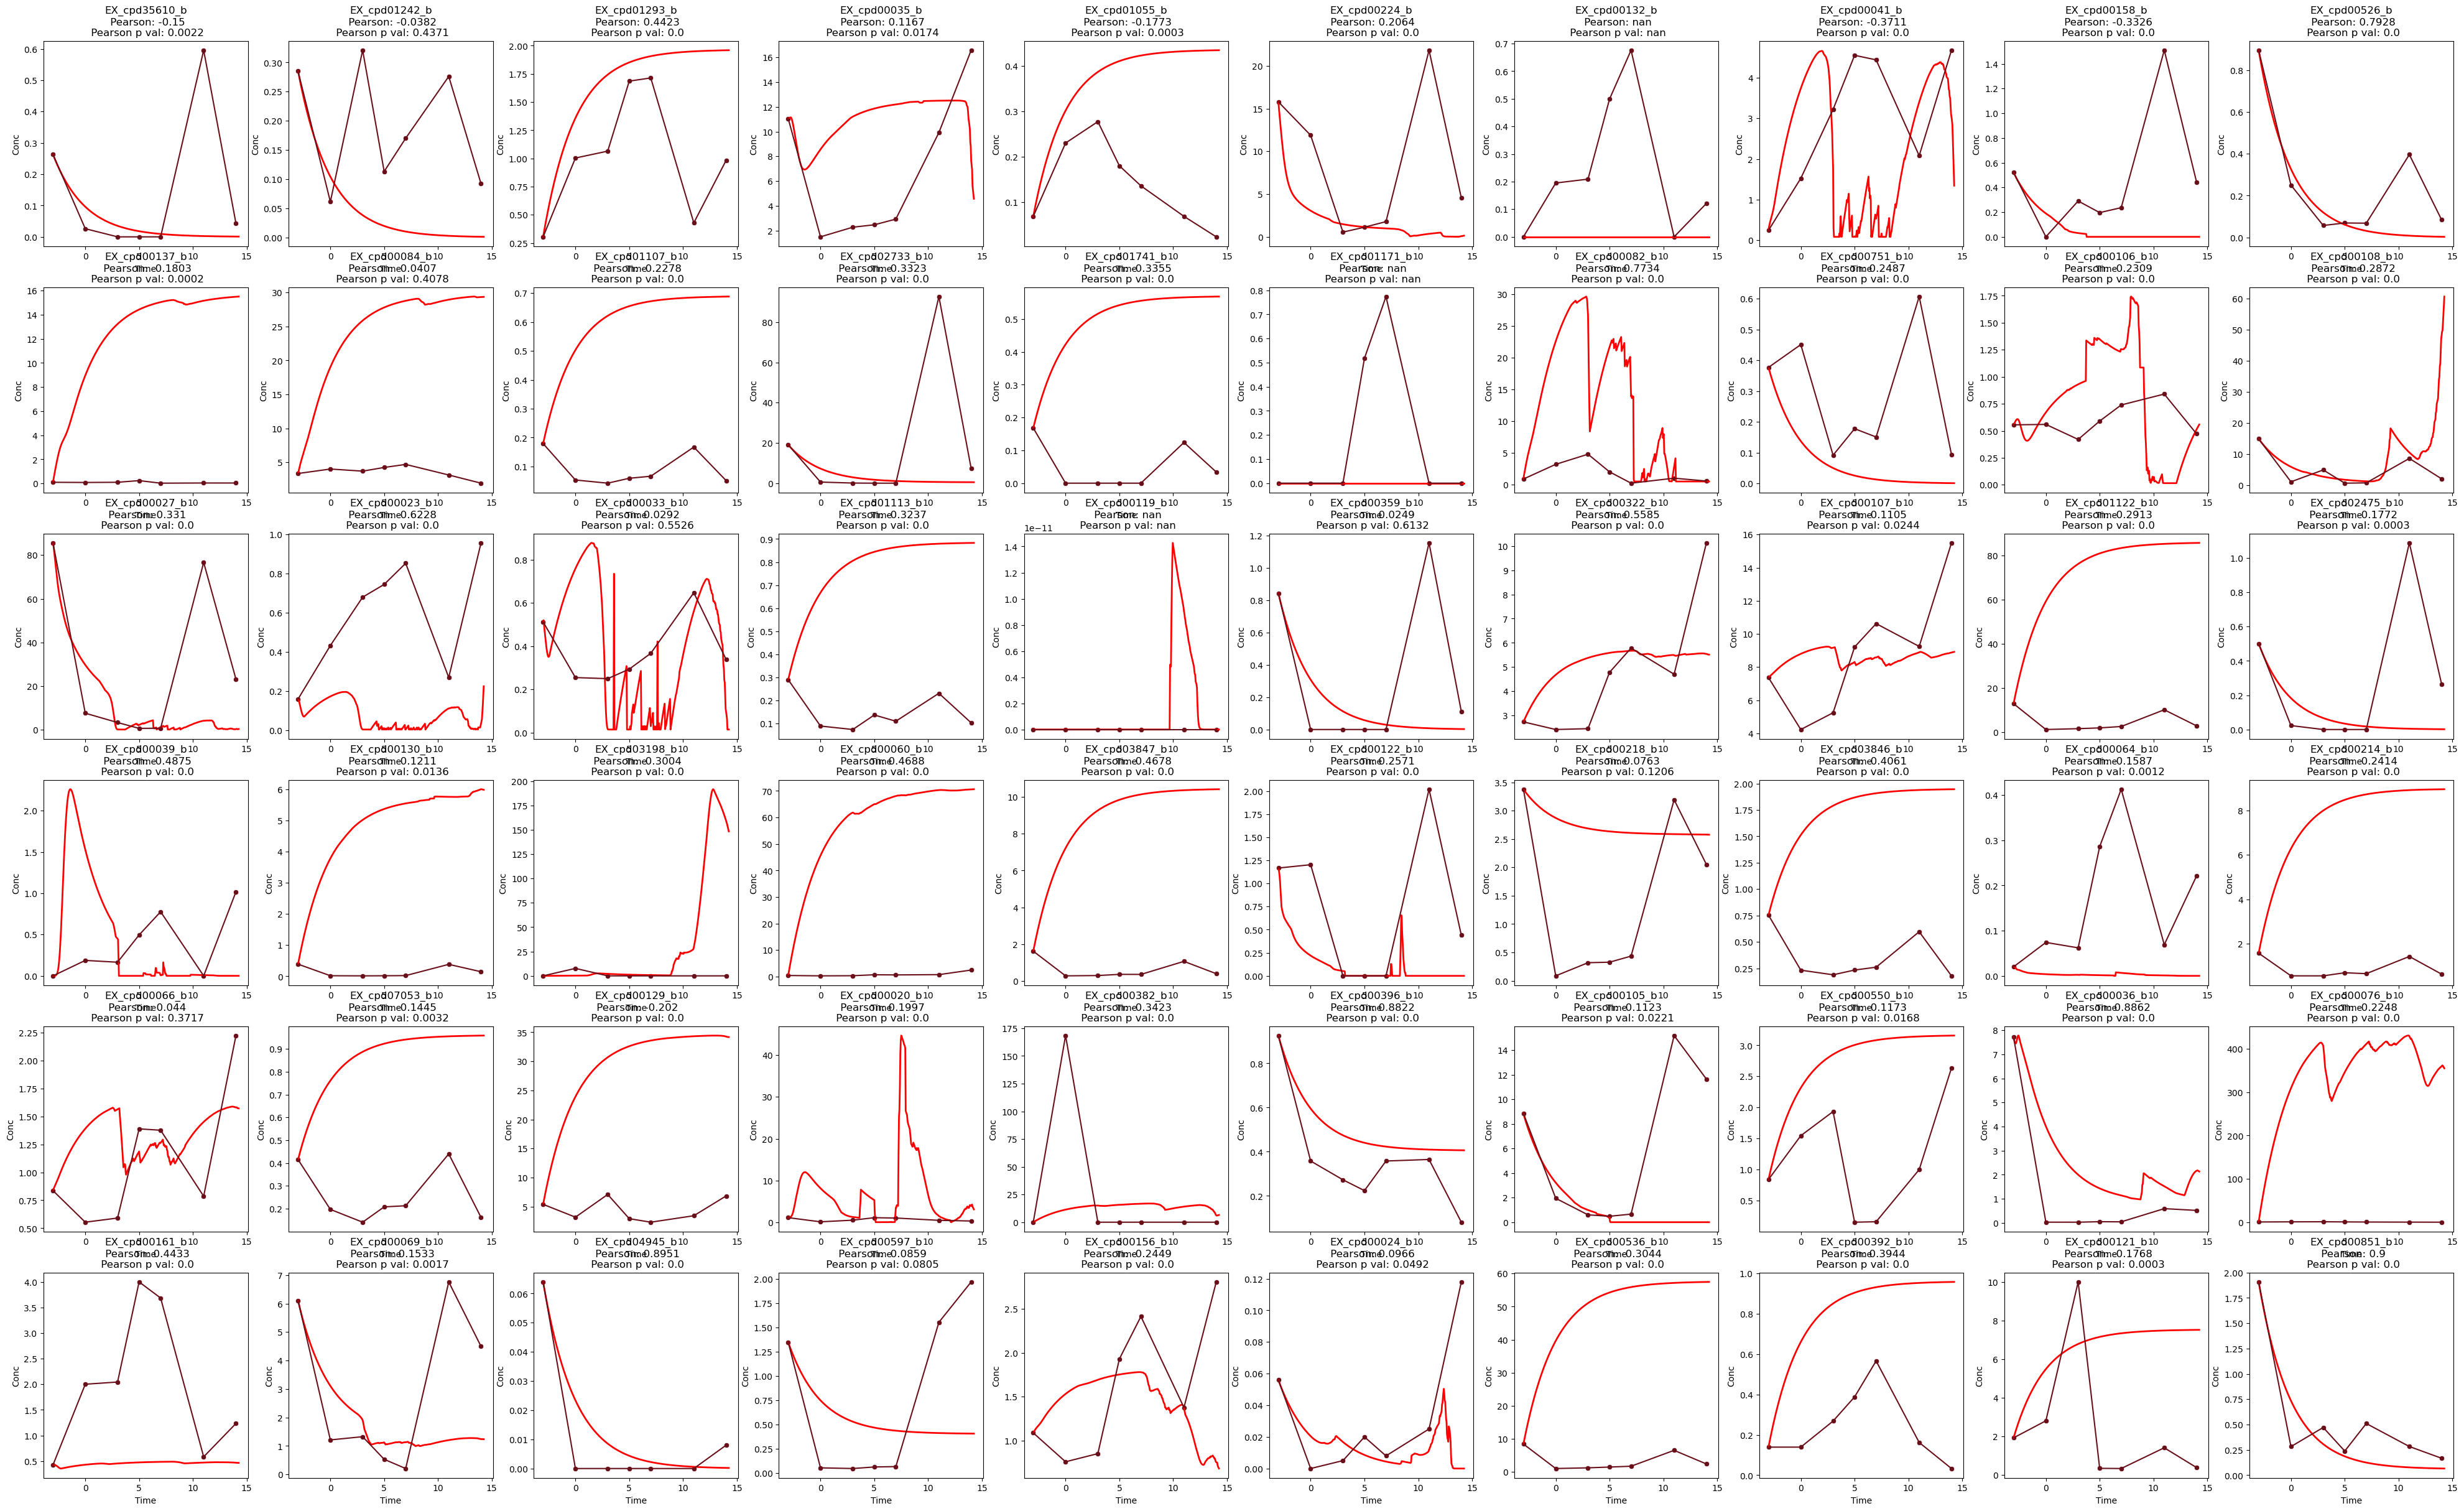

In [ ]:
from scipy.signal import savgol_filter
num_plots = 60
cols = 10  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)
total_rmse = 0
# Flatten the axes array for easy iteration
axes = axes.flatten()
corr_dict = {}
rmse_dict = {}
for i,met in enumerate(met_pool_over_time_df_filt.index.tolist()):
    temp_sim = met_pool_over_time_df_filt.loc[met,:]
    temp_exp = metabolomics_data_sub_1948.loc[met,:]
    temp_int = interpolated_met_values.loc[met,:]

    temp_pearson = pearsonr(temp_sim.to_list(), temp_int.to_list()[:415])

    true = np.array(temp_int.to_list()[:415])
    pred = np.array(temp_sim.to_list())

    rmse = np.sqrt(np.mean((true - pred)**2))
    norm = true.max() - true.min()
    nrmse = rmse/norm
    if np.isnan(nrmse):
        nrmse = 0
    rmse_dict[met] = nrmse
    total_rmse += nrmse

    temp_pearson_stat_round = np.round(temp_pearson.statistic,4)
    temp_pearson_p_val_round = np.round(temp_pearson.pvalue,4)
    corr_dict[met] = temp_pearson_stat_round
        # Scatter plot on the respective subplot
    sns.lineplot(ax=axes[i], x=temp_sim.index.to_list(), y=temp_sim.to_list(), color = 'red', lw = 2)
    #sns.lineplot(ax = axes[i], x = temp_sim.index.to_list(), y = list(savgol_filter(temp_sim.to_list(),300,3)), color = 'blue', lw = 2)
    sns.scatterplot(ax=axes[i], x=temp_exp.index.to_list(), y=temp_exp.to_list())
    sns.lineplot(ax=axes[i], x=temp_exp.index.to_list(), y=temp_exp.to_list())
    #sns.lineplot(ax=axes[i], x=temp_int.index.to_list(), y=temp_int.to_list(), color = 'green')

    axes[i].set_title(f"{met}\n Pearson: {temp_pearson_stat_round}\n Pearson p val: {temp_pearson_p_val_round}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Conc')
    #axes[i].set_yscale('log')
    #axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])
if mets_used_for_constraint == 0:
    subtract = 0
else:
    subtract = len(mets_used_for_constraint)
#plt.subplots_adjust(hspace=.5)
rmse_dict['total_rmse'] = total_rmse/(60-subtract)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_individual_scatterplots_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")

In [ ]:
rmse_MDSINE_vs_FBA = np.sqrt(np.mean((total_abun_MDSINE['abun'].values[:415] - FBA_biomass_df_plot_unstack['abun'].values)**2))
#FBA_biomass_df_plot_unstack
rmse_MDSINE_vs_FBA

20929011082.572704

In [ ]:
### save rmse_dict

rmse_dict['mets_constrained'] = mets_used_for_constraint
rmse_dict['rmse_MDSINE_vs_FBA'] = rmse_MDSINE_vs_FBA

rmse_dict_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_rmse_dict_' + str(test_num) + '.csv'
with open(rmse_dict_file_name, 'w') as file:
     file.write(json.dumps(rmse_dict))

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59],
 [Text(0, 0, 'EX_cpd35610_b'),
  Text(1, 0, 'EX_cpd01242_b'),
  Text(2, 0, 'EX_cpd01293_b'),
  Text(3, 0, 'EX_cpd00035_b'),
  Text(4, 0, 'EX_cpd01055_b'),
  Text(5, 0, 'EX_cpd00224_b'),
  Text(6, 0, 'EX_cpd00132_b'),
  Text(7, 0, 'EX_cpd00041_b'),
  Text(8, 0, 'EX_cpd00158_b'),
  Text(9, 0, 'EX_cpd00526_b'),
  Text(10, 0, 'EX_cpd00137_b'),
  Text(11, 0, 'EX_cpd00084_b'),
  Text(12, 0, 'EX_cpd01107_b'),
  Text(13, 0, 'EX_cpd02733_b'),
  Text(14, 0, 'EX_cpd01741_b'),
  Text(15, 0, 'EX_cpd01171_b'),
  Text(16, 0, 'EX_cpd00082_b'),
  Text(17, 0, 'EX_cpd00751_b'),
  Text(18, 0, 'EX_cpd00106_b'),
  Text(19, 0, 'EX_cpd00108_b'),
  Text(20, 0, 'EX_c

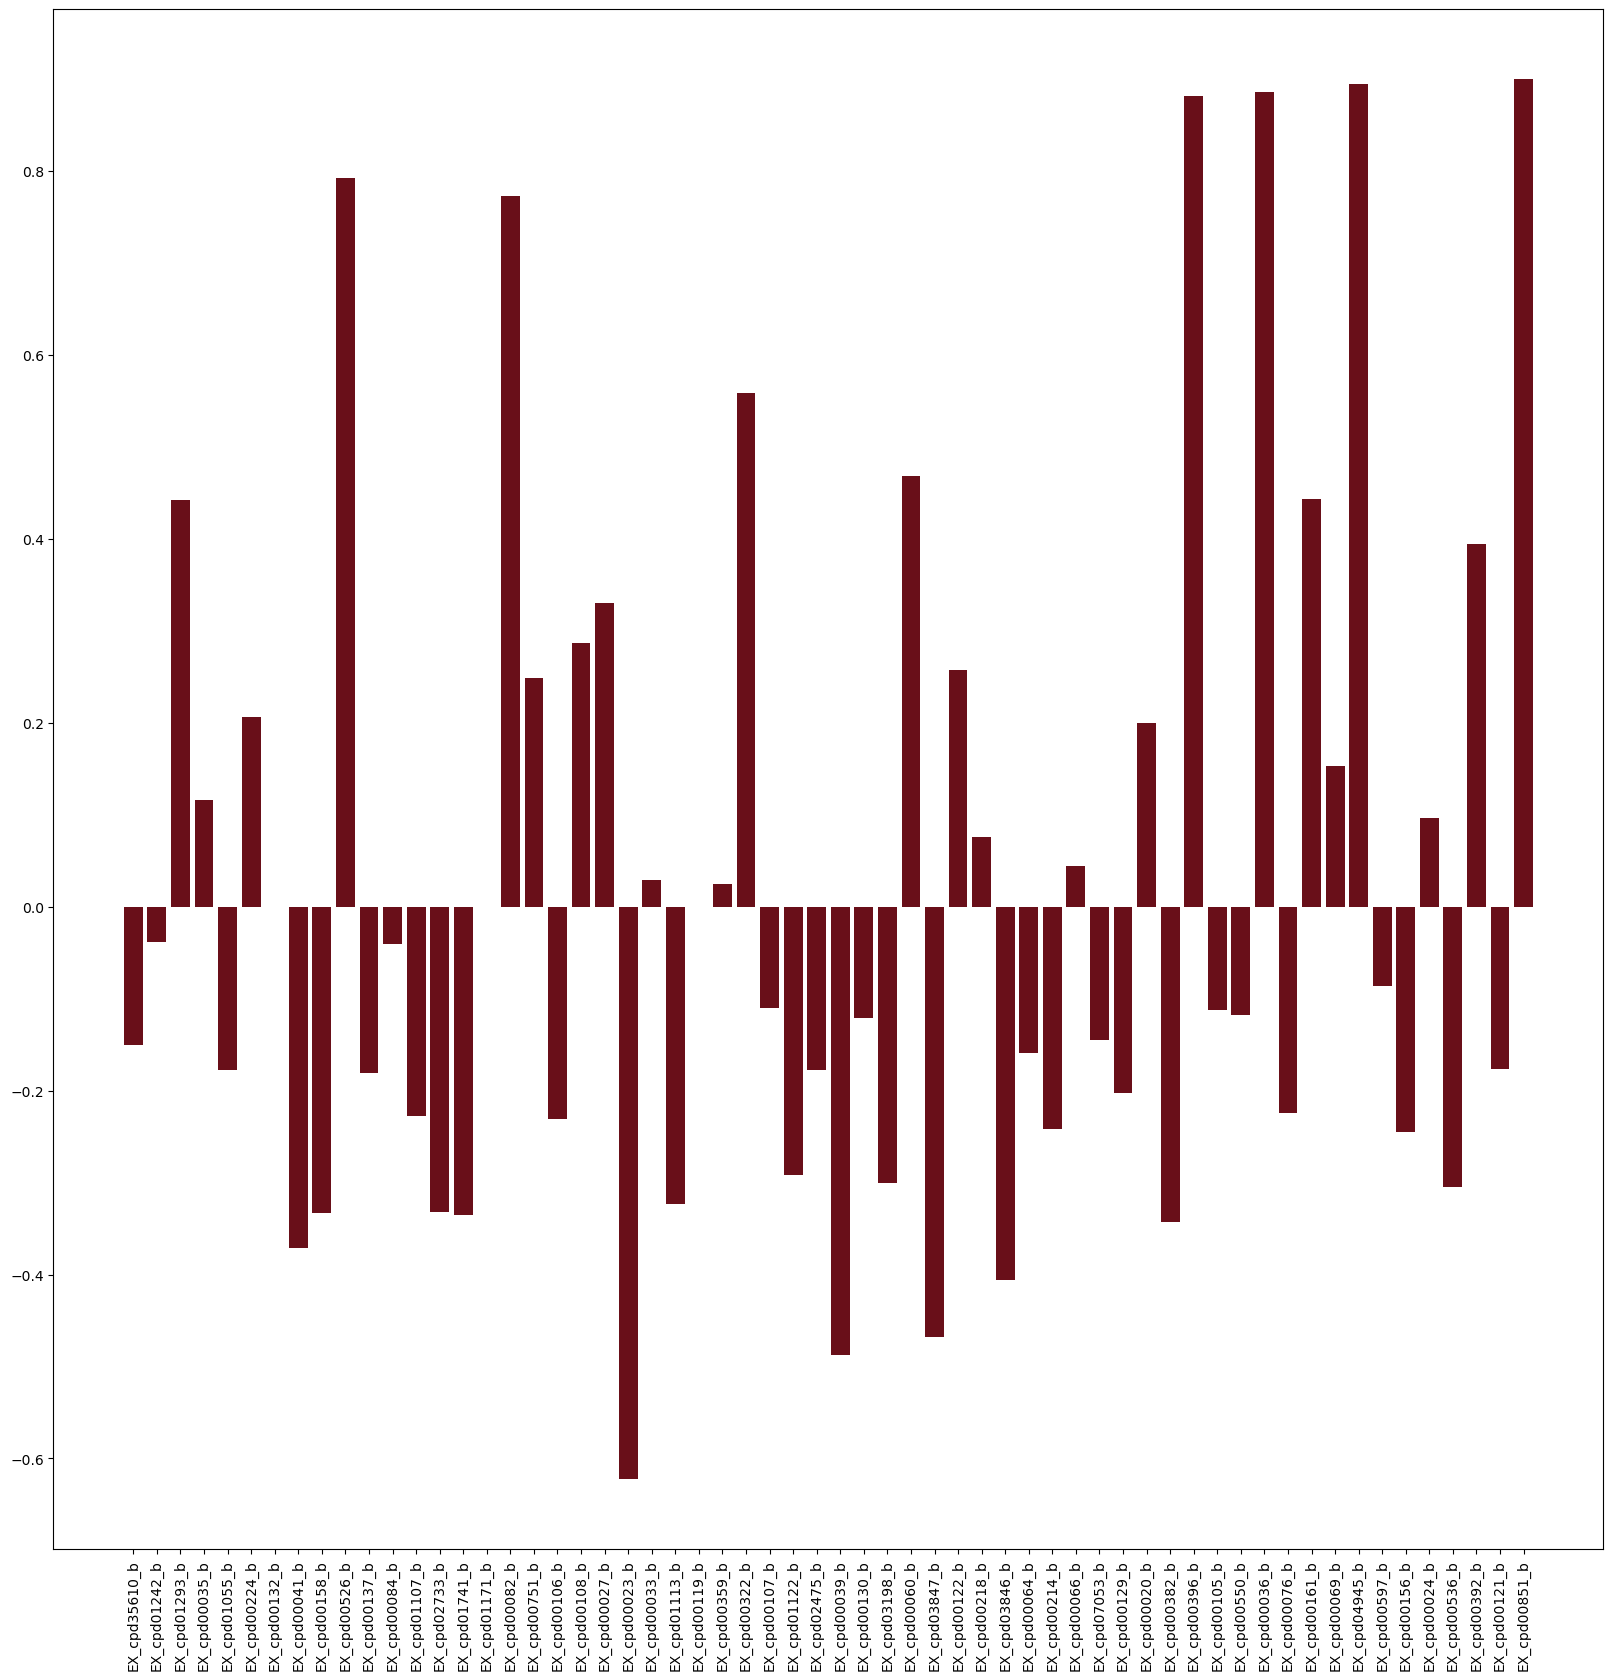

In [ ]:
fig, axes = plt.subplots(figsize=(20,20))
plt.bar(list(corr_dict.keys()), list(corr_dict.values()))
plt.xticks(rotation='vertical') 

In [ ]:
#fig, axes = plt.subplots(figsize=(20,20))
#plt.bar(list(rmse_dict.keys()), list(rmse_dict.values()))
#plt.xticks(rotation='vertical') 
#plt.yscale('log')

In [ ]:
### save rmse_dict 

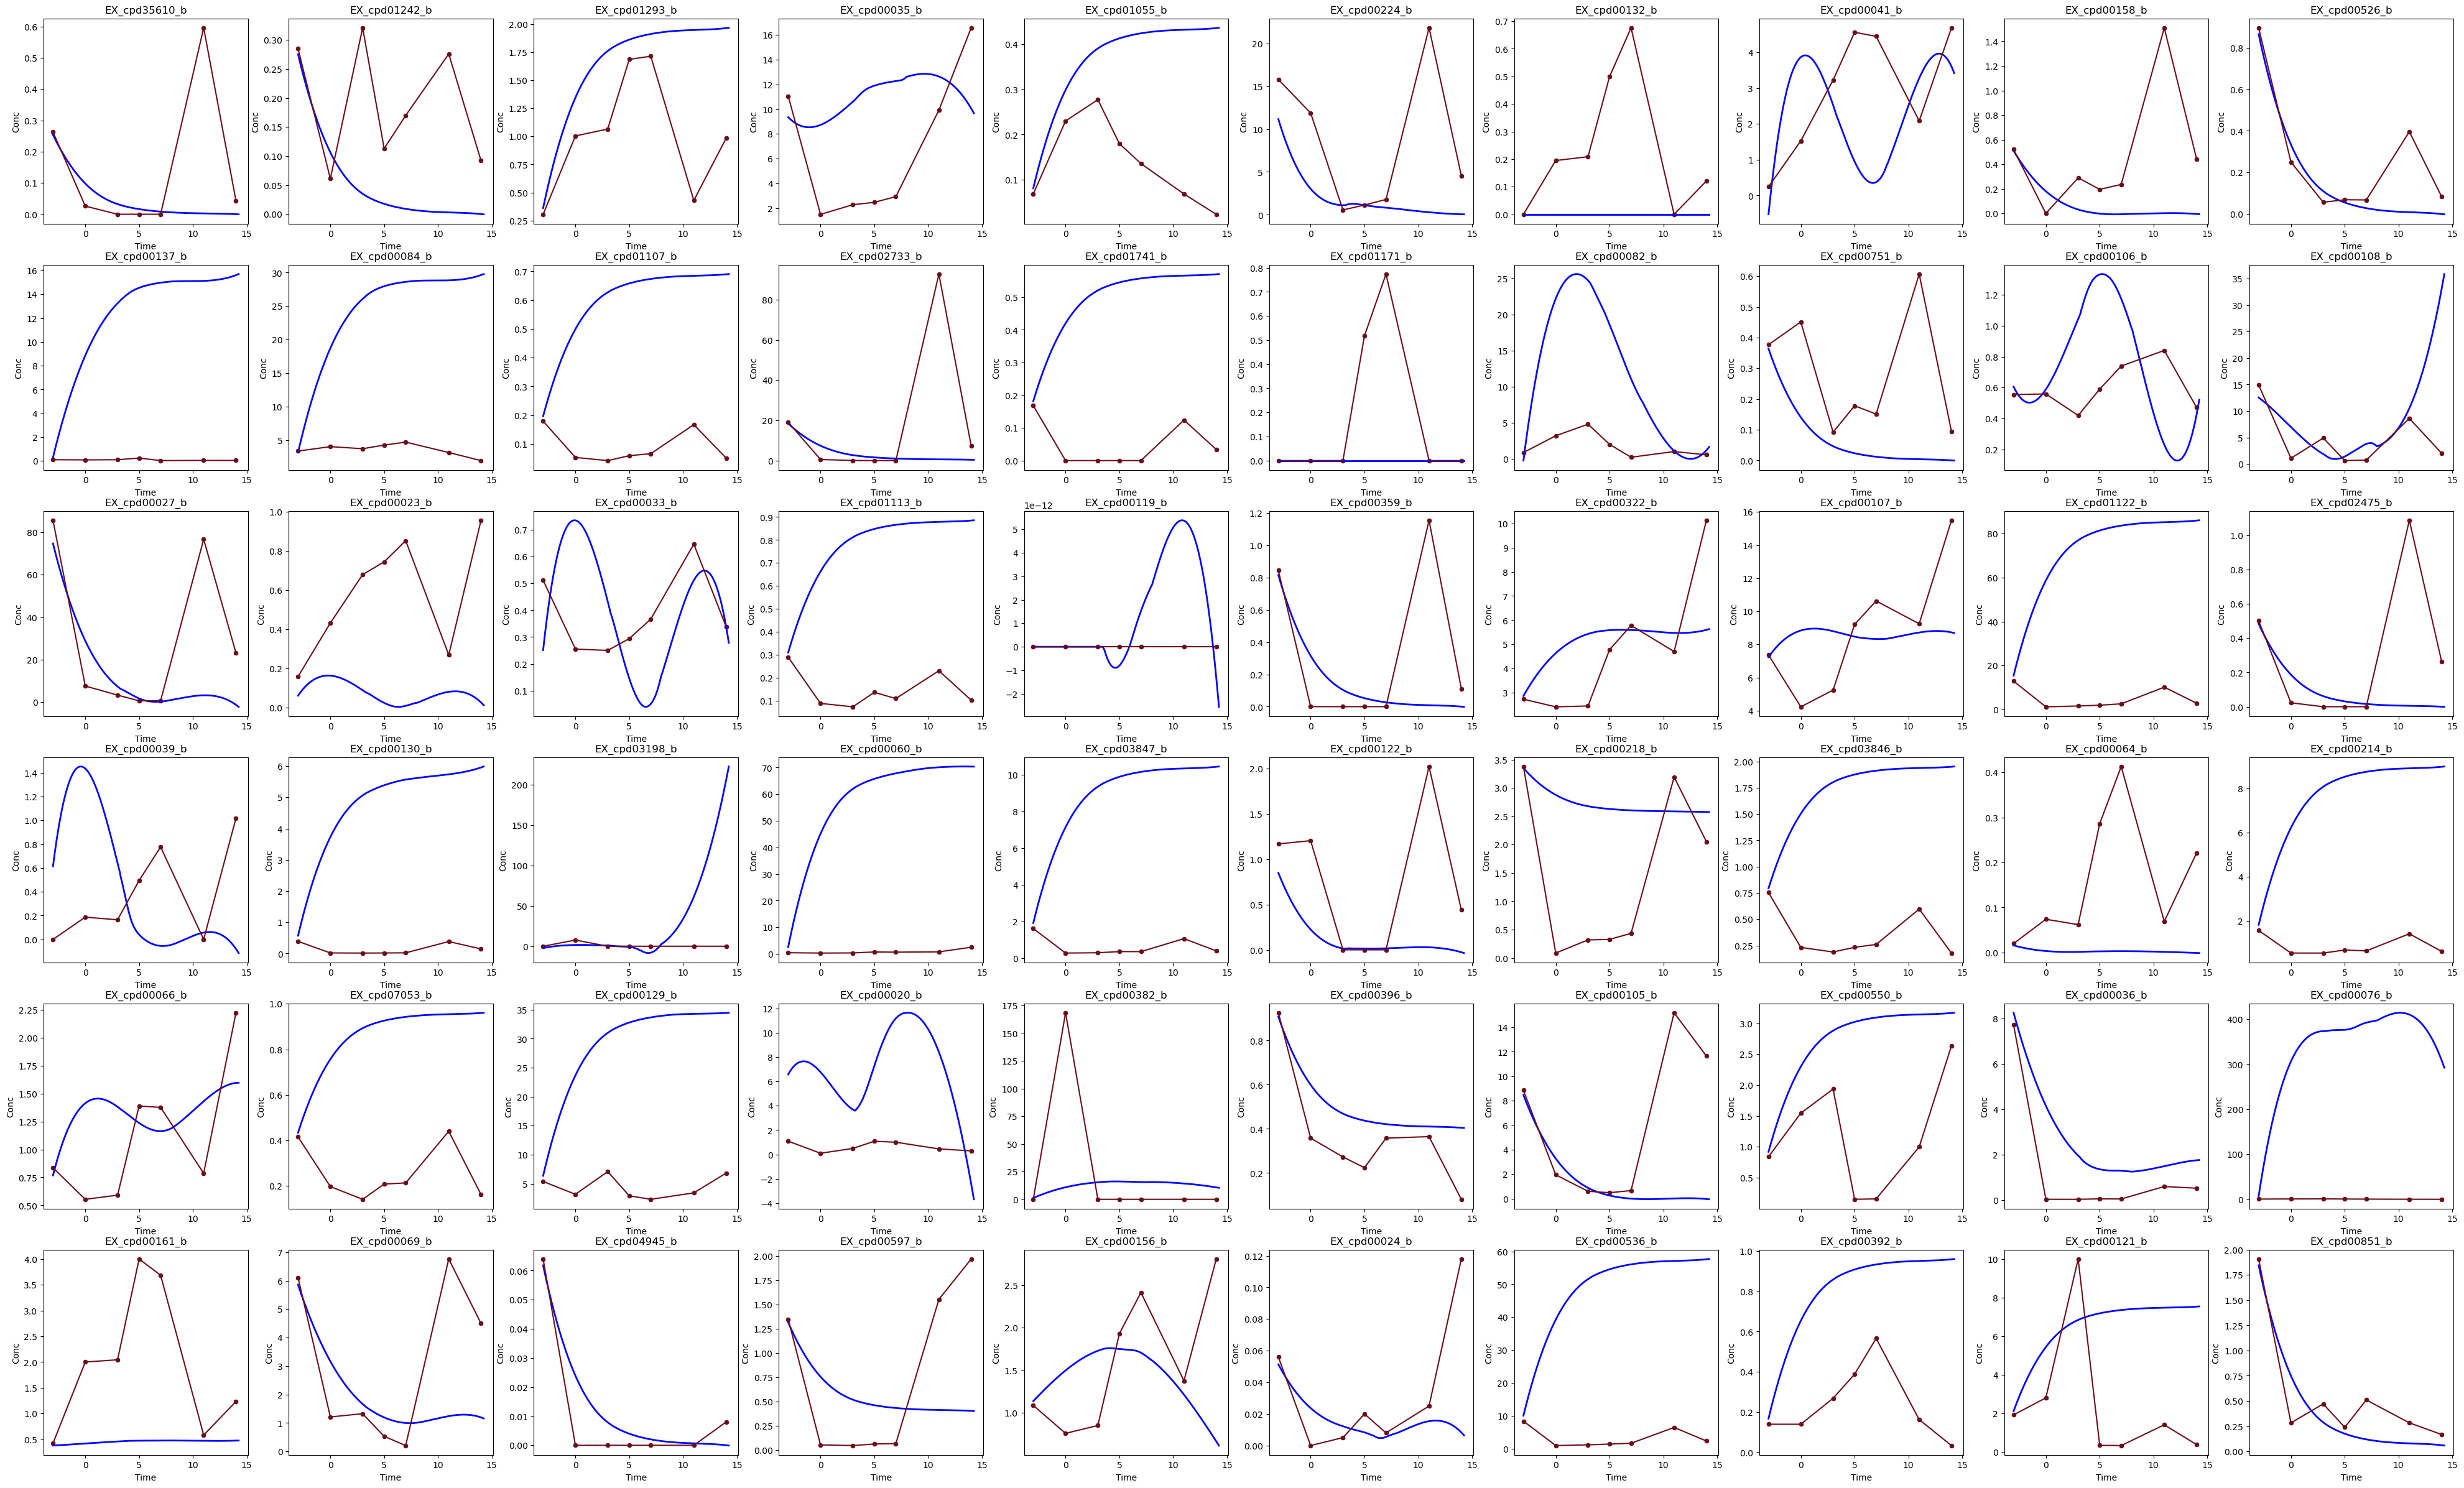

In [ ]:
from scipy.signal import savgol_filter
num_plots = 60
cols = 10  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i,met in enumerate(met_pool_over_time_df_filt.index.tolist()):
    temp_sim = met_pool_over_time_df_filt.loc[met,:]
    temp_exp = metabolomics_data_sub_1948.loc[met,:]
    temp_int = interpolated_met_values.loc[met,:]
        # Scatter plot on the respective subplot
    #sns.lineplot(ax=axes[i], x=temp_sim.index.to_list(), y=temp_sim.to_list(), color = 'red', lw = 2)
    sns.lineplot(ax = axes[i], x = temp_sim.index.to_list(), y = list(savgol_filter(temp_sim.to_list(),300,3)), color = 'blue', lw = 2)
    sns.scatterplot(ax=axes[i], x=temp_exp.index.to_list(), y=temp_exp.to_list())
    sns.lineplot(ax=axes[i], x=temp_exp.index.to_list(), y=temp_exp.to_list())
    #sns.lineplot(ax=axes[i], x=temp_int.index.to_list(), y=temp_int.to_list(), color = 'green')

    axes[i].set_title(f"{met}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Conc')
    #axes[i].set_yscale('log')
    #axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])


plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_individual_scatterplots_smoothed_predictions' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")

In [ ]:
metabolomics_data_sub_1948_melt = metabolomics_data_sub_1948.melt(ignore_index=False).reset_index()
metabolomics_data_sub_1948_melt.columns = ['metabolites', 'time', 'concentration']
metabolomics_data_sub_1948_melt.head()

,metabolites,time,concentration
0,EX_cpd35610_b,-3,0.263
1,EX_cpd01242_b,-3,0.285
2,EX_cpd01293_b,-3,0.305
3,EX_cpd00035_b,-3,11.053
4,EX_cpd01055_b,-3,0.069


In [ ]:
### Prepare the simulation metabolomic data 
met_pool_over_time_df_filt_melt = met_pool_over_time_df_filt.melt(ignore_index=False).reset_index()
met_pool_over_time_df_filt_melt.columns = ['metabolites', 'time', 'concentration']
met_pool_over_time_df_filt_melt.head()
# use this to filter, agora_ex_ids_list

,metabolites,time,concentration
0,EX_cpd35610_b,-3.0,0.263
1,EX_cpd01242_b,-3.0,0.285
2,EX_cpd01293_b,-3.0,0.305
3,EX_cpd00035_b,-3.0,11.053
4,EX_cpd01055_b,-3.0,0.069


In [ ]:
final_rounded_time_pt = met_pool_over_time_df_filt_melt['time'].max().round()


In [ ]:
met_pool_over_time_df_filt_melt.loc[
    met_pool_over_time_df_filt_melt['time'] == met_pool_over_time_df_filt_melt['time'].max(), 
    'time'
] = 14


In [ ]:
met_pool_over_time_df_filt_melt

,metabolites,time,concentration
0,EX_cpd35610_b,-3.0,0.263000
1,EX_cpd01242_b,-3.0,0.285000
2,EX_cpd01293_b,-3.0,0.305000
3,EX_cpd00035_b,-3.0,11.053000
4,EX_cpd01055_b,-3.0,0.069000
...,...,...,...
24895,EX_cpd00024_b,14.0,0.000000
24896,EX_cpd00536_b,14.0,57.479474
24897,EX_cpd00392_b,14.0,0.957490
24898,EX_cpd00121_b,14.0,7.512847


In [ ]:
### ok now make scatterplot for each time point 

metabolomics_data_sub_1948_melt['time'] = pd.to_numeric(metabolomics_data_sub_1948_melt['time'], downcast='float') 
merged_exp_sim_met_data = metabolomics_data_sub_1948_melt.merge(met_pool_over_time_df_filt_melt, on=['time', 'metabolites'])
merged_exp_sim_met_data.columns = ['metabolites', 'time', 'exp_conc', 'sim_conc']
#met_pool_over_time_df_filt_ra

In [ ]:
merged_exp_sim_met_data

,metabolites,time,exp_conc,sim_conc
0,EX_cpd35610_b,-3.0,0.263,0.263000
1,EX_cpd01242_b,-3.0,0.285,0.285000
2,EX_cpd01293_b,-3.0,0.305,0.305000
3,EX_cpd00035_b,-3.0,11.053,11.053000
4,EX_cpd01055_b,-3.0,0.069,0.069000
...,...,...,...,...
475,EX_cpd00392_b,14.0,0.033,0.957490
476,EX_cpd00121_b,14.0,0.380,7.511345
477,EX_cpd00121_b,14.0,0.380,7.512847
478,EX_cpd00851_b,14.0,0.167,0.066144


In [ ]:
x = y = np.linspace(0,25,50)

1.0
0.5858733455733912
0.5274414113870867
0.47063326000802047
0.36311516470021715
0.3135100991362511
0.29167520797433794


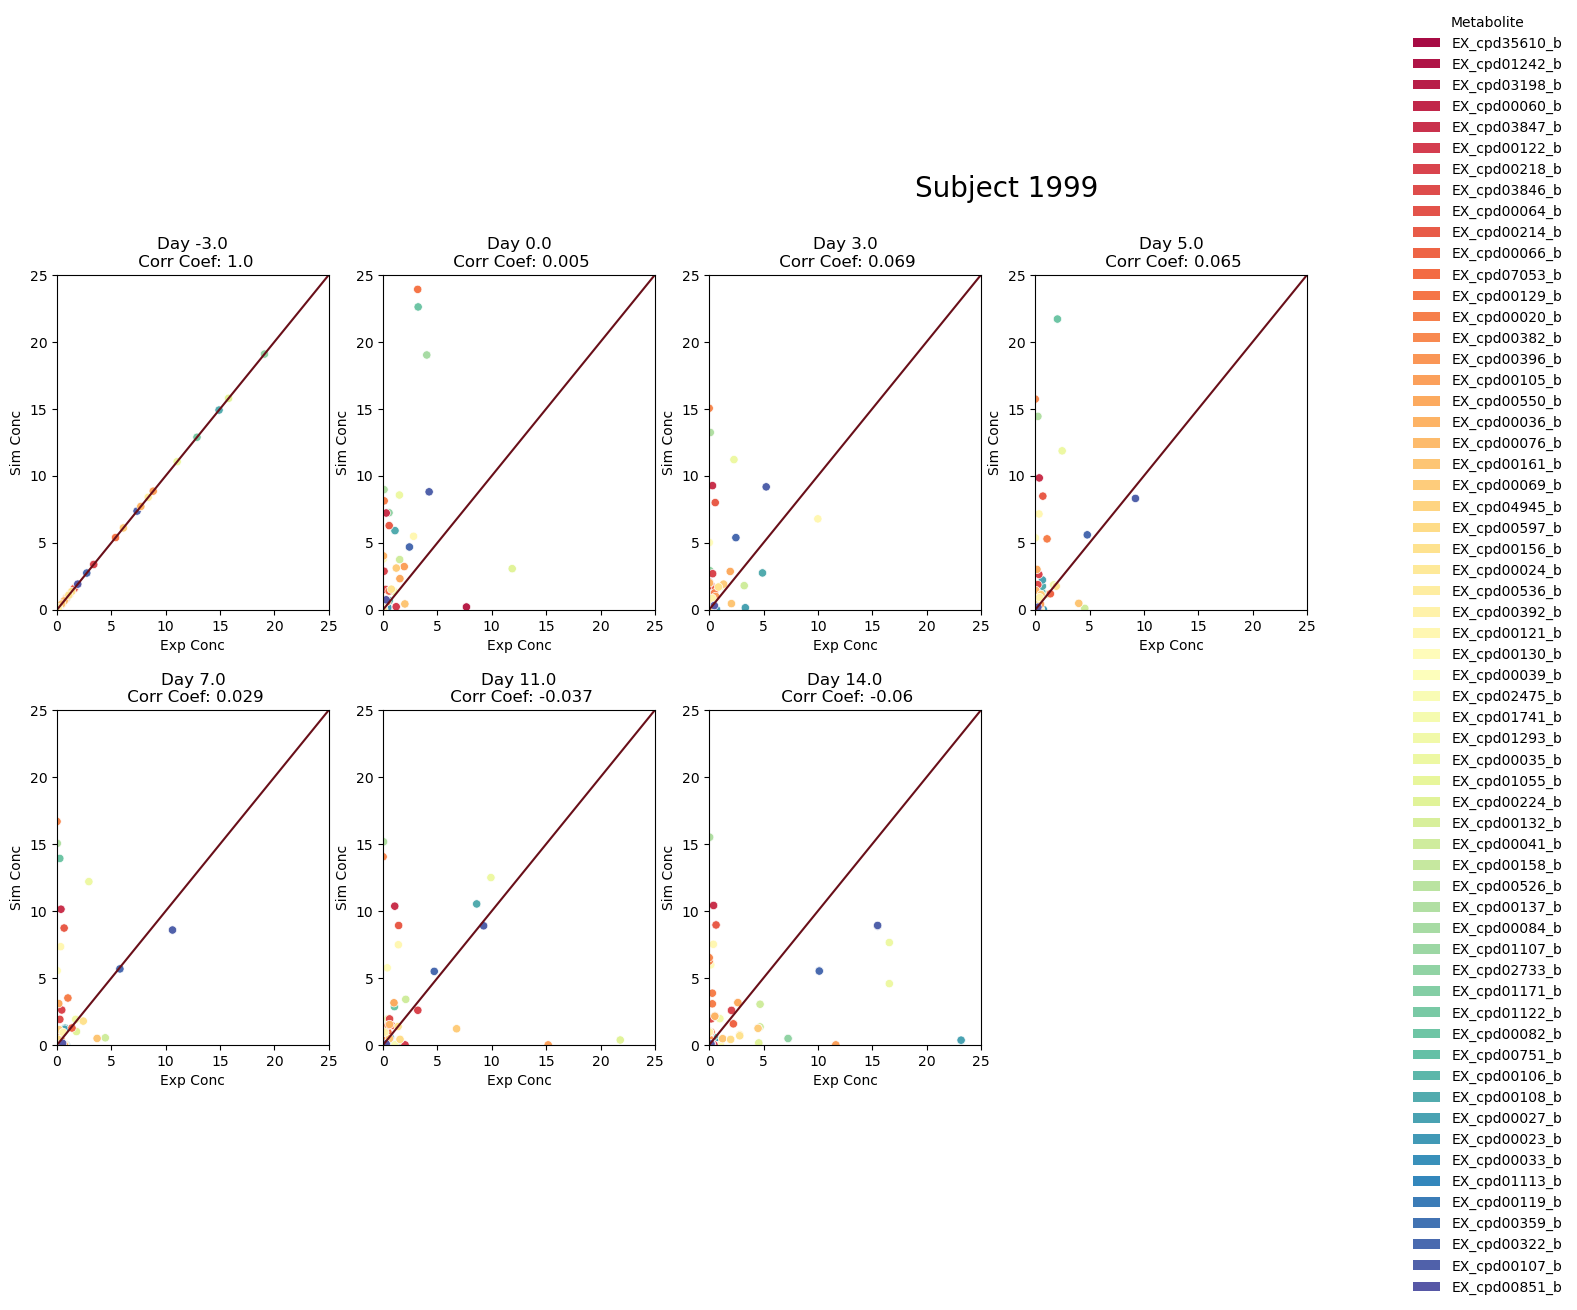

In [ ]:
from scipy.stats import pearsonr, spearmanr
num_plots = 7
cols = 4  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i,time in enumerate(merged_exp_sim_met_data['time'].unique().tolist()):
    temp = merged_exp_sim_met_data[merged_exp_sim_met_data['time'] == time]
    
        # Scatter plot on the respective subplot
    sns.scatterplot(ax=axes[i], data=temp, 
                    x=temp['exp_conc'], y=temp['sim_conc'], hue='metabolites', palette=color_map)
    temp_corr = np.round(np.corrcoef(temp['exp_conc'], temp['sim_conc'])[1,0],3)
    spearman = spearmanr(temp['exp_conc'], temp['sim_conc'])
    print(spearman.statistic)
    sns.lineplot(ax=axes[i], x=x, y = y)

    axes[i].set_xlim(0,25)
    axes[i].set_ylim(0,25)
    axes[i].set_title(f"Day {time}\n Corr Coef: {temp_corr}")
    axes[i].set_xlabel('Exp Conc')
    axes[i].set_ylabel('Sim Conc')
    axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Add custom legend to the *figure* (not either axis), outside plot
fig.legend(
    handles=legend_elements,
    title='Metabolite',
    loc='center left',
    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
    borderaxespad=0,
    frameon=False,
    ncol=1
)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=.3, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.6, fontsize = 20)
plt.subplots_adjust(right=0.75)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_scatter_exp_vs_sim_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

1.0
[[1. 1.]
 [1. 1.]]
[[1. 1.]
 [1. 1.]]
0.39086639035704784
[[1.         0.00489587]
 [0.00489587 1.        ]]
[[1.         0.39086639]
 [0.39086639 1.        ]]
0.4638856081116007
[[1.         0.06900372]
 [0.06900372 1.        ]]
[[1.         0.46388561]
 [0.46388561 1.        ]]
0.4186281205702701
[[1.        0.0647435]
 [0.0647435 1.       ]]
[[1.         0.41862812]
 [0.41862812 1.        ]]
0.35096894749713403
[[1.         0.02944673]
 [0.02944673 1.        ]]
[[1.         0.35096895]
 [0.35096895 1.        ]]
0.2065743583423138
[[ 1.         -0.03695628]
 [-0.03695628  1.        ]]
[[1.         0.20657436]
 [0.20657436 1.        ]]
0.1798893923851767
[[ 1.         -0.05998251]
 [-0.05998251  1.        ]]
[[1.         0.17988939]
 [0.17988939 1.        ]]


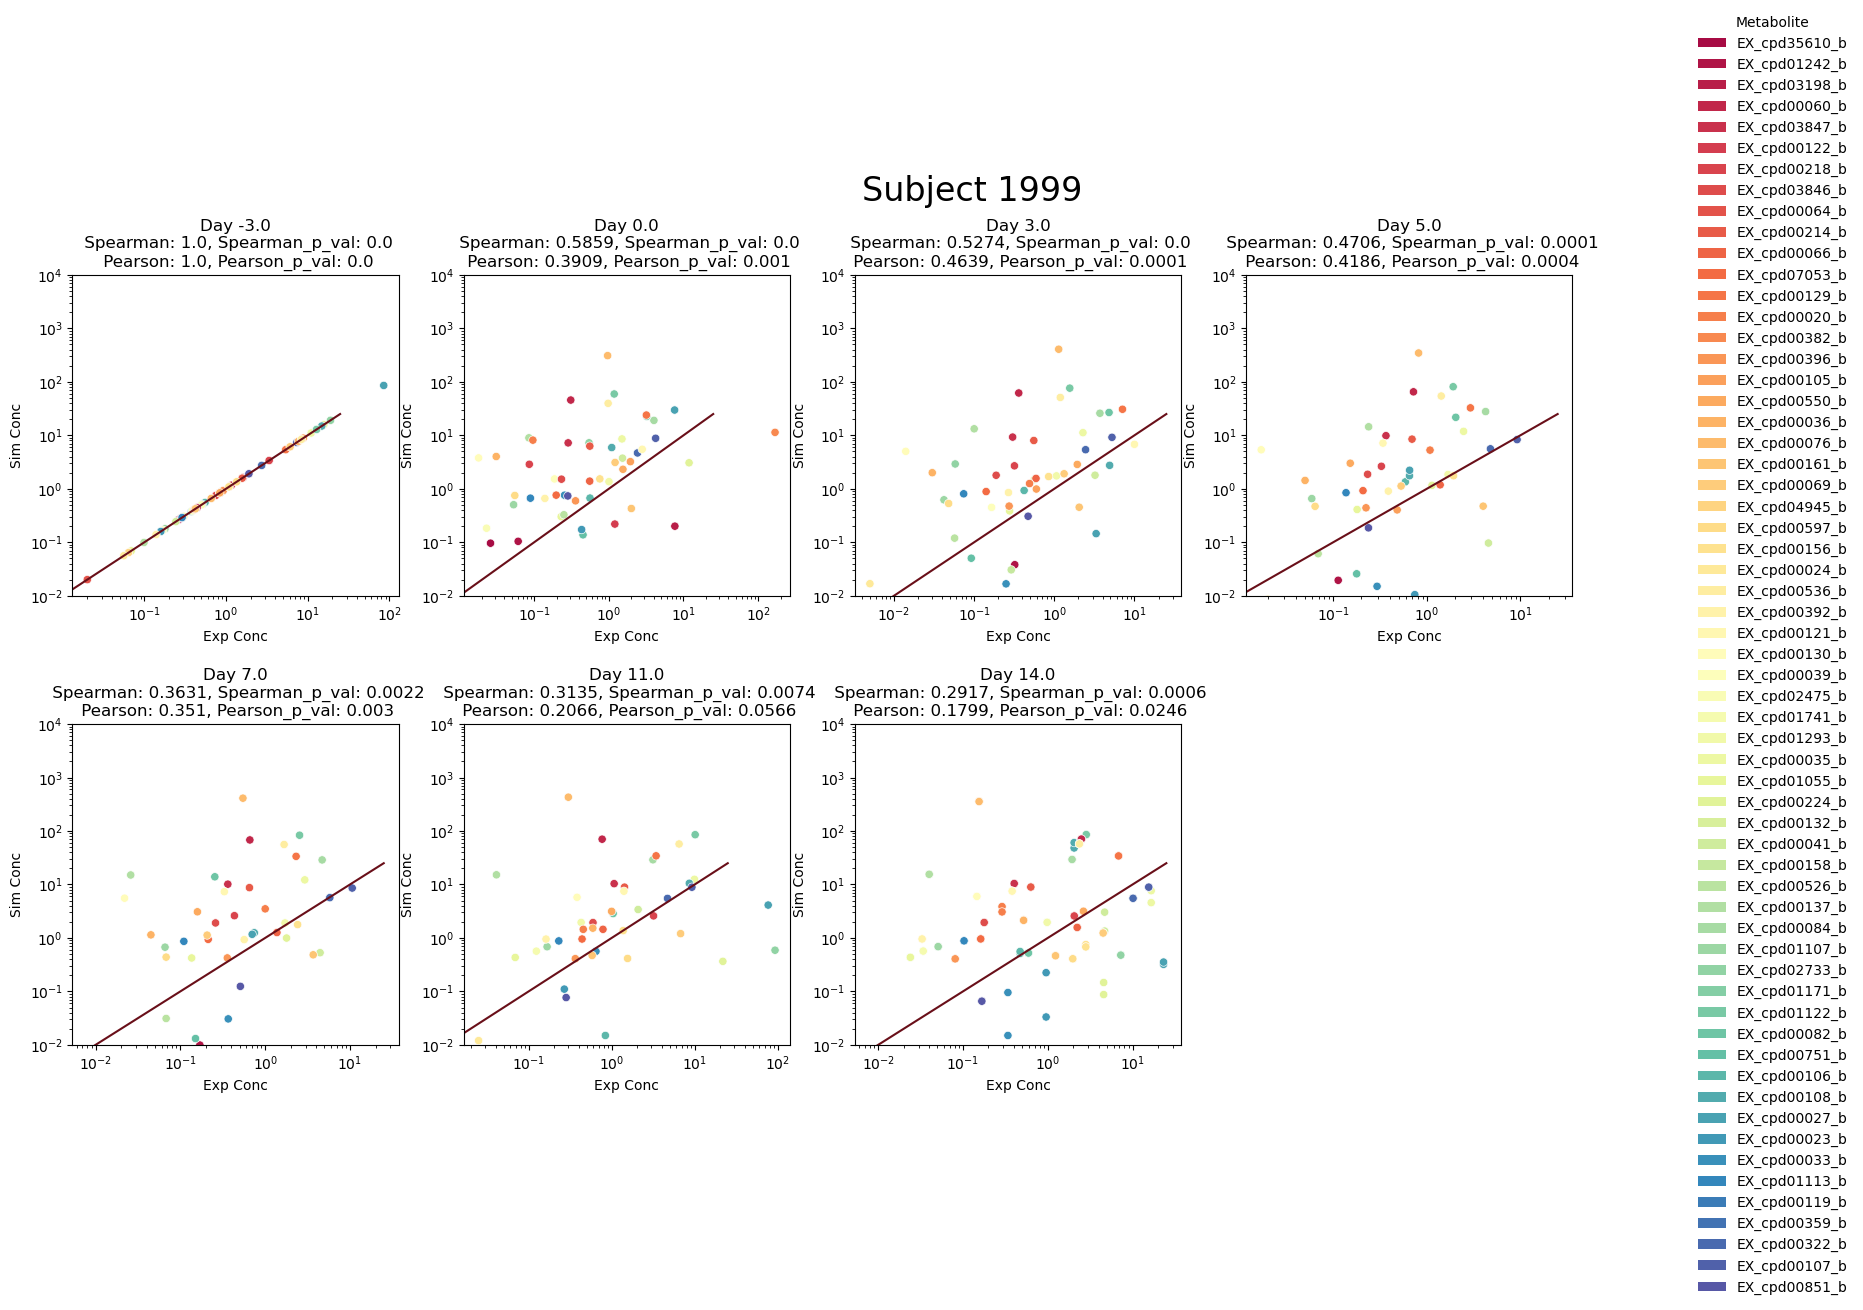

In [ ]:
num_plots = 7
cols = 4  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i,time in enumerate(merged_exp_sim_met_data['time'].unique().tolist()):
    temp = merged_exp_sim_met_data[merged_exp_sim_met_data['time'] == time]
    
        # Scatter plot on the respective subplot
    sns.scatterplot(ax=axes[i], data=temp, 
                    x=temp['exp_conc'], y=temp['sim_conc'], hue='metabolites', palette=color_map)

    sns.lineplot(ax=axes[i], x=x, y = y)
    temp_pearson = pearsonr(np.log1p(temp['exp_conc']), np.log1p(temp['sim_conc']), alternative='greater')
    print(temp_pearson.statistic)
    temp_corr = np.corrcoef(temp['exp_conc'], temp['sim_conc'])
    print(temp_corr)
    temp_corr_log = np.corrcoef(np.log1p(temp['exp_conc']), np.log1p(temp['sim_conc']))
    print(temp_corr_log)
    temp_spearman = spearmanr(np.log1p(temp['exp_conc']), np.log1p(temp['sim_conc']), alternative='greater')
    temp_spearman_stat_round = np.round(temp_spearman.statistic,4)
    temp_spearman_p_val_round = np.round(temp_spearman.pvalue,4)
    temp_pearson_stat_round = np.round(temp_pearson.statistic,4)
    temp_pearson_val_round = np.round(temp_pearson.pvalue,4)
    #axes[i].set_xlim(0,25)
    axes[i].set_ylim(10e-3,10e3)
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_title(f"Day {time}\n Spearman: {temp_spearman_stat_round}, Spearman_p_val: {temp_spearman_p_val_round}\n Pearson: {temp_pearson_stat_round}, Pearson_p_val: {temp_pearson_val_round}")
    axes[i].set_xlabel('Exp Conc')
    axes[i].set_ylabel('Sim Conc')
    axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Add custom legend to the *figure* (not either axis), outside plot
fig.legend(
    handles=legend_elements,
    title='Metabolite',
    loc='center left',
    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
    borderaxespad=0,
    frameon=False,
    ncol=1
)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=.4, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.5, fontsize = 24)
plt.subplots_adjust(right=0.75)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_scatter_exp_vs_sim_log_scale_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

In [ ]:
### Ok now look at the utilization and production of things by the bacteria themselves 

for key in model_abun_dict:
    temp_df = pd.DataFrame(model_abun_dict[key]['flux_up'])
    print(key)

14ac4eaad5b4e2ff3c071832e0fd4229
18673193aa6bf30c6a1e71ac504e04df
320dfd16200daaf2b0503975d4e68fd5
36173253c63ad49abc12361a0b3304eb
391821255f31ef94686927f4fba6fbc3
3936cc515320e9f29d81ffeaa92718e8
3e741fc097143bb6782af5233cb7af98
4cc9a4b9aaa3ee9a5c14cc27551a6844
795b6ba45f502a00b24b212278991c63
7ca7ca8214441730c2437d1f53390cdb
94e30534f622e456a683abe4e60fc214
9cf5cb71450a2aa080ff905f89b0a624
e3147edad1f84fae8bb6fd6f5e7a97b9
e8aae590cf49eb3c80ad7e08f2d3c3c4
eba523a4a554db4ad7e9dcff257bf1c8


In [ ]:
temp_1 = pd.DataFrame(model_abun_dict['14ac4eaad5b4e2ff3c071832e0fd4229']['flux_up']).fillna(0)
temp_2 = pd.DataFrame(model_abun_dict['4cc9a4b9aaa3ee9a5c14cc27551a6844']['flux_up']).fillna(0)


In [ ]:
temp_1.add(temp_2, fill_value=0)

,EX_cpd00001_b,EX_cpd00009_b,EX_cpd00011_b,EX_cpd00013_b,EX_cpd00020_b,EX_cpd00027_b,EX_cpd00028_b,EX_cpd00029_b,EX_cpd00030_b,EX_cpd00034_b,...,EX_cpd00309_b,EX_cpd00322_b,EX_cpd00382_b,EX_cpd00393_b,EX_cpd00731_b,EX_cpd01414_b,EX_cpd01981_b,EX_cpd10515_b,EX_cpd10516_b,EX_cpd15378_b
0,0.0,0.000000,0.0,0.000000,0.0,0.085063,0.000000e+00,0.0,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000,0.0
1,0.0,0.002155,0.0,0.005277,0.0,0.068957,1.225774e-05,0.0,0.000012,0.000012,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.0,0.000025,0.000012,0.0
2,0.0,0.001941,0.0,0.010838,0.0,0.081356,1.104386e-05,0.0,0.000011,0.000011,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.0,0.000022,0.000011,0.0
3,0.0,0.001684,0.0,0.016777,0.0,0.093663,9.580603e-06,0.0,0.000010,0.000010,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.0,0.000019,0.000010,0.0
4,0.0,0.001391,0.0,0.023273,0.0,0.105982,7.911783e-06,0.0,0.000008,0.000008,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.0,0.000016,0.000008,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,0.0,0.002933,0.0,0.017830,0.0,0.000000,1.668418e-05,0.0,0.000017,0.000017,...,1.350511e-22,1.112364e-10,0.021662,0.000000e+00,0.0,0.0,0.0,0.000033,0.000017,0.0
410,0.0,0.003059,0.0,0.018600,0.0,0.000000,1.739170e-05,0.0,0.000017,0.000017,...,1.715328e-22,1.641175e-10,0.022597,3.229904e-22,0.0,0.0,0.0,0.000035,0.000017,0.0
411,0.0,0.003189,0.0,0.019390,0.0,0.000000,1.814365e-05,0.0,0.000018,0.000018,...,8.281868e-23,2.468262e-10,0.023556,3.588470e-22,0.0,0.0,0.0,0.000036,0.000018,0.0
412,0.0,0.003322,0.0,0.020465,0.0,0.000000,9.463991e-12,0.0,0.000019,0.000019,...,0.000000e+00,3.787021e-10,0.024981,4.295828e-22,0.0,0.0,0.0,0.000057,0.000019,0.0


In [ ]:

flux_up_df = pd.DataFrame()

for key in model_abun_dict:
    temp_up = pd.DataFrame(model_abun_dict[key]['flux_up']).fillna(0)
    flux_up_df = flux_up_df.add(temp_up, fill_value=0)

flux_up_df

,EX_cpd00001_b,EX_cpd00007_b,EX_cpd00009_b,EX_cpd00011_b,EX_cpd00013_b,EX_cpd00020_b,EX_cpd00023_b,EX_cpd00024_b,EX_cpd00027_b,EX_cpd00028_b,...,EX_cpd08636_b,EX_cpd10515_b,EX_cpd10516_b,EX_cpd11580_b,EX_cpd11584_b,EX_cpd11593_b,EX_cpd11640_b,EX_cpd15378_b,EX_cpd15603_b,EX_cpd15606_b
0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.085063,0.000000,...,0.0,0.000000,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0
1,0.010968,0.0,0.022482,0.000000,0.018753,0.000000,0.011041,0.0,0.717415,0.000035,...,0.0,0.000314,0.000767,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0
2,0.034816,0.0,0.024889,0.000000,0.022469,0.000000,0.012209,0.0,0.801456,0.000125,...,0.0,0.000250,0.001220,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0
3,0.062147,0.0,0.026431,0.000000,0.024599,0.000000,0.011673,0.0,0.872964,0.000112,...,0.0,0.000270,0.001709,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0
4,0.092312,0.0,0.027964,0.005332,0.034724,0.000000,0.011931,0.0,0.939655,0.000115,...,0.0,0.000268,0.002268,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,1.399384,0.0,0.058300,0.010601,0.110590,0.309697,0.004968,0.0,0.077789,0.000236,...,0.0,0.000429,0.000364,4.380883e-26,0.0,0.0,0.0,0.0,0.0,0.0
410,1.516636,0.0,0.061724,0.010373,0.111920,0.403060,0.005417,0.0,0.080506,0.000252,...,0.0,0.000465,0.000389,4.496712e-26,0.0,0.0,0.0,0.0,0.0,0.0
411,1.469620,0.0,0.063440,0.009613,0.121399,0.370819,0.006374,0.0,0.064313,0.000257,...,0.0,0.000482,0.000404,4.618689e-26,0.0,0.0,0.0,0.0,0.0,0.0
412,1.618074,0.0,0.066330,0.009193,0.124034,0.400786,0.006969,0.0,0.066272,0.000249,...,0.0,0.000534,0.000426,4.747077e-26,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
flux_sec_df = pd.DataFrame()

for key in model_abun_dict:
    temp_sec = pd.DataFrame(model_abun_dict[key]['flux_sec']).fillna(0)
    flux_sec_df = flux_sec_df.add(temp_sec, fill_value=0)

flux_sec_df.columns

Index(['EX_cpd00001_b', 'EX_cpd00009_b', 'EX_cpd00011_b', 'EX_cpd00012_b',
       'EX_cpd00013_b', 'EX_cpd00020_b', 'EX_cpd00023_b', 'EX_cpd00024_b',
       'EX_cpd00027_b', 'EX_cpd00028_b', 'EX_cpd00029_b', 'EX_cpd00033_b',
       'EX_cpd00035_b', 'EX_cpd00036_b', 'EX_cpd00039_b', 'EX_cpd00041_b',
       'EX_cpd00047_b', 'EX_cpd00048_b', 'EX_cpd00051_b', 'EX_cpd00054_b',
       'EX_cpd00060_b', 'EX_cpd00064_b', 'EX_cpd00065_b', 'EX_cpd00066_b',
       'EX_cpd00067_b', 'EX_cpd00071_b', 'EX_cpd00076_b', 'EX_cpd00080_b',
       'EX_cpd00081_b', 'EX_cpd00082_b', 'EX_cpd00084_b', 'EX_cpd00092_b',
       'EX_cpd00100_b', 'EX_cpd00104_b', 'EX_cpd00106_b', 'EX_cpd00107_b',
       'EX_cpd00108_b', 'EX_cpd00116_b', 'EX_cpd00117_b', 'EX_cpd00119_b',
       'EX_cpd00122_b', 'EX_cpd00128_b', 'EX_cpd00129_b', 'EX_cpd00130_b',
       'EX_cpd00137_b', 'EX_cpd00138_b', 'EX_cpd00139_b', 'EX_cpd00161_b',
       'EX_cpd00180_b', 'EX_cpd00182_b', 'EX_cpd00184_b', 'EX_cpd00214_b',
       'EX_cpd00218_b', '

In [ ]:
### filter dataframes by metabolites of interest 

flux_up_df_filt = flux_up_df[flux_up_df.columns.intersection(change_met_ids)]
flux_up_df_filt

flux_sec_df_filt = flux_sec_df[flux_sec_df.columns.intersection(change_met_ids)]
flux_sec_df_filt

,EX_cpd00020_b,EX_cpd00023_b,EX_cpd00024_b,EX_cpd00027_b,EX_cpd00033_b,EX_cpd00035_b,EX_cpd00036_b,EX_cpd00039_b,EX_cpd00041_b,EX_cpd00060_b,...,EX_cpd00119_b,EX_cpd00122_b,EX_cpd00129_b,EX_cpd00130_b,EX_cpd00137_b,EX_cpd00161_b,EX_cpd00214_b,EX_cpd00218_b,EX_cpd00224_b,EX_cpd03198_b
0,0.000000,0.000000,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.000000
1,-0.019822,0.000000,0.0,0.0,0.0,0.000000e+00,-0.019632,-0.000343,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.000000
2,-0.035591,0.000000,0.0,0.0,0.0,0.000000e+00,-0.039248,-0.000715,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.000000
3,-0.053262,0.000000,0.0,0.0,0.0,0.000000e+00,-0.061839,-0.001110,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.000000
4,-0.073313,0.000000,0.0,0.0,0.0,0.000000e+00,-0.090585,-0.001649,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,-0.210014,-0.015748,0.0,0.0,0.0,-1.497480e-22,-0.008621,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,-8.227540e-17,0.0,0.0,0.0,-0.217108
410,-0.212286,-0.016373,0.0,0.0,0.0,-1.266307e-22,-0.007939,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,-1.786115e-16,0.0,0.0,0.0,-0.199939
411,-0.213808,-0.017000,0.0,0.0,0.0,0.000000e+00,-0.007277,0.000000,0.0,0.0,...,0.0,0.0,0.0,-0.000118,0.0,-1.268735e-16,0.0,0.0,0.0,-0.183263
412,-0.212227,-0.017626,0.0,0.0,0.0,0.000000e+00,-0.006638,0.000000,0.0,0.0,...,0.0,0.0,0.0,-0.000124,0.0,-5.713699e-17,0.0,0.0,0.0,-0.167167


In [ ]:
### Ok now here filter the initial metabolite conditions by the columns but then add them to the time zero and cumsum after that 


### need to multiply the uptake and secretion dataframes by -1 because opposite of how we would think of these things currently

flux_sec_df_filt = flux_sec_df_filt*-1.0
flux_up_df_filt = flux_up_df_filt*-1.0

In [ ]:
# Merge with suffixes to distinguish common columns
merged_bac_met_use_df = flux_sec_df_filt.merge(flux_up_df_filt, how='outer', left_index=True, right_index=True)
merged_bac_met_use_df

,EX_cpd00020_b_x,EX_cpd00023_b_x,EX_cpd00024_b_x,EX_cpd00027_b_x,EX_cpd00033_b_x,EX_cpd00035_b_x,EX_cpd00036_b_x,EX_cpd00039_b_x,EX_cpd00041_b_x,EX_cpd00060_b_x,...,EX_cpd00137_b_y,EX_cpd00156_b,EX_cpd00158_b,EX_cpd00161_b_y,EX_cpd00214_b_y,EX_cpd00218_b_y,EX_cpd00224_b_y,EX_cpd00322_b,EX_cpd00382_b,EX_cpd03198_b_y
0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.000000e+00,-0.000000,-0.000000,-0.0,-0.0,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.399831,-0.000000,-0.000000,-0.0
1,0.019822,-0.000000,-0.0,-0.0,-0.0,-0.000000e+00,0.019632,0.000343,-0.0,-0.0,...,-0.001265,-0.000546,-0.000927,-0.000774,-0.0,-0.000050,-0.384580,-0.001038,-0.000000,-0.0
2,0.035591,-0.000000,-0.0,-0.0,-0.0,-0.000000e+00,0.039248,0.000715,-0.0,-0.0,...,-0.002165,-0.001560,-0.000623,-0.001525,-0.0,-0.000043,-0.396828,-0.000186,-0.000000,-0.0
3,0.053262,-0.000000,-0.0,-0.0,-0.0,-0.000000e+00,0.061839,0.001110,-0.0,-0.0,...,-0.003149,-0.001693,-0.000317,-0.002388,-0.0,-0.000036,-0.404268,-0.000171,-0.000000,-0.0
4,0.073313,-0.000000,-0.0,-0.0,-0.0,-0.000000e+00,0.090585,0.001649,-0.0,-0.0,...,-0.004277,-0.002439,-0.000017,-0.003454,-0.0,-0.000027,-0.406841,-0.000157,-0.000000,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,0.210014,0.015748,-0.0,-0.0,-0.0,1.497480e-22,0.008621,-0.000000,-0.0,-0.0,...,-0.000007,-0.014391,-0.000000,-0.000463,-0.0,-0.000211,-0.000000,-0.004745,-0.021662,-0.0
410,0.212286,0.016373,-0.0,-0.0,-0.0,1.266307e-22,0.007939,-0.000000,-0.0,-0.0,...,-0.000007,-0.015228,-0.000000,-0.000466,-0.0,-0.000231,-0.000000,-0.005155,-0.022597,-0.0
411,0.213808,0.017000,-0.0,-0.0,-0.0,-0.000000e+00,0.007277,-0.000000,-0.0,-0.0,...,-0.000007,-0.013867,-0.000000,-0.000467,-0.0,-0.000231,-0.000000,-0.005154,-0.023557,-0.0
412,0.212227,0.017626,-0.0,-0.0,-0.0,-0.000000e+00,0.006638,-0.000000,-0.0,-0.0,...,-0.000007,-0.014442,-0.000000,-0.000467,-0.0,-0.000243,-0.000000,-0.005393,-0.024981,-0.0


In [ ]:
### Ok now need to figure out how to add the correct columns together into a new column and then drop any columns with _x or _y

for column in merged_bac_met_use_df.columns:
    if column.endswith(('_x')):
        temp_col = column.split('_')
        #print(temp_col)
        temp_col = temp_col[0] + '_' + temp_col[1] + '_' +temp_col[2] + '_y'
        #print(temp_col)
        merged_bac_met_use_df.loc[:,column] = merged_bac_met_use_df.loc[:,column] + merged_bac_met_use_df.loc[:,temp_col]
    else:
        continue
merged_bac_met_use_df

,EX_cpd00020_b_x,EX_cpd00023_b_x,EX_cpd00024_b_x,EX_cpd00027_b_x,EX_cpd00033_b_x,EX_cpd00035_b_x,EX_cpd00036_b_x,EX_cpd00039_b_x,EX_cpd00041_b_x,EX_cpd00060_b_x,...,EX_cpd00137_b_y,EX_cpd00156_b,EX_cpd00158_b,EX_cpd00161_b_y,EX_cpd00214_b_y,EX_cpd00218_b_y,EX_cpd00224_b_y,EX_cpd00322_b,EX_cpd00382_b,EX_cpd03198_b_y
0,-0.000000,-0.000000,-0.0,-0.085063,-0.000000,-0.000000,-0.000000,-0.000000e+00,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.399831,-0.000000,-0.000000,-0.0
1,0.019822,-0.011041,-0.0,-0.717415,-0.031236,-0.005915,0.019632,3.434799e-04,-0.024463,-0.005271,...,-0.001265,-0.000546,-0.000927,-0.000774,-0.0,-0.000050,-0.384580,-0.001038,-0.000000,-0.0
2,0.035591,-0.012209,-0.0,-0.801456,-0.028903,-0.001409,0.039248,7.143148e-04,-0.032268,-0.005503,...,-0.002165,-0.001560,-0.000623,-0.001525,-0.0,-0.000043,-0.396828,-0.000186,-0.000000,-0.0
3,0.053262,-0.011673,-0.0,-0.872964,-0.028241,-0.001268,0.061839,1.109279e-03,-0.036242,-0.005868,...,-0.003149,-0.001693,-0.000317,-0.002388,-0.0,-0.000036,-0.404268,-0.000171,-0.000000,-0.0
4,0.073313,-0.011931,-0.0,-0.939655,-0.028575,-0.001114,0.090585,1.648562e-03,-0.036282,-0.006024,...,-0.004277,-0.002439,-0.000017,-0.003454,-0.0,-0.000027,-0.406841,-0.000157,-0.000000,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,-0.099683,0.010780,-0.0,-0.077789,-0.028239,-0.443294,0.008618,-3.954162e-13,-0.125096,-0.003082,...,-0.000007,-0.014391,-0.000000,-0.000463,-0.0,-0.000211,-0.000000,-0.004745,-0.021662,-0.0
410,-0.190774,0.010956,-0.0,-0.080506,-0.029821,-0.475034,0.007936,-5.311687e-13,-0.132099,-0.003379,...,-0.000007,-0.015228,-0.000000,-0.000466,-0.0,-0.000231,-0.000000,-0.005155,-0.022597,-0.0
411,-0.157011,0.010626,-0.0,-0.064313,-0.006089,-0.434489,0.007274,-7.292881e-13,-0.158803,-0.003446,...,-0.000007,-0.013867,-0.000000,-0.000467,-0.0,-0.000231,-0.000000,-0.005154,-0.023557,-0.0
412,-0.188560,0.010657,-0.0,-0.066272,-0.008512,-0.453487,0.006634,-1.023926e-12,-0.166033,-0.003701,...,-0.000007,-0.014442,-0.000000,-0.000467,-0.0,-0.000243,-0.000000,-0.005393,-0.024981,-0.0


In [ ]:
### Ok now take columns, drop the _y columns and then 
# Drop all columns ending with '_y'
merged_bac_met_use_df = merged_bac_met_use_df.drop(columns=[col for col in merged_bac_met_use_df.columns if col.endswith('_y')])

# Rename columns ending with '_x' by removing the '_x' suffix
merged_bac_met_use_df.columns = [col.replace('_x', '') if col.endswith('_x') else col for col in merged_bac_met_use_df.columns]

merged_bac_met_use_df

,EX_cpd00020_b,EX_cpd00023_b,EX_cpd00024_b,EX_cpd00027_b,EX_cpd00033_b,EX_cpd00035_b,EX_cpd00036_b,EX_cpd00039_b,EX_cpd00041_b,EX_cpd00060_b,...,EX_cpd00214_b,EX_cpd00218_b,EX_cpd00224_b,EX_cpd03198_b,EX_cpd00069_b,EX_cpd00105_b,EX_cpd00156_b,EX_cpd00158_b,EX_cpd00322_b,EX_cpd00382_b
0,-0.000000,-0.000000,-0.0,-0.085063,-0.000000,-0.000000,-0.000000,-0.000000e+00,-0.000000,-0.000000,...,-0.0,-0.000000,-0.399831,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
1,0.019822,-0.011041,-0.0,-0.717415,-0.031236,-0.005915,0.019632,3.434799e-04,-0.024463,-0.005271,...,-0.0,-0.000050,-0.384580,-0.000000,-0.001640,-0.021789,-0.000546,-0.000927,-0.001038,-0.000000
2,0.035591,-0.012209,-0.0,-0.801456,-0.028903,-0.001409,0.039248,7.143148e-04,-0.032268,-0.005503,...,-0.0,-0.000043,-0.396828,-0.000000,-0.001800,-0.014643,-0.001560,-0.000623,-0.000186,-0.000000
3,0.053262,-0.011673,-0.0,-0.872964,-0.028241,-0.001268,0.061839,1.109279e-03,-0.036242,-0.005868,...,-0.0,-0.000036,-0.404268,-0.000000,-0.001855,-0.007455,-0.001693,-0.000317,-0.000171,-0.000000
4,0.073313,-0.011931,-0.0,-0.939655,-0.028575,-0.001114,0.090585,1.648562e-03,-0.036282,-0.006024,...,-0.0,-0.000027,-0.406841,-0.000000,-0.001868,-0.000388,-0.002439,-0.000017,-0.000157,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,-0.099683,0.010780,-0.0,-0.077789,-0.028239,-0.443294,0.008618,-3.954162e-13,-0.125096,-0.003082,...,-0.0,-0.000211,-0.000000,0.217108,-0.001296,-0.000000,-0.014391,-0.000000,-0.004745,-0.021662
410,-0.190774,0.010956,-0.0,-0.080506,-0.029821,-0.475034,0.007936,-5.311687e-13,-0.132099,-0.003379,...,-0.0,-0.000231,-0.000000,0.199939,-0.001409,-0.000000,-0.015228,-0.000000,-0.005155,-0.022597
411,-0.157011,0.010626,-0.0,-0.064313,-0.006089,-0.434489,0.007274,-7.292881e-13,-0.158803,-0.003446,...,-0.0,-0.000231,-0.000000,0.183263,-0.001537,-0.000000,-0.013867,-0.000000,-0.005154,-0.023557
412,-0.188560,0.010657,-0.0,-0.066272,-0.008512,-0.453487,0.006634,-1.023926e-12,-0.166033,-0.003701,...,-0.0,-0.000243,-0.000000,0.167167,-0.001683,-0.000000,-0.014442,-0.000000,-0.005393,-0.024981


In [ ]:
for i in merged_bac_met_use_df.columns:
    if i in metabolomics_data_initial_sub_1948['reaction'].to_list():
        merged_bac_met_use_df.loc[0,i] = metabolomics_data_initial_sub_1948[metabolomics_data_initial_sub_1948['reaction'] == i]['fluxValue'].iloc[0]
    else:
        continue

merged_bac_met_use_df

,EX_cpd00020_b,EX_cpd00023_b,EX_cpd00024_b,EX_cpd00027_b,EX_cpd00033_b,EX_cpd00035_b,EX_cpd00036_b,EX_cpd00039_b,EX_cpd00041_b,EX_cpd00060_b,...,EX_cpd00214_b,EX_cpd00218_b,EX_cpd00224_b,EX_cpd03198_b,EX_cpd00069_b,EX_cpd00105_b,EX_cpd00156_b,EX_cpd00158_b,EX_cpd00322_b,EX_cpd00382_b
0,1.089000,0.159000,0.056,85.571000,0.512000,11.053000,7.710000,0.000000e+00,0.243000,0.442000,...,1.576,3.379000,15.784000,0.000000,6.104000,8.850000,1.086000,0.520000,2.736000,0.000000
1,0.019822,-0.011041,-0.000,-0.717415,-0.031236,-0.005915,0.019632,3.434799e-04,-0.024463,-0.005271,...,-0.000,-0.000050,-0.384580,-0.000000,-0.001640,-0.021789,-0.000546,-0.000927,-0.001038,-0.000000
2,0.035591,-0.012209,-0.000,-0.801456,-0.028903,-0.001409,0.039248,7.143148e-04,-0.032268,-0.005503,...,-0.000,-0.000043,-0.396828,-0.000000,-0.001800,-0.014643,-0.001560,-0.000623,-0.000186,-0.000000
3,0.053262,-0.011673,-0.000,-0.872964,-0.028241,-0.001268,0.061839,1.109279e-03,-0.036242,-0.005868,...,-0.000,-0.000036,-0.404268,-0.000000,-0.001855,-0.007455,-0.001693,-0.000317,-0.000171,-0.000000
4,0.073313,-0.011931,-0.000,-0.939655,-0.028575,-0.001114,0.090585,1.648562e-03,-0.036282,-0.006024,...,-0.000,-0.000027,-0.406841,-0.000000,-0.001868,-0.000388,-0.002439,-0.000017,-0.000157,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,-0.099683,0.010780,-0.000,-0.077789,-0.028239,-0.443294,0.008618,-3.954162e-13,-0.125096,-0.003082,...,-0.000,-0.000211,-0.000000,0.217108,-0.001296,-0.000000,-0.014391,-0.000000,-0.004745,-0.021662
410,-0.190774,0.010956,-0.000,-0.080506,-0.029821,-0.475034,0.007936,-5.311687e-13,-0.132099,-0.003379,...,-0.000,-0.000231,-0.000000,0.199939,-0.001409,-0.000000,-0.015228,-0.000000,-0.005155,-0.022597
411,-0.157011,0.010626,-0.000,-0.064313,-0.006089,-0.434489,0.007274,-7.292881e-13,-0.158803,-0.003446,...,-0.000,-0.000231,-0.000000,0.183263,-0.001537,-0.000000,-0.013867,-0.000000,-0.005154,-0.023557
412,-0.188560,0.010657,-0.000,-0.066272,-0.008512,-0.453487,0.006634,-1.023926e-12,-0.166033,-0.003701,...,-0.000,-0.000243,-0.000000,0.167167,-0.001683,-0.000000,-0.014442,-0.000000,-0.005393,-0.024981


In [ ]:
### ok here now cumsum sec and uptake dfs

merged_bac_met_use_df = merged_bac_met_use_df.cumsum()

In [ ]:
merged_bac_met_use_df.reset_index()

,index,EX_cpd00020_b,EX_cpd00023_b,EX_cpd00024_b,EX_cpd00027_b,EX_cpd00033_b,EX_cpd00035_b,EX_cpd00036_b,EX_cpd00039_b,EX_cpd00041_b,...,EX_cpd00214_b,EX_cpd00218_b,EX_cpd00224_b,EX_cpd03198_b,EX_cpd00069_b,EX_cpd00105_b,EX_cpd00156_b,EX_cpd00158_b,EX_cpd00322_b,EX_cpd00382_b
0,0,1.089000,0.159000,0.056000,85.571000,0.512000,11.053000,7.710000,0.000000,0.243000,...,1.576000,3.379000,15.784000,0.000000,6.104000,8.850000,1.086000,0.520000,2.736000,0.000000
1,1,1.108822,0.147959,0.056000,84.853585,0.480764,11.047085,7.729632,0.000343,0.218537,...,1.576000,3.378950,15.399420,0.000000,6.102360,8.828211,1.085454,0.519073,2.734962,0.000000
2,2,1.144413,0.135749,0.056000,84.052128,0.451861,11.045676,7.768880,0.001058,0.186269,...,1.576000,3.378907,15.002592,0.000000,6.100561,8.813568,1.083894,0.518450,2.734776,0.000000
3,3,1.197675,0.124076,0.056000,83.179164,0.423620,11.044408,7.830718,0.002167,0.150027,...,1.576000,3.378871,14.598325,0.000000,6.098706,8.806113,1.082201,0.518133,2.734605,0.000000
4,4,1.270988,0.112145,0.056000,82.239510,0.395046,11.043294,7.921304,0.003816,0.113745,...,1.576000,3.378844,14.191484,0.000000,6.096838,8.805725,1.079762,0.518116,2.734448,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,409,13.684443,-0.896265,0.091628,29.078405,-4.004992,0.849479,10.699581,2.706999,-15.027997,...,1.570517,3.374852,7.216557,133.469064,5.404086,8.284713,-0.216113,0.432208,2.174393,-12.897808
410,410,13.493669,-0.885309,0.091628,28.997900,-4.034814,0.374445,10.707516,2.706999,-15.160096,...,1.570517,3.374621,7.216557,133.669003,5.402677,8.284713,-0.231341,0.432208,2.169238,-12.920405
411,411,13.336658,-0.874683,0.091628,28.933587,-4.040902,-0.060045,10.714790,2.706999,-15.318898,...,1.570517,3.374390,7.216557,133.852266,5.401141,8.284713,-0.245208,0.432208,2.164084,-12.943962
412,412,13.148098,-0.864027,0.091628,28.867315,-4.049415,-0.513532,10.721424,2.706999,-15.484932,...,1.570517,3.374147,7.216557,134.019433,5.399458,8.284713,-0.259650,0.432208,2.158691,-12.968942


In [ ]:
merged_bac_met_use_df = merged_bac_met_use_df.reset_index()
merged_bac_met_use_df['index'] = (merged_bac_met_use_df['index']/time_scaler)-3
merged_bac_met_use_df = merged_bac_met_use_df.set_index('index').T
merged_bac_met_use_df

index,-3.000000,-2.958333,-2.916667,-2.875000,-2.833333,-2.791667,-2.750000,-2.708333,-2.666667,-2.625000,...,13.833333,13.875000,13.916667,13.958333,14.000000,14.041667,14.083333,14.125000,14.166667,14.208333
EX_cpd00020_b,1.089,1.108822,1.144413,1.197675,1.270988,1.371542,1.507097,1.689154,1.928585,2.236608,...,1.391637e+01,1.389831e+01,1.389426e+01,1.383840e+01,1.378413e+01,1.368444e+01,1.349367e+01,1.333666e+01,1.314810e+01,1.292597e+01
EX_cpd00023_b,0.159,0.147959,0.135749,0.124076,0.112145,0.100243,0.088680,0.077766,0.067804,0.059065,...,-9.310572e-01,-9.327397e-01,-9.237676e-01,-9.162119e-01,-9.070454e-01,-8.962650e-01,-8.853091e-01,-8.746832e-01,-8.640266e-01,-8.534328e-01
EX_cpd00024_b,0.056,0.056000,0.056000,0.056000,0.056000,0.056000,0.056000,0.056000,0.056000,0.056000,...,9.162783e-02,9.162783e-02,9.162783e-02,9.162783e-02,9.162783e-02,9.162783e-02,9.162783e-02,9.162783e-02,9.162783e-02,9.162783e-02
EX_cpd00027_b,85.571,84.853585,84.052128,83.179164,82.239510,81.241695,80.186964,79.138714,78.128398,77.188952,...,2.935609e+01,2.929752e+01,2.926133e+01,2.921653e+01,2.915619e+01,2.907841e+01,2.899790e+01,2.893359e+01,2.886732e+01,2.878029e+01
EX_cpd00033_b,0.512,0.480764,0.451861,0.423620,0.395046,0.366607,0.339037,0.313086,0.289470,0.268832,...,-3.869031e+00,-3.894093e+00,-3.920642e+00,-3.949057e+00,-3.976753e+00,-4.004992e+00,-4.034814e+00,-4.040902e+00,-4.049415e+00,-4.058263e+00
EX_cpd00035_b,11.053,11.047085,11.045676,11.044408,11.043294,11.024102,10.961673,10.828975,10.670961,10.489260,...,2.878375e+00,2.506529e+00,2.123482e+00,1.705039e+00,1.292773e+00,8.494790e-01,3.744448e-01,-6.004460e-02,-5.135319e-01,-9.812899e-01
EX_cpd00036_b,7.710,7.729632,7.768880,7.830718,7.921304,8.050188,8.230194,8.412959,8.582451,8.725144,...,1.064942e+01,1.066088e+01,1.067162e+01,1.068165e+01,1.069096e+01,1.069958e+01,1.070752e+01,1.071479e+01,1.072142e+01,1.072745e+01
EX_cpd00039_b,0.000,0.000343,0.001058,0.002167,0.003816,0.006175,0.009154,0.015131,0.025507,0.042088,...,2.706999e+00,2.706999e+00,2.706999e+00,2.706999e+00,2.706999e+00,2.706999e+00,2.706999e+00,2.706999e+00,2.706999e+00,2.706999e+00
EX_cpd00041_b,0.243,0.218537,0.186269,0.150027,0.113745,0.077695,0.042697,0.009698,-0.020396,-0.046766,...,-1.447714e+01,-1.455144e+01,-1.465832e+01,-1.477669e+01,-1.490290e+01,-1.502800e+01,-1.516010e+01,-1.531890e+01,-1.548493e+01,-1.566112e+01
EX_cpd00060_b,0.442,0.436729,0.431226,0.425359,0.419335,0.413087,0.406973,0.401201,0.395932,0.391257,...,-2.013303e+00,-2.017817e+00,-2.022554e+00,-2.025201e+00,-2.028009e+00,-2.031092e+00,-2.034471e+00,-2.037917e+00,-2.041618e+00,-2.045634e+00


In [ ]:
merged_bac_met_use_df.shape[0]

34

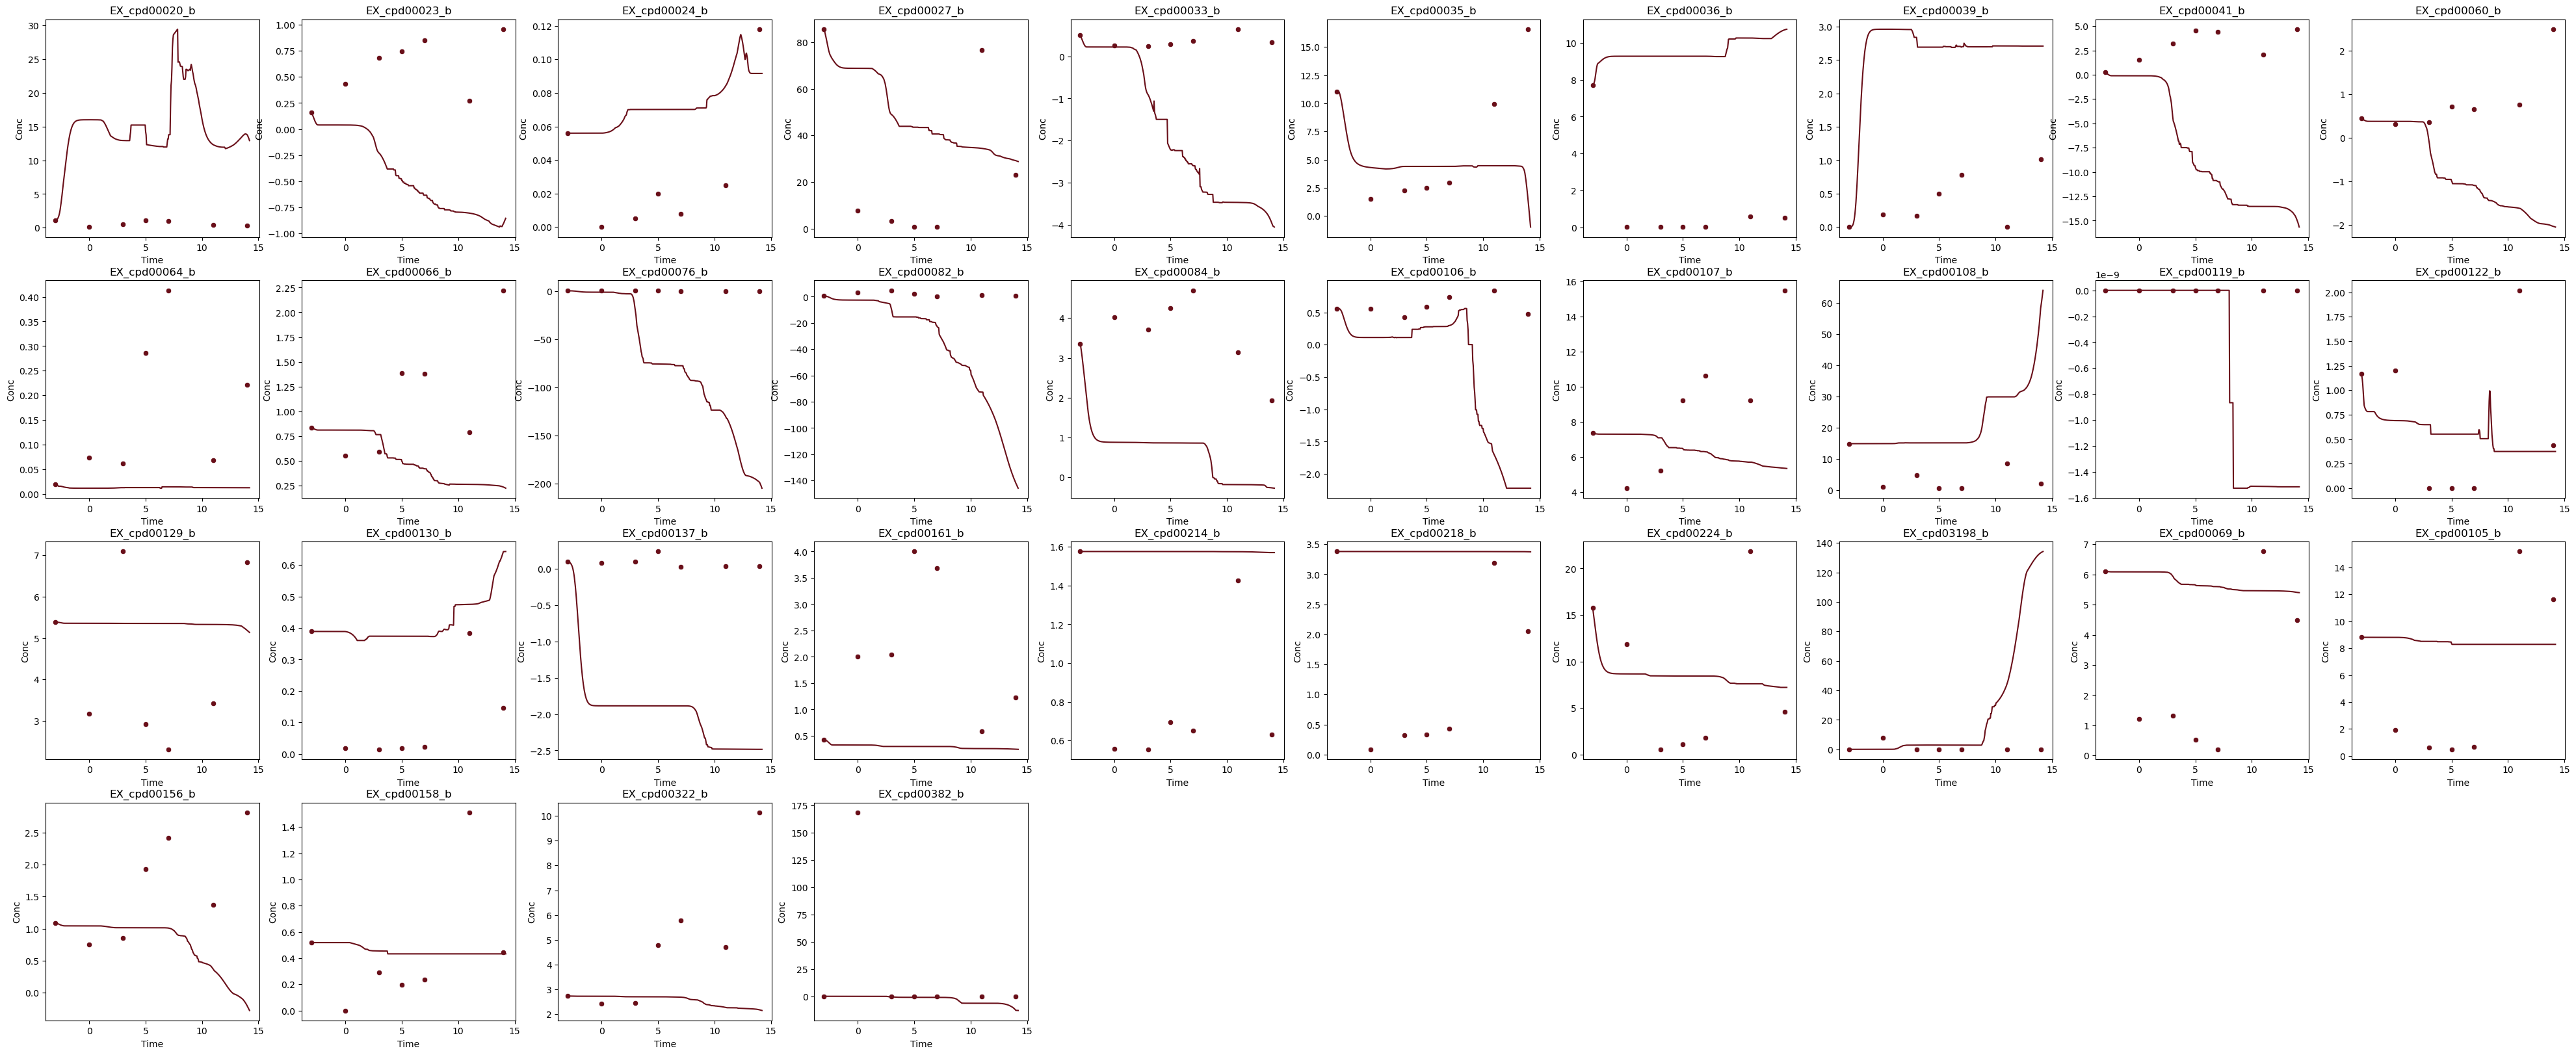

In [ ]:
num_plots = merged_bac_met_use_df.shape[0]
cols = 10  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i,met in enumerate(merged_bac_met_use_df.index.tolist()):
    temp_sim = merged_bac_met_use_df.loc[met,:]
    temp_exp = metabolomics_data_sub_1948.loc[met,:]
        # Scatter plot on the respective subplot
    sns.lineplot(ax=axes[i], 
                    x=temp_sim.index.to_list(), y=temp_sim.to_list())
    sns.scatterplot(ax=axes[i], 
                    x=temp_exp.index.to_list(), y=temp_exp.to_list())

    axes[i].set_title(f"{met}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Conc')
    #axes[i].set_yscale('log')
    #axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])


plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_individual_scatterplots_' + str(test_num) + '.pdf'
#plt.savefig(plot_file_name, bbox_inches="tight")